In [1]:
import os
import h5py
import glob
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
from scipy.integrate import quad
from astropy import constants as const
from scipy.interpolate import interp1d
from scipy.integrate import quad
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 200
mpl.rcParams['savefig.dpi'] = 300
mpl.rcParams['agg.path.chunksize'] = 10000

# Set universal font properties
plt.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "font.size": 14,
})


## All Plot (Final product)

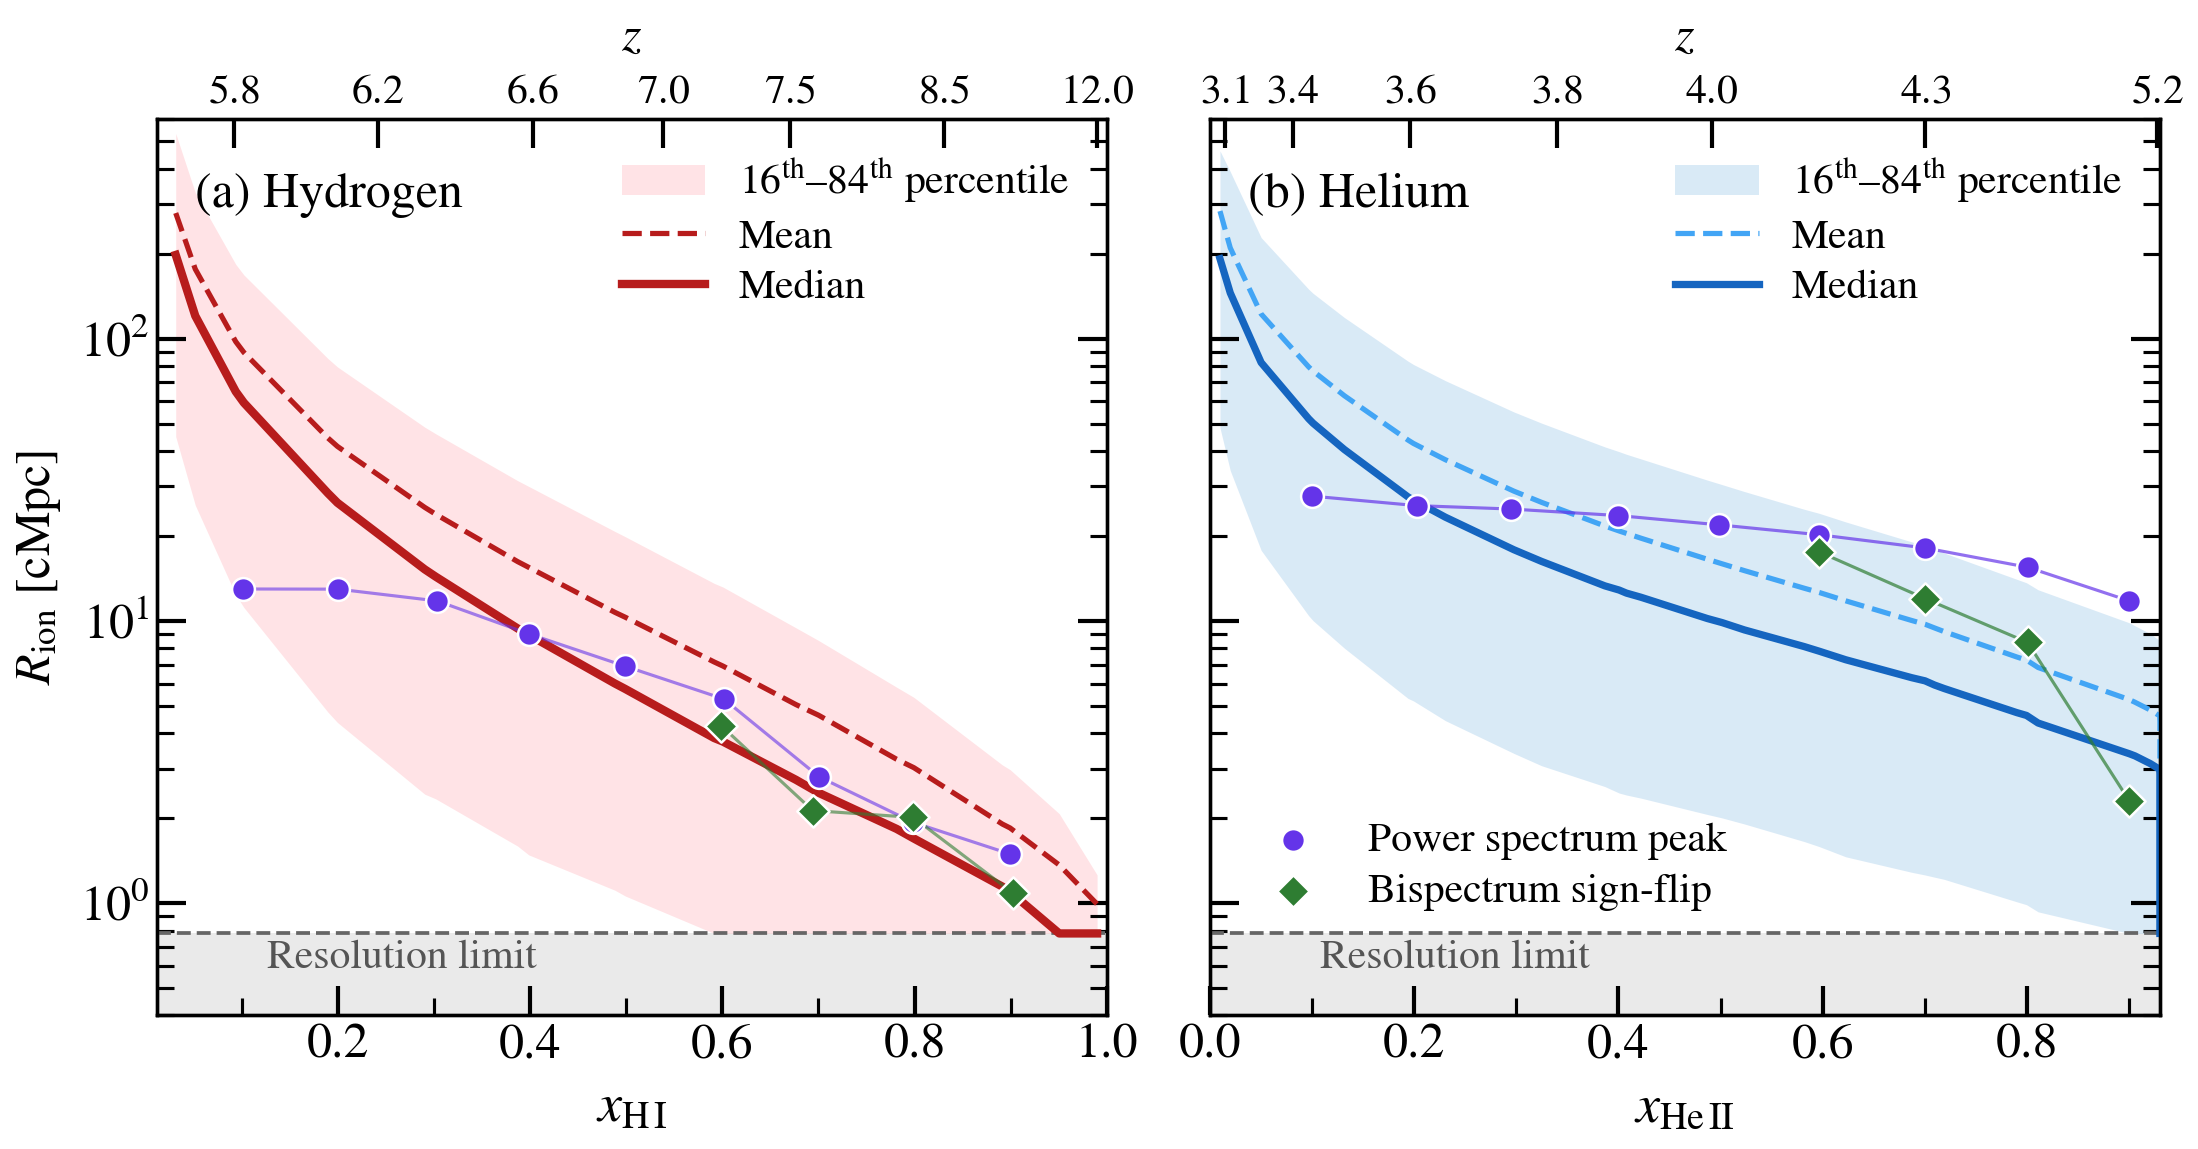

In [2]:
import os
import glob
import h5py
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import LogLocator, NullFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# =====================================================
# Global rcParams
# =====================================================
matplotlib.rcParams.update({
    "font.family":         "STIXGeneral",
    "mathtext.fontset":   "stix",
    "font.size":          18,
    "axes.linewidth":     1.6,
    "axes.labelsize":     24,
    "axes.titlesize":     22,
    "xtick.major.size":   20,
    "xtick.minor.size":   8,
    "xtick.major.width":  2.0,
    "xtick.minor.width":  1.5,
    "xtick.labelsize":    24,
    "xtick.direction":    "in",
    "xtick.top":          True,
    "ytick.major.size":   14,
    "ytick.minor.size":   8,
    "ytick.major.width":  2.0,
    "ytick.minor.width":  1.5,
    "ytick.labelsize":    24,
    "ytick.direction":    "in",
    "ytick.right":        True,
    "legend.fontsize":    14,
    "legend.frameon":     False,
    "legend.handlelength":2.0,
    "lines.linewidth":    2.5,
    "figure.dpi":         150,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
})

N_RESOLVED_BINS = 1000000
R_GLOBAL_MIN    = 0.1
R_GLOBAL_MAX    = 1000.0

def rebin_by_overlap(edges_src, counts_src, edges_dst):
    out = np.zeros(len(edges_dst) - 1)
    for j in range(len(counts_src)):
        count = counts_src[j]
        if count == 0: continue
        lo, hi = edges_src[j], edges_src[j + 1]
        width  = hi - lo
        if width <= 0: continue
        i_lo = max(np.searchsorted(edges_dst, lo, side="right") - 1, 0)
        i_hi = min(np.searchsorted(edges_dst, hi, side="left"), len(out) - 1)
        for k in range(i_lo, i_hi + 1):
            overlap = min(hi, edges_dst[k + 1]) - max(lo, edges_dst[k])
            if overlap > 0:
                out[k] += count * overlap / width
    return out

# =====================================================
# 1. HYDROGEN DATA PROCESSING
# =====================================================
DATA_DIR_H = "/orcd/data/mvogelsb/004/chcho/mfp-bubbles-thesan/output/LUMINA_hydrogen"
files_h = sorted(glob.glob(os.path.join(DATA_DIR_H, "mfp_*.hdf5")))
if len(files_h) == 0:
    raise RuntimeError(f"No H files found in {DATA_DIR_H}")

with h5py.File(files_h[0], "r") as f:
    boxsize     = float(f["Header"].attrs["BoxSize"])
    hubble      = float(f["Header"].attrs["HubbleParam"])
    box_cMpc    = boxsize / hubble / 1000.0
    Ngrid       = int(f["Header"].attrs["NumPixels"])
    cell_size_h = box_cMpc / Ngrid

R_min_h          = cell_size_h
resolved_edges_h = np.logspace(np.log10(R_min_h), np.log10(R_GLOBAL_MAX), N_RESOLVED_BINS + 1)
bin_edges_h      = np.concatenate([[R_GLOBAL_MIN], resolved_edges_h])
R_centers_h      = np.sqrt(bin_edges_h[:-1] * bin_edges_h[1:])
R_centers_h[0]  = R_min_h
dlogR_h          = np.diff(np.log10(bin_edges_h))

snap_to_fHII = {
    112: 0.01, 129: 0.02, 140: 0.03, 148: 0.04, 154: 0.05, 160: 0.06, 165: 0.07, 169: 0.08, 173: 0.09, 177: 0.10,
    203: 0.20, 220: 0.30, 242: 0.40, 264: 0.50, 283: 0.60, 300: 0.70, 318: 0.80, 338: 0.90, 341: 0.91, 343: 0.92,
    346: 0.93, 349: 0.94, 352: 0.95, 356: 0.96, 360: 0.97, 366: 0.98, 374: 0.99,
}
snap_to_redshift_h = {
    112: 12.006999, 129: 11.205740, 140: 10.718889, 148: 10.363529, 154: 10.081991, 160:  9.847533, 165:  9.645984,
    169:  9.469432, 173:  9.311993, 177:  9.170129, 203:  8.207879, 220:  7.624910, 242:  7.204283, 264:  6.872631,
    283:  6.592783, 300:  6.342011, 318:  6.099902, 338:  5.826679, 341:  5.794754, 343:  5.761251, 346:  5.725699,
    349:  5.687586, 352:  5.645994, 356:  5.599397, 360:  5.545151, 366:  5.477609, 374:  5.379672,
}

_snaps_h   = np.array(sorted(snap_to_redshift_h.keys()))
_z_table_h = np.array([snap_to_redshift_h[s] for s in _snaps_h])
_f_table_h = np.array([snap_to_fHII[s]       for s in _snaps_h])
_sort_h    = np.argsort(_z_table_h)
_z_table_h, _f_table_h = _z_table_h[_sort_h], _f_table_h[_sort_h]

def z_to_xHII(z):  return np.interp(z, _z_table_h, _f_table_h)

z_all_h, mean_all_h, median_all_h, logmean_all_h, p16_all_h, p84_all_h = [], [], [], [], [], []
for fp in files_h:
    with h5py.File(fp, "r") as f:
        z               = float(f["Header"].attrs["Redshift"])
        hist            = f["mfp_hist"][:].astype(float)
        n_bins_native   = len(hist)
        n_bins_per_cell = int(f["Header"].attrs["NumBinsPerCell"])
    edges_native = np.arange(n_bins_native + 1) / n_bins_per_cell * cell_size_h
    hist_rebin   = rebin_by_overlap(edges_native, hist, bin_edges_h)
    total = hist_rebin.sum()
    if total == 0: continue
    P         = hist_rebin / total
    mask_stat = P > 0
    R_stat    = R_centers_h[mask_stat]
    P_stat    = P[mask_stat]
    cdf       = np.cumsum(P_stat)
    z_all_h.append(z)
    mean_all_h.append(np.sum(P_stat * R_stat))
    logmean_all_h.append(10 ** np.sum(P_stat * np.log10(R_stat)))
    median_all_h.append(np.interp(0.50, cdf, R_stat))
    p16_all_h.append(np.interp(0.16, cdf, R_stat))
    p84_all_h.append(np.interp(0.84, cdf, R_stat))

sort_idx_h = np.argsort(z_all_h)
z_all_h, mean_all_h, median_all_h, logmean_all_h, p16_all_h, p84_all_h = [
    np.array(x)[sort_idx_h] for x in [z_all_h, mean_all_h, median_all_h, logmean_all_h, p16_all_h, p84_all_h]
]
xHI_all = 1.0 - z_to_xHII(z_all_h)

# Hydrogen literature
z_ps_h     = np.array([9.16, 8.20, 7.63, 7.21, 6.87, 6.59, 6.35, 6.10, 5.83])
R_ps_h     = np.array([1.012, 1.308, 1.895, 3.581, 4.674, 6.085, 7.967, 8.770, 8.782]) / hubble
#np.array([2.544, 3.288, 4.763, 8.999, 11.747, 15.292, 20.024, 22.041, 22.073]) / hubble
xHI_ps     = 1.0 - z_to_xHII(z_ps_h)


z_bispec_h = np.array([9.2, 8.2, 7.6, 7.2])
R_bispec_h = np.array([1.08827, 2.01348, 2.12863, 4.25726])# / hubble (already divided)
xHI_bispec = 1.0 - z_to_xHII(z_bispec_h)

z_hsiao, R_hsiao = np.array([9.16]), np.array([2.234])
xHI_hsiao = 1.0 - z_to_xHII(z_hsiao)

xHI_umeda       = np.array([0.53, 0.65, 0.91, 0.92])
xHI_err_low     = np.array([0.47, 0.34, 0.22, 0.10])
xHI_err_high    = np.array([0.18, 0.27, 0.09, 0.08])
logRb           = np.array([1.67, 1.53, 0.70, -0.69])
logRb_err_low   = np.array([0.16, 1.48, 1.04, 0.24])
logRb_err_high  = np.array([0.14, 0.34, 0.47, 0.89])
Rb_umeda        = 10**logRb
Rb_low          = Rb_umeda - 10**(logRb - logRb_err_low)
Rb_high         = 10**(logRb + logRb_err_high) - Rb_umeda

xi_furlanetto = np.array([0.1992, 0.2109, 0.2226, 0.2385, 0.2503, 0.2687, 0.2804, 0.2921, 0.3089, 0.3206, 0.3324, 0.3499, 0.3617, 0.3726, 0.3910, 0.4027, 0.4145, 0.4329, 0.4438, 0.4555, 0.4739, 0.4857, 0.4974, 0.5150, 0.5267, 0.5384, 0.5569, 0.5686, 0.5795, 0.5987, 0.6105, 0.6222, 0.6398, 0.6515, 0.6632, 0.6817, 0.6934, 0.7043, 0.7227, 0.7345, 0.7462, 0.7646, 0.7755, 0.7872, 0.8057, 0.8174, 0.8291, 0.8459, 0.8576, 0.8693, 0.8877, 0.8995, 0.9104, 0.9221, 0.9338, 0.9455, 0.9573, 0.9682, 0.9799, 0.9900])
R_furlanetto  = np.array([0.3400, 0.3830, 0.4330, 0.5102, 0.5715, 0.6636, 0.7469, 0.8229, 0.9382, 1.0277, 1.1279, 1.2792, 1.3868, 1.4958, 1.6944, 1.8320, 1.9750, 2.2242, 2.3746, 2.5527, 2.8536, 3.0616, 3.2919, 3.6405, 3.9111, 4.1886, 4.6573, 4.9884, 5.3024, 5.9213, 6.3318, 6.7762, 7.4903, 8.0340, 8.5978, 9.5410, 10.2468, 10.9140, 12.1634, 13.1065, 14.0946, 15.8179, 16.9384, 18.2749, 20.7074, 22.5165, 24.4675, 27.7386, 30.4569, 33.5082, 39.5524, 44.0926, 49.8666, 56.4022, 65.7361, 71.1672, 96.6880, 117.2752, 167.3574, 290.0000])
xHI_furlanetto = 1.0 - xi_furlanetto

xHI_neyer = np.array([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
R_neyer   = np.array([125.0, 40.0, 18.0, 10.0, 6.0, 3.5, 2.2, 1.4, 1.0, 0.6, 0.25])

# =====================================================
# 2. HELIUM DATA PROCESSING
# =====================================================
DATA_DIR_HE = "/orcd/data/mvogelsb/004/chcho/mfp-bubbles-thesan/output/LUMINA_helium"
files_he = sorted(glob.glob(os.path.join(DATA_DIR_HE, "mfp_*.hdf5")))
if len(files_he) == 0:
    raise RuntimeError(f"No He files found in {DATA_DIR_HE}")

with h5py.File(files_he[0], "r") as f:
    cell_size_he = (float(f["Header"].attrs["BoxSize"]) / hubble / 1000.0) / int(f["Header"].attrs["NumPixels"])

R_min_he          = cell_size_he
resolved_edges_he = np.logspace(np.log10(R_min_he), np.log10(R_GLOBAL_MAX), N_RESOLVED_BINS + 1)
bin_edges_he      = np.concatenate([[R_GLOBAL_MIN], resolved_edges_he])
R_centers_he      = np.sqrt(bin_edges_he[:-1] * bin_edges_he[1:])
R_centers_he[0]  = R_min_he
dlogR_he          = np.diff(np.log10(bin_edges_he))

snap_to_fHeIII = {
    695: 0.01, 660: 0.02, 644: 0.03, 633: 0.04, 624: 0.05, 618: 0.06, 612: 0.07, 606: 0.08, 601: 0.09, 596: 0.10,
    558: 0.20, 529: 0.30, 514: 0.40, 500: 0.50, 487: 0.60, 471: 0.70, 450: 0.80, 406: 0.90, 401: 0.91, 394: 0.92, 387: 0.93
}
snap_to_redshift_he = {
    695: 3.035828, 660: 3.172945, 644: 3.238152, 633: 3.283318, 624: 3.318701, 618: 3.347722, 612: 3.373351,
    606: 3.396815, 601: 3.418623, 596: 3.439090, 558: 3.606240, 529: 3.746897, 514: 3.880495, 500: 4.011606,
    487: 4.144300, 471: 4.299100, 450: 4.517370, 406: 4.999257, 401: 5.062160, 394: 5.134098, 387: 5.223496
}

_snaps_he   = np.array(sorted(snap_to_redshift_he.keys()))
_z_table_he = np.array([snap_to_redshift_he[s] for s in _snaps_he])
_f_table_he = np.array([snap_to_fHeIII[s]      for s in _snaps_he])
_sort_he    = np.argsort(_z_table_he)
_z_table_he, _f_table_he = _z_table_he[_sort_he], _f_table_he[_sort_he]

def z_to_xHeIII(z): return np.interp(z, _z_table_he, _f_table_he)

z_all_he, mean_all_he, median_all_he, logmean_all_he, p16_all_he, p84_all_he = [], [], [], [], [], []
for fp in files_he:
    with h5py.File(fp, "r") as f:
        z               = float(f["Header"].attrs["Redshift"])
        hist            = f["mfp_hist"][:].astype(float)
        n_bins_per_cell = int(f["Header"].attrs["NumBinsPerCell"])
    hist_rebin = rebin_by_overlap(
        np.arange(len(hist) + 1) / n_bins_per_cell * cell_size_he, hist, bin_edges_he
    )
    total = hist_rebin.sum()
    if total == 0: continue
    P         = hist_rebin / total
    mask_stat = P > 0
    R_stat    = R_centers_he[mask_stat]
    P_stat    = P[mask_stat]
    cdf       = np.cumsum(P_stat)
    z_all_he.append(z)
    mean_all_he.append(np.sum(P_stat * R_stat))
    logmean_all_he.append(10 ** np.sum(P_stat * np.log10(R_stat)))
    median_all_he.append(np.interp(0.50, cdf, R_stat))
    p16_all_he.append(np.interp(0.16, cdf, R_stat))
    p84_all_he.append(np.interp(0.84, cdf, R_stat))

sort_idx_he = np.argsort(z_all_he)
z_all_he, mean_all_he, median_all_he, logmean_all_he, p16_all_he, p84_all_he = [
    np.array(x)[sort_idx_he] for x in [z_all_he, mean_all_he, median_all_he, logmean_all_he, p16_all_he, p84_all_he]
]
xHe_all = z_to_xHeIII(z_all_he)

# Helium literature
z_ps_he     = np.array([5.00, 4.52, 4.30, 4.14, 4.01, 3.88, 3.74, 3.61, 3.44])
R_ps_he     = np.array([7.967, 10.485, 12.271, 13.666, 14.816, 15.988, 16.860, 17.334, 18.726]) / hubble
#np.array([20.023, 26.353, 30.841, 34.348, 37.238, 40.181, 42.373, 43.565, 47.064]) / hubble
xHe_ps      = z_to_xHeIII(z_ps_he)

z_bispec_he = np.array([5.00, 4.52, 4.30, 4.14])
R_bispec_he = np.array([2.30112, 8.39200, 11.9886, 17.5531])# / hubble
xHe_bispec  = z_to_xHeIII(z_bispec_he)

# =====================================================
# 3. FIGURE — shared y-axis
# =====================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8.0), sharey=True)
plt.subplots_adjust(wspace=0.05)

# Palette
C_FILL_H   = "#FFCDD2"
C_MEDIAN_H = "#B71C1C"
C_MEAN_H   = "#B71C1C"
C_LMEAN_H  = "#B71C1C"
C_PS_H     = "#6434e9"
C_BIS_H    = "#2E7D32"
C_HSIAO    = "#ffb703"
C_UMEDA    = "#00838F"
C_FURL     = "#fb6640"

C_FILL_HE   = "#BBD9F0"
C_MEDIAN_HE = "#1565C0"
C_MEAN_HE   = "#42A5F5"
C_LMEAN_HE  = "#90CAF9"
C_PS_HE     = "#6434e9"
C_BIS_HE    = "#2E7D32"

# -----------------------------------------------------
# Panel (a): Hydrogen
# -----------------------------------------------------
ax1.fill_between(xHI_all, p16_all_h, p84_all_h,
                 color=C_FILL_H, alpha=0.55, lw=0,
                 label=r"$16^{\rm th}$–$84^{\rm th}$ percentile")
ax1.plot(xHI_all, mean_all_h,    color=C_MEAN_H,   lw=2.5, ls="--", zorder=3, label=r"Mean")
#ax1.plot(xHI_all, logmean_all_h, color=C_LMEAN_H,  lw=2.5, ls=":",  zorder=3, label=r"Log-mean")
ax1.plot(xHI_all, median_all_h,  color=C_MEDIAN_H, lw=4.0, ls="-",  zorder=4, label=r"Median")

ax1.plot(xHI_ps, R_ps_h, color=C_PS_H, lw=1.5, ls="-", alpha=0.6, zorder=5)
ax1.scatter(xHI_ps, R_ps_h, s=120, color=C_PS_H, marker="o", zorder=6,
            edgecolors="white", linewidths=1.2)

ax1.plot(xHI_bispec, R_bispec_h, color=C_BIS_H, lw=1.5, ls="-", alpha=0.6, zorder=5)
ax1.scatter(xHI_bispec, R_bispec_h, s=120, color=C_BIS_H, marker="D", zorder=6,
            edgecolors="white", linewidths=1.2)

#ax1.scatter(xHI_hsiao, R_hsiao, s=120, color="none", marker="s", zorder=7,
#            edgecolors=C_HSIAO, linewidths=3.0, label=r"Hsiao et al. 2023")
#ax1.plot(xHI_furlanetto, R_furlanetto, color=C_FURL, lw=3.5, ls="-", zorder=6,
#         label="Furlanetto & Oh 2005")

xHI_z12_target = 1.0 - z_to_xHII(12.0)
#ax1.annotate("", xy=(xHI_z12_target, R_hsiao[0]), xytext=(xHI_hsiao[0], R_hsiao[0]),
#             arrowprops=dict(arrowstyle="->", color=C_HSIAO, lw=2.0, shrinkA=0, shrinkB=0), zorder=7)
#ax1.annotate("", xy=(xHI_hsiao[0], 0.7), xytext=(xHI_hsiao[0], R_hsiao[0]),
#             arrowprops=dict(arrowstyle="->", color=C_HSIAO, lw=2.0, shrinkA=0, shrinkB=0), zorder=7)

#ax1.errorbar(
#    xHI_umeda, Rb_umeda,
#    xerr=[xHI_err_low, xHI_err_high], yerr=[Rb_low, Rb_high],
#    fmt="s", ms=11, mfc="none", mec=C_UMEDA, mew=2.0,
#    ecolor=C_UMEDA, elinewidth=2.0, capsize=4,
#    linestyle="none", zorder=7, label=r"Umeda et al. 2024"
#)

ax1.set_xlabel(r"$x_{\rm H\,I}$", fontsize=26, labelpad=8)
ax1.set_ylabel(r"$R_{\rm ion}\ [\mathrm{cMpc}]$", fontsize=24, labelpad=8)
ax1.set_yscale("log")
ax1.set_ylim(0.4, 600.0)

xHI_lo = max(xHI_all.min() - 0.02, 0.0)
xHI_hi = min(xHI_all.max() + 0.02, 1.0)
ax1.set_xlim(xHI_lo, xHI_hi)
ax1.text(0.04, 0.94, "(a) Hydrogen", transform=ax1.transAxes, fontsize=24, va="top")

# Resolution shading — panel (a) only
R_res_h = 500.0 / 640.0
ax1.axhspan(1e-2, R_res_h, color="#bbbbbb", alpha=0.30, zorder=0, lw=0)
ax1.axhline(R_res_h, color="#666666", ls="--", lw=1.8, zorder=3)
ax1.text(
    xHI_lo + 0.4 * (xHI_hi - xHI_lo), R_res_h * 0.7,
    "Resolution limit", color="#555555", fontsize=20,
    va="bottom", ha="right", zorder=4
)

# Legend — panel (a)
handles_h, labels_h = ax1.get_legend_handles_labels()
upper_right_labels_h = ["Furlanetto & Oh 2005", "Hsiao et al. 2023", "Umeda et al. 2024"]
h1, l1, h2, l2 = [], [], [], []
for h, l in zip(handles_h, labels_h):
    if l in upper_right_labels_h: h2.append(h); l2.append(l)
    else:                          h1.append(h); l1.append(l)
sorted_h2, sorted_l2 = [], []
for target in upper_right_labels_h:
    if target in l2:
        idx = l2.index(target)
        sorted_h2.append(h2[idx]); sorted_l2.append(l2[idx])
leg1_h = ax1.legend(h1, l1, loc="upper right", fontsize=20,
                    borderpad=0.4, labelspacing=0.3, frameon=False)
ax1.add_artist(leg1_h)
ax1.legend(sorted_h2, sorted_l2, loc="upper right", fontsize=20,
           borderpad=0.4, labelspacing=0.3, frameon=False)

# Top redshift axis — panel (a)
ax_top1 = ax1.twiny()
z_ticks_1    = np.array([5.8, 6.2, 6.6, 7.0, 7.5, 8.5, 12.0])
z_ticks_1    = z_ticks_1[(z_ticks_1 >= _z_table_h.min()) & (z_ticks_1 <= _z_table_h.max())]
xHI_tick_pos = 1.0 - z_to_xHII(z_ticks_1)
in_range1    = (xHI_tick_pos >= xHI_lo) & (xHI_tick_pos <= xHI_hi)
ax_top1.set_xlim(ax1.get_xlim())
ax_top1.set_xticks(xHI_tick_pos[in_range1])
ax_top1.set_xticklabels([f"${z:.1f}$" for z in z_ticks_1[in_range1]], fontsize=18)
ax_top1.set_xlabel(r"$z$", fontsize=24, labelpad=12)
ax_top1.tick_params(which="major", direction="in", length=10, width=1.6)

# -----------------------------------------------------
# Panel (b): Helium
# -----------------------------------------------------
ax2.fill_between(xHe_all, p16_all_he, p84_all_he,
                 color=C_FILL_HE, alpha=0.55, lw=0,
                 label=r"$16^{\mathrm{th}}$–$84^{\mathrm{th}}$ percentile")
ax2.plot(xHe_all, mean_all_he,    color=C_MEAN_HE,   lw=2.5, ls="--", zorder=3, label=r"Mean")
#ax2.plot(xHe_all, logmean_all_he, color=C_LMEAN_HE,  lw=2.5, ls=":",  zorder=3, label=r"Log-mean")
ax2.plot(xHe_all, median_all_he,  color=C_MEDIAN_HE, lw=3.5, ls="-",  zorder=4, label=r"Median")

ax2.plot(xHe_ps, R_ps_he, color=C_PS_HE, lw=1.5, ls="-", alpha=0.7, zorder=5)
ax2.scatter(xHe_ps, R_ps_he, s=120, color=C_PS_HE, marker="o", zorder=6,
            edgecolors="white", linewidths=1.2, label=r"Power spectrum peak")

ax2.plot(xHe_bispec, R_bispec_he, color=C_BIS_HE, lw=1.5, ls="-", alpha=0.7, zorder=5)
ax2.scatter(xHe_bispec, R_bispec_he, s=120, color=C_BIS_HE, marker="D", zorder=6,
            edgecolors="white", linewidths=1.2, label=r"Bispectrum sign-flip")

ax2.set_xlabel(r"$x_{\mathrm{He\,II}}$", fontsize=26, labelpad=8)
xHe_lo = max(xHe_all.min() - 0.02, 0.0)
xHe_hi = 0.93
ax2.set_xlim(xHe_lo, xHe_hi)
ax2.text(0.04, 0.94, "(b) Helium", transform=ax2.transAxes, fontsize=24, va="top")
ax2.tick_params(labelleft=False)
R_res_he = 500.0 / 640.0
ax2.axhspan(1e-2, R_res_he, color="#bbbbbb", alpha=0.30, zorder=0, lw=0)
ax2.axhline(R_res_he, color="#666666", ls="--", lw=1.8, zorder=3)
ax2.text(
    xHe_lo + 0.4 * (xHe_hi - xHe_lo), R_res_he * 0.7,
    "Resolution limit", color="#555555", fontsize=20,
    va="bottom", ha="right", zorder=4
)

# Legend — panel (b)
handles_he, labels_he = ax2.get_legend_handles_labels()
stat_labels = [r"$16^{\mathrm{th}}$–$84^{\mathrm{th}}$ percentile", r"Mean", r"Median"]
lit_labels  = [r"Power spectrum peak", r"Bispectrum sign-flip"]
h_stat = [h for h, l in zip(handles_he, labels_he) if l in stat_labels]
l_stat = [l for l in labels_he if l in stat_labels]
h_lit  = [h for h, l in zip(handles_he, labels_he) if l in lit_labels]
l_lit  = [l for l in labels_he if l in lit_labels]
leg_stat = ax2.legend(h_stat, l_stat, loc="upper right", fontsize=20,
                      borderpad=0.4, labelspacing=0.3, frameon=False)
ax2.add_artist(leg_stat)
ax2.legend(h_lit, l_lit, loc="lower left", bbox_to_anchor=(0.0, 0.07),
           fontsize=20, borderpad=0.5, labelspacing=0.3, frameon=False)

# Top redshift axis — panel (b)
ax_top2 = ax2.twiny()
z_ticks_2    = np.array([3.1, 3.4, 3.6, 3.8, 4.0, 4.3, 5.2])
z_ticks_2    = z_ticks_2[(z_ticks_2 >= _z_table_he.min()) & (z_ticks_2 <= _z_table_he.max())]
xHe_tick_pos = z_to_xHeIII(z_ticks_2)
in_range2    = (xHe_tick_pos >= xHe_lo) & (xHe_tick_pos <= xHe_hi)
ax_top2.set_xlim(ax2.get_xlim())
ax_top2.set_xticks(xHe_tick_pos[in_range2])
ax_top2.set_xticklabels([f"${z:.1f}$" for z in z_ticks_2[in_range2]], fontsize=18)
ax_top2.set_xlabel(r"$z$", fontsize=24, labelpad=12)
ax_top2.tick_params(which="major", direction="in", length=10, width=1.6)

# =====================================================
# Shared tick formatting
# =====================================================
for ax in [ax1, ax2]:
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax.yaxis.set_major_locator(LogLocator(base=10, numticks=6))
    ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1, numticks=20))
    ax.yaxis.set_minor_formatter(NullFormatter())
    ax.tick_params(which="major", direction="in", length=14, width=2.0, labelsize=24)
    ax.tick_params(which="minor", direction="in", length=8,  width=1.5)

for ax_top in [ax_top1, ax_top2]:
    ax_top.xaxis.set_minor_locator(ticker.NullLocator())
    ax_top.tick_params(which="major", direction="in", length=14, width=2.0, labelsize=20)

plt.tight_layout()
#plt.savefig("BSD.png")
plt.show()

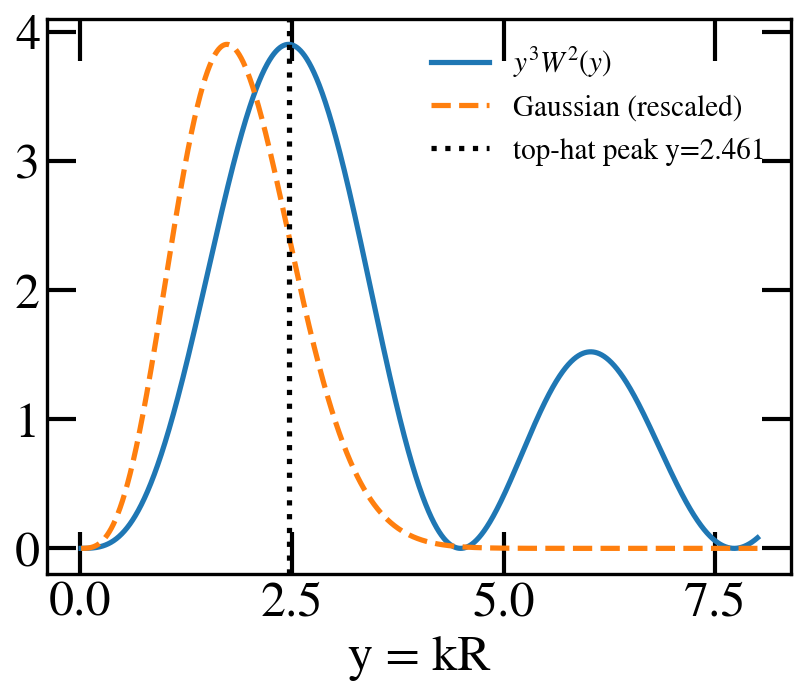

In [3]:
import numpy as np, matplotlib.pyplot as plt
from scipy.optimize import brentq
y = np.linspace(0.01, 8, 2000)
W = 3*(np.sin(y) - y*np.cos(y))/y**3
g = y**3 * W**2
ystar = brentq(lambda t: np.tan(t) - 3*t/(3 - 2*t**2), 2.0, 3.0)
plt.plot(y, g, label=r'$y^3W^2(y)$')
plt.plot(y, y**3*np.exp(-y**2/2)*g.max()/(np.sqrt(3)**3*np.exp(-1.5)), '--', label='Gaussian (rescaled)')
plt.axvline(ystar, color='k', ls=':', label=f'top-hat peak y={ystar:.3f}')
plt.xlabel('y = kR'); plt.legend(); plt.show()

## (Previous) With observations

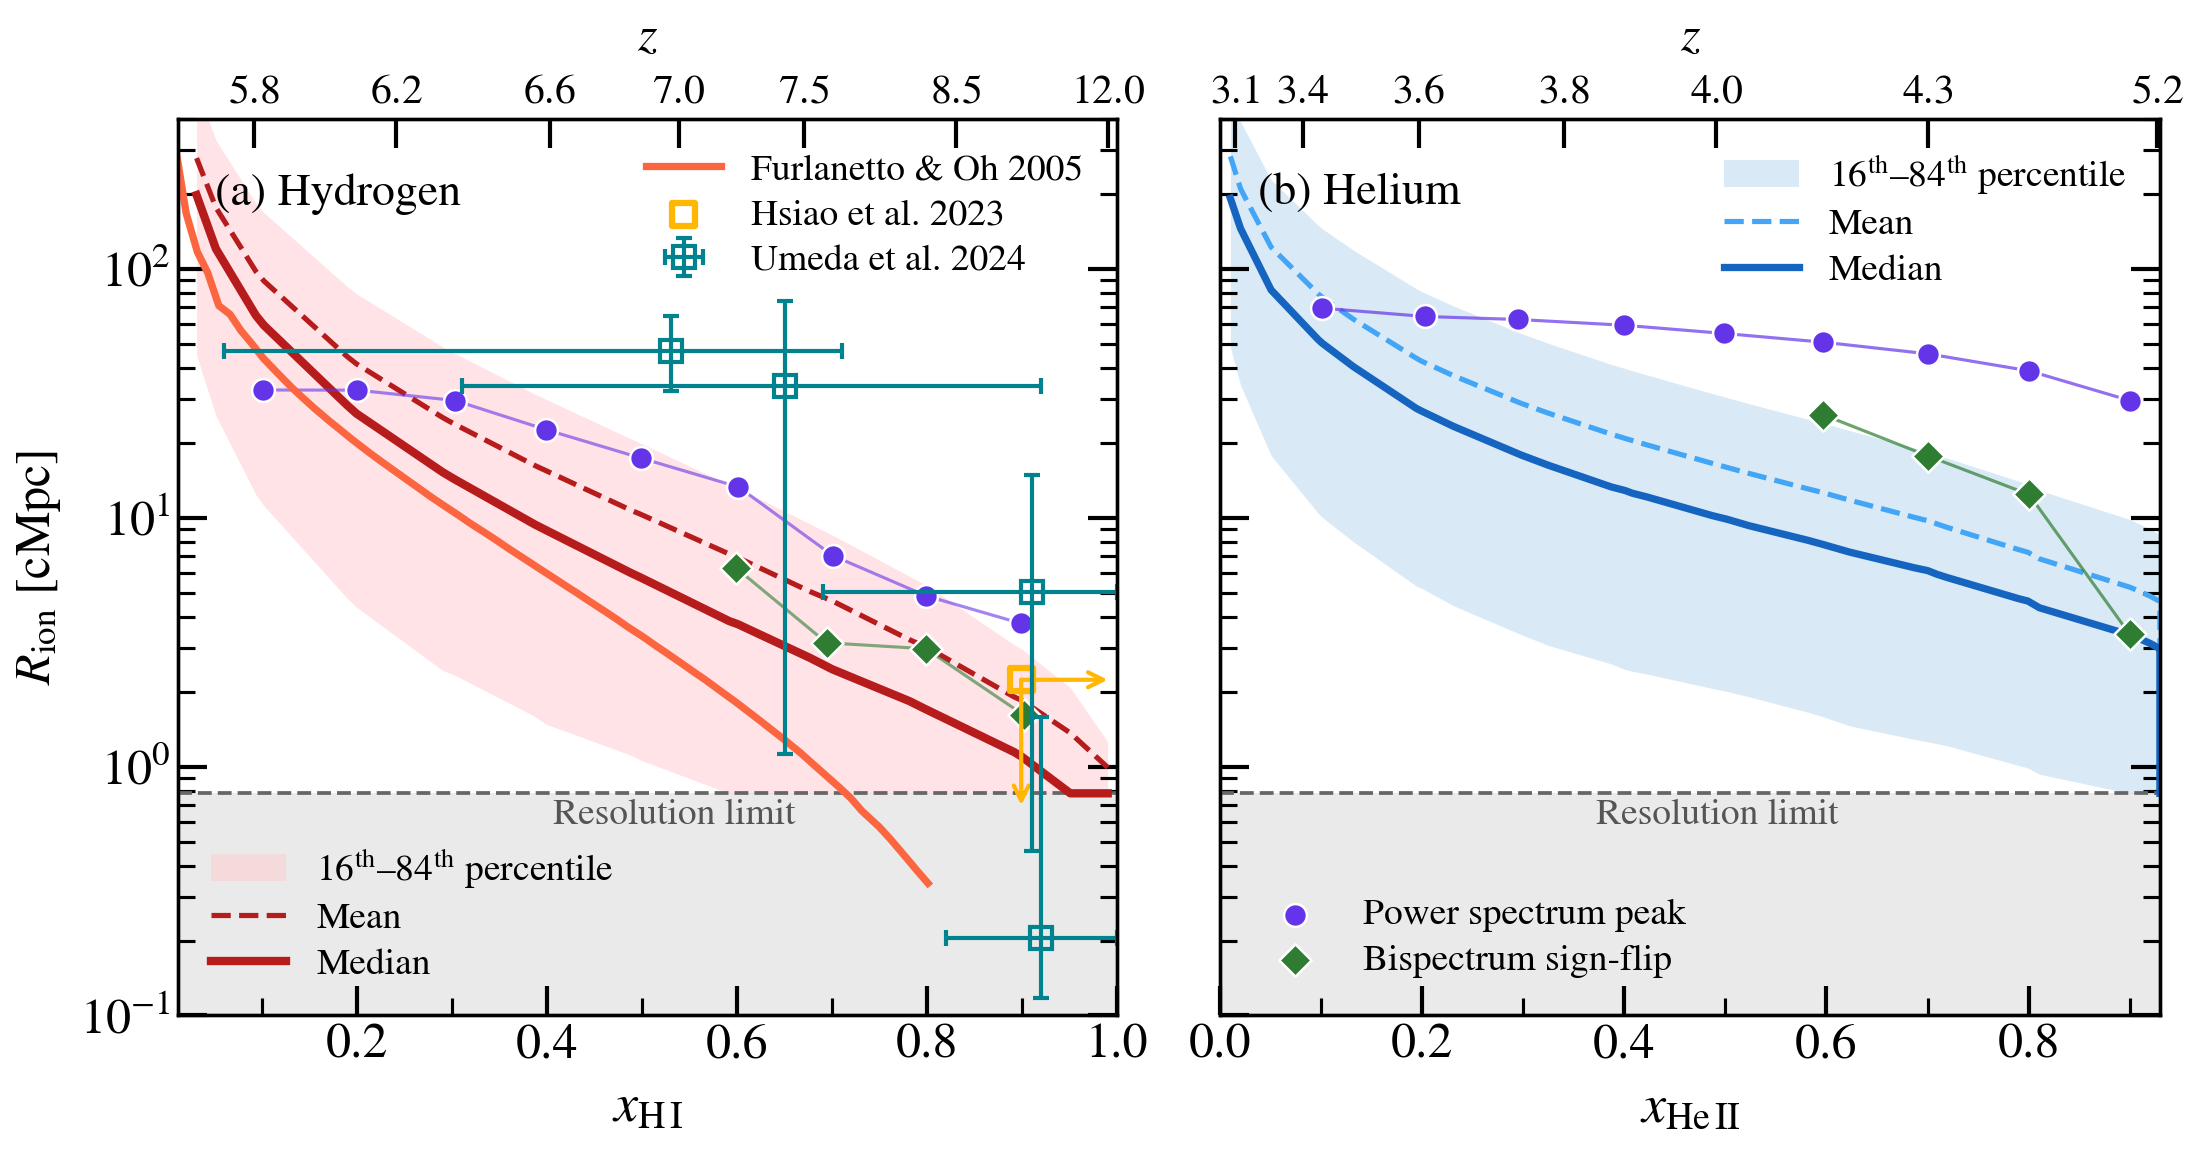

In [2]:
import os
import glob
import h5py
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import LogLocator, NullFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# =====================================================
# Global rcParams
# =====================================================
matplotlib.rcParams.update({
    "font.family":         "STIXGeneral",
    "mathtext.fontset":   "stix",
    "font.size":          18,
    "axes.linewidth":     1.6,
    "axes.labelsize":     24,
    "axes.titlesize":     22,
    "xtick.major.size":   20,
    "xtick.minor.size":   8,
    "xtick.major.width":  2.0,
    "xtick.minor.width":  1.5,
    "xtick.labelsize":    24,
    "xtick.direction":    "in",
    "xtick.top":          True,
    "ytick.major.size":   14,
    "ytick.minor.size":   8,
    "ytick.major.width":  2.0,
    "ytick.minor.width":  1.5,
    "ytick.labelsize":    24,
    "ytick.direction":    "in",
    "ytick.right":        True,
    "legend.fontsize":    14,
    "legend.frameon":     False,
    "legend.handlelength":2.0,
    "lines.linewidth":    2.5,
    "figure.dpi":         150,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
})

N_RESOLVED_BINS = 1000000
R_GLOBAL_MIN    = 0.1
R_GLOBAL_MAX    = 1000.0

def rebin_by_overlap(edges_src, counts_src, edges_dst):
    out = np.zeros(len(edges_dst) - 1)
    for j in range(len(counts_src)):
        count = counts_src[j]
        if count == 0: continue
        lo, hi = edges_src[j], edges_src[j + 1]
        width  = hi - lo
        if width <= 0: continue
        i_lo = max(np.searchsorted(edges_dst, lo, side="right") - 1, 0)
        i_hi = min(np.searchsorted(edges_dst, hi, side="left"), len(out) - 1)
        for k in range(i_lo, i_hi + 1):
            overlap = min(hi, edges_dst[k + 1]) - max(lo, edges_dst[k])
            if overlap > 0:
                out[k] += count * overlap / width
    return out

# =====================================================
# 1. HYDROGEN DATA PROCESSING
# =====================================================
DATA_DIR_H = "/orcd/data/mvogelsb/004/chcho/mfp-bubbles-thesan/output/LUMINA_hydrogen"
files_h = sorted(glob.glob(os.path.join(DATA_DIR_H, "mfp_*.hdf5")))
if len(files_h) == 0:
    raise RuntimeError(f"No H files found in {DATA_DIR_H}")

with h5py.File(files_h[0], "r") as f:
    boxsize     = float(f["Header"].attrs["BoxSize"])
    hubble      = float(f["Header"].attrs["HubbleParam"])
    box_cMpc    = boxsize / hubble / 1000.0
    Ngrid       = int(f["Header"].attrs["NumPixels"])
    cell_size_h = box_cMpc / Ngrid

R_min_h          = cell_size_h
resolved_edges_h = np.logspace(np.log10(R_min_h), np.log10(R_GLOBAL_MAX), N_RESOLVED_BINS + 1)
bin_edges_h      = np.concatenate([[R_GLOBAL_MIN], resolved_edges_h])
R_centers_h      = np.sqrt(bin_edges_h[:-1] * bin_edges_h[1:])
R_centers_h[0]  = R_min_h
dlogR_h          = np.diff(np.log10(bin_edges_h))

snap_to_fHII = {
    112: 0.01, 129: 0.02, 140: 0.03, 148: 0.04, 154: 0.05, 160: 0.06, 165: 0.07, 169: 0.08, 173: 0.09, 177: 0.10,
    203: 0.20, 220: 0.30, 242: 0.40, 264: 0.50, 283: 0.60, 300: 0.70, 318: 0.80, 338: 0.90, 341: 0.91, 343: 0.92,
    346: 0.93, 349: 0.94, 352: 0.95, 356: 0.96, 360: 0.97, 366: 0.98, 374: 0.99,
}
snap_to_redshift_h = {
    112: 12.006999, 129: 11.205740, 140: 10.718889, 148: 10.363529, 154: 10.081991, 160:  9.847533, 165:  9.645984,
    169:  9.469432, 173:  9.311993, 177:  9.170129, 203:  8.207879, 220:  7.624910, 242:  7.204283, 264:  6.872631,
    283:  6.592783, 300:  6.342011, 318:  6.099902, 338:  5.826679, 341:  5.794754, 343:  5.761251, 346:  5.725699,
    349:  5.687586, 352:  5.645994, 356:  5.599397, 360:  5.545151, 366:  5.477609, 374:  5.379672,
}

_snaps_h   = np.array(sorted(snap_to_redshift_h.keys()))
_z_table_h = np.array([snap_to_redshift_h[s] for s in _snaps_h])
_f_table_h = np.array([snap_to_fHII[s]       for s in _snaps_h])
_sort_h    = np.argsort(_z_table_h)
_z_table_h, _f_table_h = _z_table_h[_sort_h], _f_table_h[_sort_h]

def z_to_xHII(z):  return np.interp(z, _z_table_h, _f_table_h)

z_all_h, mean_all_h, median_all_h, logmean_all_h, p16_all_h, p84_all_h = [], [], [], [], [], []
for fp in files_h:
    with h5py.File(fp, "r") as f:
        z               = float(f["Header"].attrs["Redshift"])
        hist            = f["mfp_hist"][:].astype(float)
        n_bins_native   = len(hist)
        n_bins_per_cell = int(f["Header"].attrs["NumBinsPerCell"])
    edges_native = np.arange(n_bins_native + 1) / n_bins_per_cell * cell_size_h
    hist_rebin   = rebin_by_overlap(edges_native, hist, bin_edges_h)
    total = hist_rebin.sum()
    if total == 0: continue
    P         = hist_rebin / total
    mask_stat = P > 0
    R_stat    = R_centers_h[mask_stat]
    P_stat    = P[mask_stat]
    cdf       = np.cumsum(P_stat)
    z_all_h.append(z)
    mean_all_h.append(np.sum(P_stat * R_stat))
    logmean_all_h.append(10 ** np.sum(P_stat * np.log10(R_stat)))
    median_all_h.append(np.interp(0.50, cdf, R_stat))
    p16_all_h.append(np.interp(0.16, cdf, R_stat))
    p84_all_h.append(np.interp(0.84, cdf, R_stat))

sort_idx_h = np.argsort(z_all_h)
z_all_h, mean_all_h, median_all_h, logmean_all_h, p16_all_h, p84_all_h = [
    np.array(x)[sort_idx_h] for x in [z_all_h, mean_all_h, median_all_h, logmean_all_h, p16_all_h, p84_all_h]
]
xHI_all = 1.0 - z_to_xHII(z_all_h)

# Hydrogen literature
z_ps_h     = np.array([9.16, 8.20, 7.63, 7.21, 6.87, 6.59, 6.35, 6.10, 5.83])
R_ps_h     = np.array([2.544, 3.288, 4.763, 8.999, 11.747, 15.292, 20.024, 22.041, 22.073]) / hubble
xHI_ps     = 1.0 - z_to_xHII(z_ps_h)

z_bispec_h = np.array([9.2, 8.2, 7.6, 7.2])
R_bispec_h = np.array([1.08827, 2.01348, 2.12863, 4.25726]) / hubble
xHI_bispec = 1.0 - z_to_xHII(z_bispec_h)

z_hsiao, R_hsiao = np.array([9.16]), np.array([2.234])
xHI_hsiao = 1.0 - z_to_xHII(z_hsiao)

xHI_umeda       = np.array([0.53, 0.65, 0.91, 0.92])
xHI_err_low     = np.array([0.47, 0.34, 0.22, 0.10])
xHI_err_high    = np.array([0.18, 0.27, 0.09, 0.08])
logRb           = np.array([1.67, 1.53, 0.70, -0.69])
logRb_err_low   = np.array([0.16, 1.48, 1.04, 0.24])
logRb_err_high  = np.array([0.14, 0.34, 0.47, 0.89])
Rb_umeda        = 10**logRb
Rb_low          = Rb_umeda - 10**(logRb - logRb_err_low)
Rb_high         = 10**(logRb + logRb_err_high) - Rb_umeda

xi_furlanetto = np.array([0.1992, 0.2109, 0.2226, 0.2385, 0.2503, 0.2687, 0.2804, 0.2921, 0.3089, 0.3206, 0.3324, 0.3499, 0.3617, 0.3726, 0.3910, 0.4027, 0.4145, 0.4329, 0.4438, 0.4555, 0.4739, 0.4857, 0.4974, 0.5150, 0.5267, 0.5384, 0.5569, 0.5686, 0.5795, 0.5987, 0.6105, 0.6222, 0.6398, 0.6515, 0.6632, 0.6817, 0.6934, 0.7043, 0.7227, 0.7345, 0.7462, 0.7646, 0.7755, 0.7872, 0.8057, 0.8174, 0.8291, 0.8459, 0.8576, 0.8693, 0.8877, 0.8995, 0.9104, 0.9221, 0.9338, 0.9455, 0.9573, 0.9682, 0.9799, 0.9900])
R_furlanetto  = np.array([0.3400, 0.3830, 0.4330, 0.5102, 0.5715, 0.6636, 0.7469, 0.8229, 0.9382, 1.0277, 1.1279, 1.2792, 1.3868, 1.4958, 1.6944, 1.8320, 1.9750, 2.2242, 2.3746, 2.5527, 2.8536, 3.0616, 3.2919, 3.6405, 3.9111, 4.1886, 4.6573, 4.9884, 5.3024, 5.9213, 6.3318, 6.7762, 7.4903, 8.0340, 8.5978, 9.5410, 10.2468, 10.9140, 12.1634, 13.1065, 14.0946, 15.8179, 16.9384, 18.2749, 20.7074, 22.5165, 24.4675, 27.7386, 30.4569, 33.5082, 39.5524, 44.0926, 49.8666, 56.4022, 65.7361, 71.1672, 96.6880, 117.2752, 167.3574, 290.0000])
xHI_furlanetto = 1.0 - xi_furlanetto

xHI_neyer = np.array([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
R_neyer   = np.array([125.0, 40.0, 18.0, 10.0, 6.0, 3.5, 2.2, 1.4, 1.0, 0.6, 0.25])

# =====================================================
# 2. HELIUM DATA PROCESSING
# =====================================================
DATA_DIR_HE = "/orcd/data/mvogelsb/004/chcho/mfp-bubbles-thesan/output/LUMINA_helium"
files_he = sorted(glob.glob(os.path.join(DATA_DIR_HE, "mfp_*.hdf5")))
if len(files_he) == 0:
    raise RuntimeError(f"No He files found in {DATA_DIR_HE}")

with h5py.File(files_he[0], "r") as f:
    cell_size_he = (float(f["Header"].attrs["BoxSize"]) / hubble / 1000.0) / int(f["Header"].attrs["NumPixels"])

R_min_he          = cell_size_he
resolved_edges_he = np.logspace(np.log10(R_min_he), np.log10(R_GLOBAL_MAX), N_RESOLVED_BINS + 1)
bin_edges_he      = np.concatenate([[R_GLOBAL_MIN], resolved_edges_he])
R_centers_he      = np.sqrt(bin_edges_he[:-1] * bin_edges_he[1:])
R_centers_he[0]  = R_min_he
dlogR_he          = np.diff(np.log10(bin_edges_he))

snap_to_fHeIII = {
    695: 0.01, 660: 0.02, 644: 0.03, 633: 0.04, 624: 0.05, 618: 0.06, 612: 0.07, 606: 0.08, 601: 0.09, 596: 0.10,
    558: 0.20, 529: 0.30, 514: 0.40, 500: 0.50, 487: 0.60, 471: 0.70, 450: 0.80, 406: 0.90, 401: 0.91, 394: 0.92, 387: 0.93
}
snap_to_redshift_he = {
    695: 3.035828, 660: 3.172945, 644: 3.238152, 633: 3.283318, 624: 3.318701, 618: 3.347722, 612: 3.373351,
    606: 3.396815, 601: 3.418623, 596: 3.439090, 558: 3.606240, 529: 3.746897, 514: 3.880495, 500: 4.011606,
    487: 4.144300, 471: 4.299100, 450: 4.517370, 406: 4.999257, 401: 5.062160, 394: 5.134098, 387: 5.223496
}

_snaps_he   = np.array(sorted(snap_to_redshift_he.keys()))
_z_table_he = np.array([snap_to_redshift_he[s] for s in _snaps_he])
_f_table_he = np.array([snap_to_fHeIII[s]      for s in _snaps_he])
_sort_he    = np.argsort(_z_table_he)
_z_table_he, _f_table_he = _z_table_he[_sort_he], _f_table_he[_sort_he]

def z_to_xHeIII(z): return np.interp(z, _z_table_he, _f_table_he)

z_all_he, mean_all_he, median_all_he, logmean_all_he, p16_all_he, p84_all_he = [], [], [], [], [], []
for fp in files_he:
    with h5py.File(fp, "r") as f:
        z               = float(f["Header"].attrs["Redshift"])
        hist            = f["mfp_hist"][:].astype(float)
        n_bins_per_cell = int(f["Header"].attrs["NumBinsPerCell"])
    hist_rebin = rebin_by_overlap(
        np.arange(len(hist) + 1) / n_bins_per_cell * cell_size_he, hist, bin_edges_he
    )
    total = hist_rebin.sum()
    if total == 0: continue
    P         = hist_rebin / total
    mask_stat = P > 0
    R_stat    = R_centers_he[mask_stat]
    P_stat    = P[mask_stat]
    cdf       = np.cumsum(P_stat)
    z_all_he.append(z)
    mean_all_he.append(np.sum(P_stat * R_stat))
    logmean_all_he.append(10 ** np.sum(P_stat * np.log10(R_stat)))
    median_all_he.append(np.interp(0.50, cdf, R_stat))
    p16_all_he.append(np.interp(0.16, cdf, R_stat))
    p84_all_he.append(np.interp(0.84, cdf, R_stat))

sort_idx_he = np.argsort(z_all_he)
z_all_he, mean_all_he, median_all_he, logmean_all_he, p16_all_he, p84_all_he = [
    np.array(x)[sort_idx_he] for x in [z_all_he, mean_all_he, median_all_he, logmean_all_he, p16_all_he, p84_all_he]
]
xHe_all = z_to_xHeIII(z_all_he)

# Helium literature
z_ps_he     = np.array([5.00, 4.52, 4.30, 4.14, 4.01, 3.88, 3.74, 3.61, 3.44])
R_ps_he     = np.array([20.023, 26.353, 30.841, 34.348, 37.238, 40.181, 42.373, 43.565, 47.064]) / hubble
xHe_ps      = z_to_xHeIII(z_ps_he)

z_bispec_he = np.array([5.00, 4.52, 4.30, 4.14])
R_bispec_he = np.array([2.30112, 8.39200, 11.9886, 17.5531]) / hubble
xHe_bispec  = z_to_xHeIII(z_bispec_he)

# =====================================================
# 3. FIGURE — shared y-axis
# =====================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8.0), sharey=True)
plt.subplots_adjust(wspace=0.05)

# Palette
C_FILL_H   = "#FFCDD2"
C_MEDIAN_H = "#B71C1C"
C_MEAN_H   = "#B71C1C"
C_LMEAN_H  = "#B71C1C"
C_PS_H     = "#6434e9"
C_BIS_H    = "#2E7D32"
C_HSIAO    = "#ffb703"
C_UMEDA    = "#00838F"
C_FURL     = "#fb6640"

C_FILL_HE   = "#BBD9F0"
C_MEDIAN_HE = "#1565C0"
C_MEAN_HE   = "#42A5F5"
C_LMEAN_HE  = "#90CAF9"
C_PS_HE     = "#6434e9"
C_BIS_HE    = "#2E7D32"

# -----------------------------------------------------
# Panel (a): Hydrogen
# -----------------------------------------------------
ax1.fill_between(xHI_all, p16_all_h, p84_all_h,
                 color=C_FILL_H, alpha=0.55, lw=0,
                 label=r"$16^{\rm th}$–$84^{\rm th}$ percentile")
ax1.plot(xHI_all, mean_all_h,    color=C_MEAN_H,   lw=2.5, ls="--", zorder=3, label=r"Mean")
#ax1.plot(xHI_all, logmean_all_h, color=C_LMEAN_H,  lw=2.5, ls=":",  zorder=3, label=r"Log-mean")
ax1.plot(xHI_all, median_all_h,  color=C_MEDIAN_H, lw=4.0, ls="-",  zorder=4, label=r"Median")

ax1.plot(xHI_ps, R_ps_h, color=C_PS_H, lw=1.5, ls="-", alpha=0.6, zorder=5)
ax1.scatter(xHI_ps, R_ps_h, s=120, color=C_PS_H, marker="o", zorder=6,
            edgecolors="white", linewidths=1.2)

ax1.plot(xHI_bispec, R_bispec_h, color=C_BIS_H, lw=1.5, ls="-", alpha=0.6, zorder=5)
ax1.scatter(xHI_bispec, R_bispec_h, s=120, color=C_BIS_H, marker="D", zorder=6,
            edgecolors="white", linewidths=1.2)

ax1.scatter(xHI_hsiao, R_hsiao, s=120, color="none", marker="s", zorder=7,
            edgecolors=C_HSIAO, linewidths=3.0, label=r"Hsiao et al. 2023")
ax1.plot(xHI_furlanetto, R_furlanetto, color=C_FURL, lw=3.5, ls="-", zorder=6,
         label="Furlanetto & Oh 2005")

xHI_z12_target = 1.0 - z_to_xHII(12.0)
ax1.annotate("", xy=(xHI_z12_target, R_hsiao[0]), xytext=(xHI_hsiao[0], R_hsiao[0]),
             arrowprops=dict(arrowstyle="->", color=C_HSIAO, lw=2.0, shrinkA=0, shrinkB=0), zorder=7)
ax1.annotate("", xy=(xHI_hsiao[0], 0.7), xytext=(xHI_hsiao[0], R_hsiao[0]),
             arrowprops=dict(arrowstyle="->", color=C_HSIAO, lw=2.0, shrinkA=0, shrinkB=0), zorder=7)

ax1.errorbar(
    xHI_umeda, Rb_umeda,
    xerr=[xHI_err_low, xHI_err_high], yerr=[Rb_low, Rb_high],
    fmt="s", ms=11, mfc="none", mec=C_UMEDA, mew=2.0,
    ecolor=C_UMEDA, elinewidth=2.0, capsize=4,
    linestyle="none", zorder=7, label=r"Umeda et al. 2024"
)

ax1.set_xlabel(r"$x_{\rm H\,I}$", fontsize=26, labelpad=8)
ax1.set_ylabel(r"$R_{\rm ion}\ [\mathrm{cMpc}]$", fontsize=24, labelpad=8)
ax1.set_yscale("log")
ax1.set_ylim(0.1, 400.0)

xHI_lo = max(xHI_all.min() - 0.02, 0.0)
xHI_hi = min(xHI_all.max() + 0.02, 1.0)
ax1.set_xlim(xHI_lo, xHI_hi)
ax1.text(0.04, 0.94, "(a) Hydrogen", transform=ax1.transAxes, fontsize=22, va="top")

# Resolution shading — panel (a) only
R_res_h = 500.0 / 640.0
ax1.axhspan(1e-2, R_res_h, color="#bbbbbb", alpha=0.30, zorder=0, lw=0)
ax1.axhline(R_res_h, color="#666666", ls="--", lw=1.8, zorder=3)
ax1.text(
    xHI_lo + 0.4 * (xHI_hi - xHI_lo), R_res_h * 0.7,
    "Resolution limit", color="#555555", fontsize=18,
    va="bottom", ha="left", zorder=4
)

# Legend — panel (a)
handles_h, labels_h = ax1.get_legend_handles_labels()
upper_right_labels_h = ["Furlanetto & Oh 2005", "Hsiao et al. 2023", "Umeda et al. 2024"]
h1, l1, h2, l2 = [], [], [], []
for h, l in zip(handles_h, labels_h):
    if l in upper_right_labels_h: h2.append(h); l2.append(l)
    else:                          h1.append(h); l1.append(l)
sorted_h2, sorted_l2 = [], []
for target in upper_right_labels_h:
    if target in l2:
        idx = l2.index(target)
        sorted_h2.append(h2[idx]); sorted_l2.append(l2[idx])
leg1_h = ax1.legend(h1, l1, loc="lower left", fontsize=18,
                    borderpad=0.4, labelspacing=0.3, frameon=False)
ax1.add_artist(leg1_h)
ax1.legend(sorted_h2, sorted_l2, loc="upper right", fontsize=18,
           borderpad=0.4, labelspacing=0.3, frameon=False)

# Top redshift axis — panel (a)
ax_top1 = ax1.twiny()
z_ticks_1    = np.array([5.8, 6.2, 6.6, 7.0, 7.5, 8.5, 12.0])
z_ticks_1    = z_ticks_1[(z_ticks_1 >= _z_table_h.min()) & (z_ticks_1 <= _z_table_h.max())]
xHI_tick_pos = 1.0 - z_to_xHII(z_ticks_1)
in_range1    = (xHI_tick_pos >= xHI_lo) & (xHI_tick_pos <= xHI_hi)
ax_top1.set_xlim(ax1.get_xlim())
ax_top1.set_xticks(xHI_tick_pos[in_range1])
ax_top1.set_xticklabels([f"${z:.1f}$" for z in z_ticks_1[in_range1]], fontsize=18)
ax_top1.set_xlabel(r"$z$", fontsize=24, labelpad=12)
ax_top1.tick_params(which="major", direction="in", length=10, width=1.6)

# -----------------------------------------------------
# Panel (b): Helium
# -----------------------------------------------------
ax2.fill_between(xHe_all, p16_all_he, p84_all_he,
                 color=C_FILL_HE, alpha=0.55, lw=0,
                 label=r"$16^{\mathrm{th}}$–$84^{\mathrm{th}}$ percentile")
ax2.plot(xHe_all, mean_all_he,    color=C_MEAN_HE,   lw=2.5, ls="--", zorder=3, label=r"Mean")
#ax2.plot(xHe_all, logmean_all_he, color=C_LMEAN_HE,  lw=2.5, ls=":",  zorder=3, label=r"Log-mean")
ax2.plot(xHe_all, median_all_he,  color=C_MEDIAN_HE, lw=3.5, ls="-",  zorder=4, label=r"Median")

ax2.plot(xHe_ps, R_ps_he, color=C_PS_HE, lw=1.5, ls="-", alpha=0.7, zorder=5)
ax2.scatter(xHe_ps, R_ps_he, s=120, color=C_PS_HE, marker="o", zorder=6,
            edgecolors="white", linewidths=1.2, label=r"Power spectrum peak")

ax2.plot(xHe_bispec, R_bispec_he, color=C_BIS_HE, lw=1.5, ls="-", alpha=0.7, zorder=5)
ax2.scatter(xHe_bispec, R_bispec_he, s=120, color=C_BIS_HE, marker="D", zorder=6,
            edgecolors="white", linewidths=1.2, label=r"Bispectrum sign-flip")

ax2.set_xlabel(r"$x_{\mathrm{He\,II}}$", fontsize=26, labelpad=8)
xHe_lo = max(xHe_all.min() - 0.02, 0.0)
xHe_hi = 0.93
ax2.set_xlim(xHe_lo, xHe_hi)
ax2.text(0.04, 0.94, "(b) Helium", transform=ax2.transAxes, fontsize=22, va="top")
ax2.tick_params(labelleft=False)
R_res_he = 500.0 / 640.0
ax2.axhspan(1e-2, R_res_he, color="#bbbbbb", alpha=0.30, zorder=0, lw=0)
ax2.axhline(R_res_he, color="#666666", ls="--", lw=1.8, zorder=3)
ax2.text(
    xHe_lo + 0.4 * (xHe_hi - xHe_lo), R_res_he * 0.7,
    "Resolution limit", color="#555555", fontsize=18,
    va="bottom", ha="left", zorder=4
)

# Legend — panel (b)
handles_he, labels_he = ax2.get_legend_handles_labels()
stat_labels = [r"$16^{\mathrm{th}}$–$84^{\mathrm{th}}$ percentile", r"Mean", r"Median"]
lit_labels  = [r"Power spectrum peak", r"Bispectrum sign-flip"]
h_stat = [h for h, l in zip(handles_he, labels_he) if l in stat_labels]
l_stat = [l for l in labels_he if l in stat_labels]
h_lit  = [h for h, l in zip(handles_he, labels_he) if l in lit_labels]
l_lit  = [l for l in labels_he if l in lit_labels]
leg_stat = ax2.legend(h_stat, l_stat, loc="upper right", fontsize=18,
                      borderpad=0.4, labelspacing=0.3, frameon=False)
ax2.add_artist(leg_stat)
ax2.legend(h_lit, l_lit, loc="lower left", fontsize=18,
           borderpad=0.5, labelspacing=0.3, frameon=False)

# Top redshift axis — panel (b)
ax_top2 = ax2.twiny()
z_ticks_2    = np.array([3.1, 3.4, 3.6, 3.8, 4.0, 4.3, 5.2])
z_ticks_2    = z_ticks_2[(z_ticks_2 >= _z_table_he.min()) & (z_ticks_2 <= _z_table_he.max())]
xHe_tick_pos = z_to_xHeIII(z_ticks_2)
in_range2    = (xHe_tick_pos >= xHe_lo) & (xHe_tick_pos <= xHe_hi)
ax_top2.set_xlim(ax2.get_xlim())
ax_top2.set_xticks(xHe_tick_pos[in_range2])
ax_top2.set_xticklabels([f"${z:.1f}$" for z in z_ticks_2[in_range2]], fontsize=18)
ax_top2.set_xlabel(r"$z$", fontsize=24, labelpad=12)
ax_top2.tick_params(which="major", direction="in", length=10, width=1.6)

# =====================================================
# Shared tick formatting
# =====================================================
for ax in [ax1, ax2]:
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax.yaxis.set_major_locator(LogLocator(base=10, numticks=6))
    ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1, numticks=20))
    ax.yaxis.set_minor_formatter(NullFormatter())
    ax.tick_params(which="major", direction="in", length=14, width=2.0, labelsize=24)
    ax.tick_params(which="minor", direction="in", length=8,  width=1.5)

for ax_top in [ax_top1, ax_top2]:
    ax_top.xaxis.set_minor_locator(ticker.NullLocator())
    ax_top.tick_params(which="major", direction="in", length=14, width=2.0, labelsize=20)

plt.tight_layout()
plt.savefig("BSD.png")
plt.show()

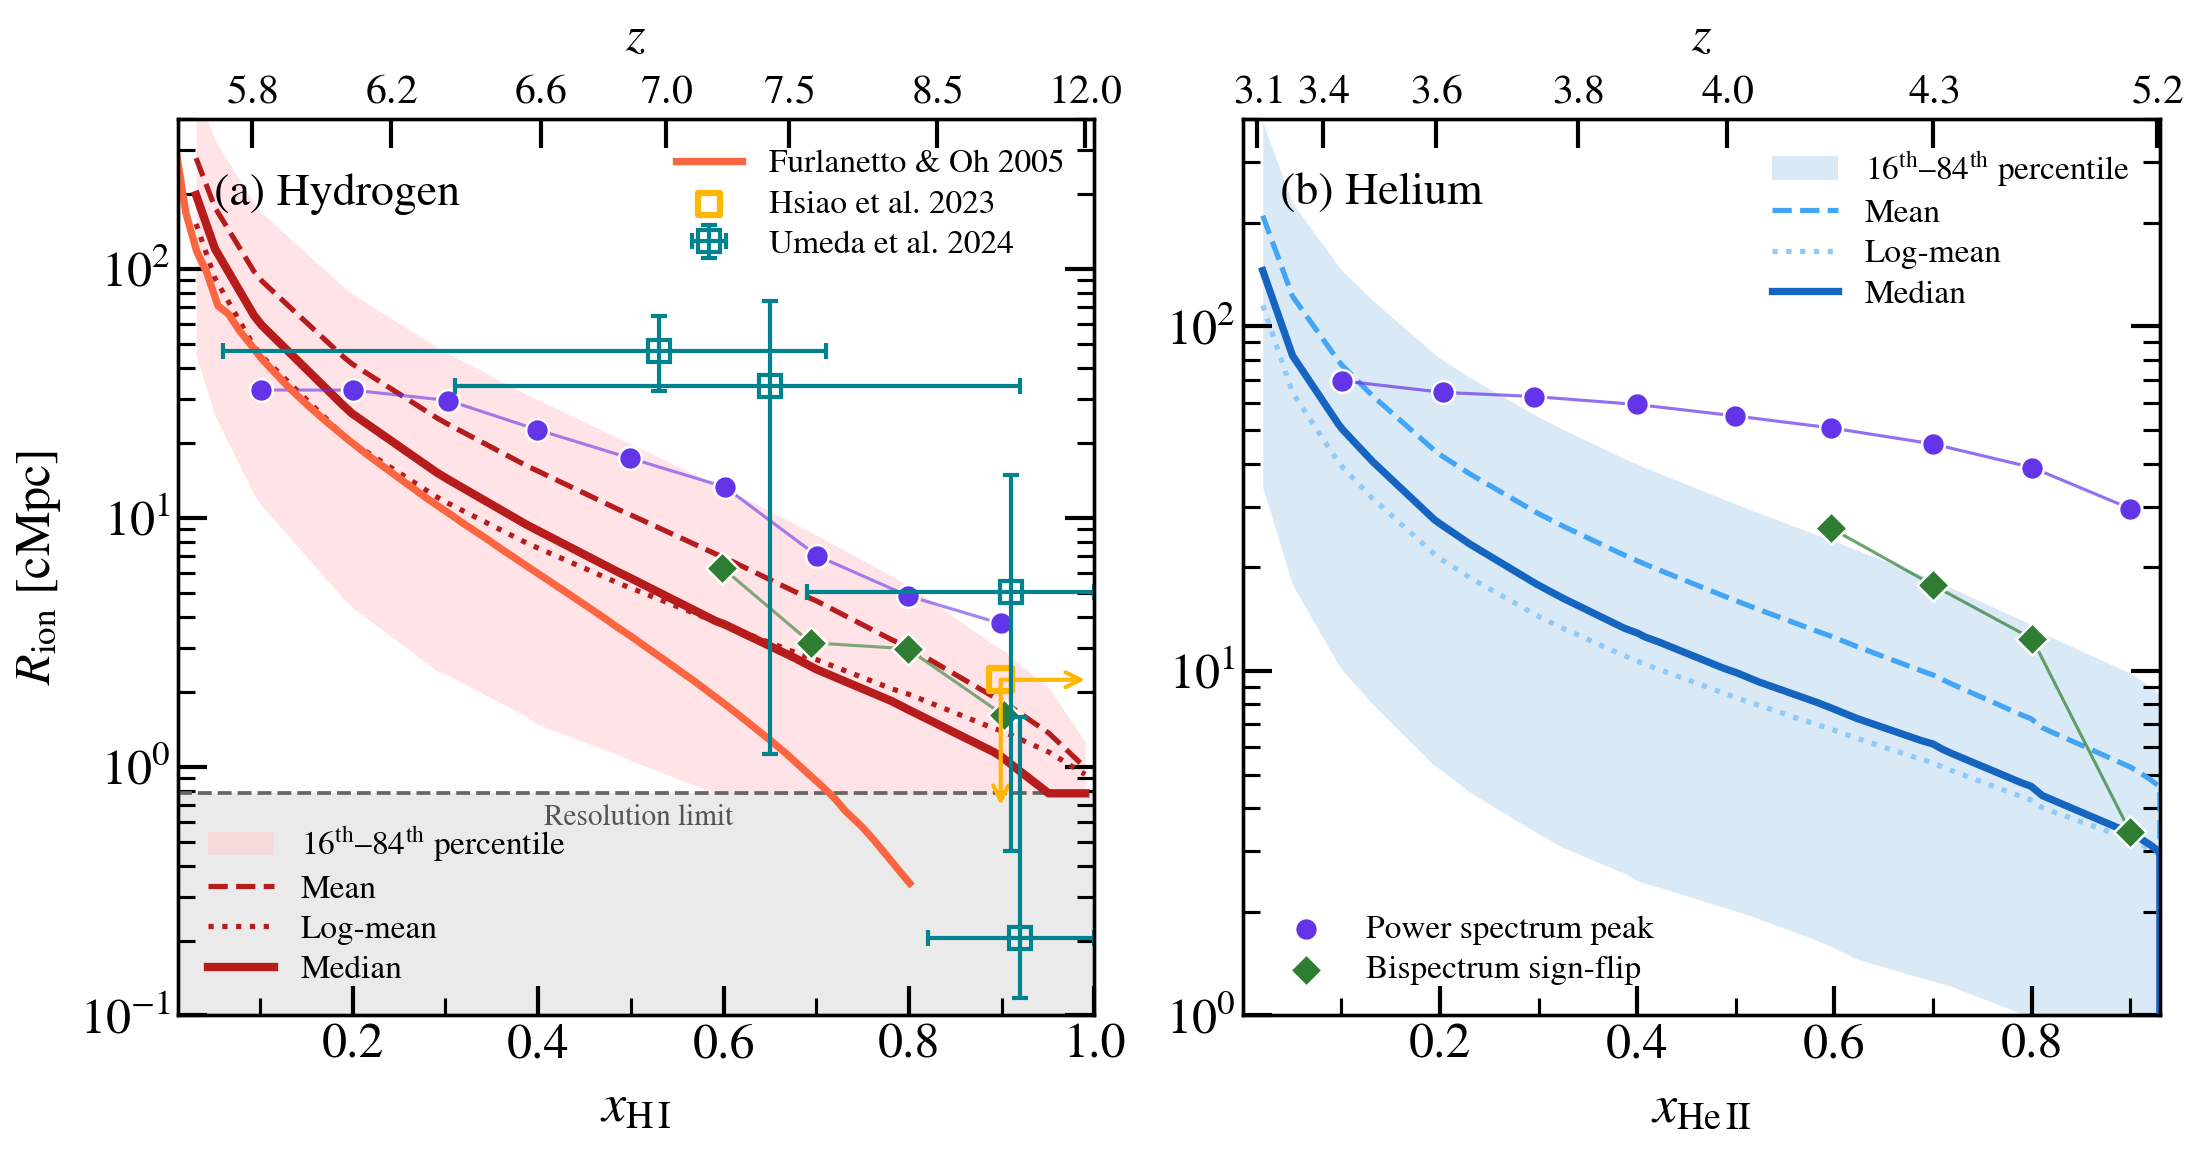

In [22]:
import os
import glob
import h5py
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import LogLocator, NullFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# =====================================================
# Global rcParams (Matplotlib Styling Upgraded)
# =====================================================
matplotlib.rcParams.update({
    "font.family":         "STIXGeneral",
    "mathtext.fontset":   "stix",
    "font.size":          18,          # Scaled up from 14
    "axes.linewidth":     1.6,          # Thicker frame lines
    "axes.labelsize":     24,          # Scaled up from 18
    "axes.titlesize":     22,          # Scaled up from 16
    # X-Ticks
    "xtick.major.size":   20,   # Length of major ticks (was 10)
    "xtick.minor.size":   8,    # Length of minor ticks (was 5.5)
    "xtick.major.width":  2.0,  # Thickness of major ticks (was 1.6)
    "xtick.minor.width":  1.5,  # Thickness of minor ticks (was 1.1)
    "xtick.labelsize":    24,   # Font size of the tick numbers (was 18)
    "xtick.direction":    "in",
    "xtick.top":          True,
    # Y-Ticks
    "ytick.major.size":   14,  
    "ytick.minor.size":   8,    
    "ytick.major.width":  2.0,  
    "ytick.minor.width":  1.5,  
    "ytick.labelsize":    24,
    "ytick.direction":    "in",
    "ytick.right":         True,
    "legend.fontsize":    14,          # Scaled up from 11
    "legend.frameon":     False,
    "legend.handlelength":2.0,
    "lines.linewidth":    2.5,
    "figure.dpi":         150,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",    
})

N_RESOLVED_BINS = 1000000
R_GLOBAL_MIN    = 0.1
R_GLOBAL_MAX    = 1000.0

def rebin_by_overlap(edges_src, counts_src, edges_dst):
    """Rebin a histogram by calculating exact 1D overlap weights."""
    out = np.zeros(len(edges_dst) - 1)
    for j in range(len(counts_src)):
        count = counts_src[j]
        if count == 0: continue
        lo, hi = edges_src[j], edges_src[j + 1]
        width  = hi - lo
        if width <= 0: continue
        i_lo = max(np.searchsorted(edges_dst, lo, side="right") - 1, 0)
        i_hi = min(np.searchsorted(edges_dst, hi, side="left"), len(out) - 1)
        for k in range(i_lo, i_hi + 1):
            overlap = min(hi, edges_dst[k + 1]) - max(lo, edges_dst[k])
            if overlap > 0:
                out[k] += count * overlap / width
    return out

# =====================================================
# 1. HYDROGEN DATA PROCESSING
# =====================================================
DATA_DIR_H = "/orcd/data/mvogelsb/004/chcho/mfp-bubbles-thesan/output/LUMINA_hydrogen"
files_h = sorted(glob.glob(os.path.join(DATA_DIR_H, "mfp_*.hdf5")))
if len(files_h) == 0:
    raise RuntimeError(f"No H files found in {DATA_DIR_H}")

with h5py.File(files_h[0], "r") as f:
    boxsize    = float(f["Header"].attrs["BoxSize"])
    hubble     = float(f["Header"].attrs["HubbleParam"])
    box_cMpc   = boxsize / hubble / 1000.0
    Ngrid      = int(f["Header"].attrs["NumPixels"])
    cell_size_h = box_cMpc / Ngrid

R_min_h = cell_size_h
resolved_edges_h = np.logspace(np.log10(R_min_h), np.log10(R_GLOBAL_MAX), N_RESOLVED_BINS + 1)
bin_edges_h       = np.concatenate([[R_GLOBAL_MIN], resolved_edges_h])
R_centers_h       = np.sqrt(bin_edges_h[:-1] * bin_edges_h[1:])
R_centers_h[0] = R_min_h   # = cell_size_h
dlogR_h          = np.diff(np.log10(bin_edges_h))

snap_to_fHII = {
    112: 0.01, 129: 0.02, 140: 0.03, 148: 0.04, 154: 0.05, 160: 0.06, 165: 0.07, 169: 0.08, 173: 0.09, 177: 0.10,
    203: 0.20, 220: 0.30, 242: 0.40, 264: 0.50, 283: 0.60, 300: 0.70, 318: 0.80, 338: 0.90, 341: 0.91, 343: 0.92,
    346: 0.93, 349: 0.94, 352: 0.95, 356: 0.96, 360: 0.97, 366: 0.98, 374: 0.99,
}
snap_to_redshift_h = {
    112: 12.006999, 129: 11.205740, 140: 10.718889, 148: 10.363529, 154: 10.081991, 160:  9.847533, 165:  9.645984,
    169:  9.469432, 173:  9.311993, 177:  9.170129, 203:  8.207879, 220:  7.624910, 242:  7.204283, 264:  6.872631,
    283:  6.592783, 300:  6.342011, 318:  6.099902, 338:  5.826679, 341:  5.794754, 343:  5.761251, 346:  5.725699,
    349:  5.687586, 352:  5.645994, 356:  5.599397, 360:  5.545151, 366:  5.477609, 374:  5.379672,
}

_snaps_h   = np.array(sorted(snap_to_redshift_h.keys()))
_z_table_h = np.array([snap_to_redshift_h[s] for s in _snaps_h])
_f_table_h = np.array([snap_to_fHII[s]     for s in _snaps_h])
_sort_h    = np.argsort(_z_table_h)
_z_table_h, _f_table_h = _z_table_h[_sort_h], _f_table_h[_sort_h]

def z_to_xHII(z): return np.interp(z, _z_table_h, _f_table_h)

z_all_h, mean_all_h, median_all_h, logmean_all_h, p16_all_h, p84_all_h = [], [], [], [], [], []
for fp in files_h:
    with h5py.File(fp, "r") as f:
        z = float(f["Header"].attrs["Redshift"])
        hist = f["mfp_hist"][:].astype(float)
        n_bins_native = len(hist)
        n_bins_per_cell = int(f["Header"].attrs["NumBinsPerCell"])
    edges_native = np.arange(n_bins_native + 1) / n_bins_per_cell * cell_size_h
    hist_rebin   = rebin_by_overlap(edges_native, hist, bin_edges_h)
    total = hist_rebin.sum()
    if total == 0: continue
    P = hist_rebin / total
    mask_stat = P > 0
    R_stat    = R_centers_h[mask_stat]   
    P_stat    = P[mask_stat]
    cdf       = np.cumsum(P_stat)
    z_all_h.append(z)
    mean_all_h.append(np.sum(P_stat * R_stat))
    logmean_all_h.append(10 ** np.sum(P_stat * np.log10(R_stat)))
    median_all_h.append(np.interp(0.50, cdf, R_stat))
    p16_all_h.append(np.interp(0.16, cdf, R_stat))
    p84_all_h.append(np.interp(0.84, cdf, R_stat))

sort_idx_h = np.argsort(z_all_h)
z_all_h, mean_all_h, median_all_h, logmean_all_h, p16_all_h, p84_all_h = [np.array(x)[sort_idx_h] for x in [z_all_h, mean_all_h, median_all_h, logmean_all_h, p16_all_h, p84_all_h]]
xHI_all = 1.0 - z_to_xHII(z_all_h)

# Hydrogen Literature Setup
z_ps_h  = np.array([9.16, 8.20, 7.63, 7.21, 6.87, 6.59, 6.35, 6.10, 5.83])
R_ps_h  = np.array([2.544, 3.288, 4.763, 8.999, 11.747, 15.292, 20.024, 22.041, 22.073]) / hubble
xHI_ps  = 1.0 - z_to_xHII(z_ps_h)

z_bispec_h  = np.array([9.2, 8.2, 7.6, 7.2])
R_bispec_h  = np.array([1.08827, 2.01348, 2.12863, 4.25726]) / hubble
xHI_bispec = 1.0 - z_to_xHII(z_bispec_h)

z_hsiao, R_hsiao = np.array([9.16]), np.array([2.234])
xHI_hsiao = 1.0 - z_to_xHII(z_hsiao)

xHI_umeda, xHI_err_low, xHI_err_high = np.array([0.53, 0.65, 0.91, 0.92]), np.array([0.47, 0.34, 0.22, 0.10]), np.array([0.18, 0.27, 0.09, 0.08])
logRb, logRb_err_low, logRb_err_high = np.array([1.67, 1.53, 0.70, -0.69]), np.array([0.16, 1.48, 1.04, 0.24]), np.array([0.14, 0.34, 0.47, 0.89])
Rb_umeda = 10**logRb
Rb_low, Rb_high = Rb_umeda - 10**(logRb - logRb_err_low), 10**(logRb + logRb_err_high) - Rb_umeda

xi_furlanetto = np.array([0.1992, 0.2109, 0.2226, 0.2385, 0.2503, 0.2687, 0.2804, 0.2921, 0.3089, 0.3206, 0.3324, 0.3499, 0.3617, 0.3726, 0.3910, 0.4027, 0.4145, 0.4329, 0.4438, 0.4555, 0.4739, 0.4857, 0.4974, 0.5150, 0.5267, 0.5384, 0.5569, 0.5686, 0.5795, 0.5987, 0.6105, 0.6222, 0.6398, 0.6515, 0.6632, 0.6817, 0.6934, 0.7043, 0.7227, 0.7345, 0.7462, 0.7646, 0.7755, 0.7872, 0.8057, 0.8174, 0.8291, 0.8459, 0.8576, 0.8693, 0.8877, 0.8995, 0.9104, 0.9221, 0.9338, 0.9455, 0.9573, 0.9682, 0.9799, 0.9900])
R_furlanetto = np.array([0.3400, 0.3830, 0.4330, 0.5102, 0.5715, 0.6636, 0.7469, 0.8229, 0.9382, 1.0277, 1.1279, 1.2792, 1.3868, 1.4958, 1.6944, 1.8320, 1.9750, 2.2242, 2.3746, 2.5527, 2.8536, 3.0616, 3.2919, 3.6405, 3.9111, 4.1886, 4.6573, 4.9884, 5.3024, 5.9213, 6.3318, 6.7762, 7.4903, 8.0340, 8.5978, 9.5410, 10.2468, 10.9140, 12.1634, 13.1065, 14.0946, 15.8179, 16.9384, 18.2749, 20.7074, 22.5165, 24.4675, 27.7386, 30.4569, 33.5082, 39.5524, 44.0926, 49.8666, 56.4022, 65.7361, 71.1672, 96.6880, 117.2752, 167.3574, 290.0000])
xHI_furlanetto = 1.0 - xi_furlanetto

# Neyer et al. 2024 Data (Extracted)
xHI_neyer = np.array([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
R_neyer = np.array([125.0, 40.0, 18.0, 10.0, 6.0, 3.5, 2.2, 1.4, 1.0, 0.6, 0.25])

# =====================================================
# 2. HELIUM DATA PROCESSING (Corrected File Scope)
# =====================================================

N_RESOLVED_BINS = 1000000
DATA_DIR_HE = "/orcd/data/mvogelsb/004/chcho/mfp-bubbles-thesan/output/LUMINA_helium"
files_he = sorted(glob.glob(os.path.join(DATA_DIR_HE, "mfp_*.hdf5")))
if len(files_he) == 0:
    raise RuntimeError(f"No He files found in {DATA_DIR_HE}")

with h5py.File(files_he[0], "r") as f:
    cell_size_he = (float(f["Header"].attrs["BoxSize"]) / hubble / 1000.0) / int(f["Header"].attrs["NumPixels"])

R_min_he = cell_size_he
resolved_edges_he = np.logspace(np.log10(R_min_he), np.log10(R_GLOBAL_MAX), N_RESOLVED_BINS + 1)
bin_edges_he       = np.concatenate([[R_GLOBAL_MIN], resolved_edges_he])
R_centers_he       = np.sqrt(bin_edges_he[:-1] * bin_edges_he[1:])
R_centers_he[0]   = R_min_he
dlogR_he          = np.diff(np.log10(bin_edges_he))

snap_to_fHeIII = {695: 0.01, 660: 0.02, 644: 0.03, 633: 0.04, 624: 0.05, 618: 0.06, 612: 0.07, 606: 0.08, 601: 0.09, 596: 0.10, 558: 0.20, 529: 0.30, 514: 0.40, 500: 0.50, 487: 0.60, 471: 0.70, 450: 0.80, 406: 0.90, 401: 0.91, 394: 0.92, 387: 0.93}
snap_to_redshift_he = {695: 3.035828, 660: 3.172945, 644: 3.238152, 633: 3.283318, 624: 3.318701, 618: 3.347722, 612: 3.373351, 606: 3.396815, 601: 3.418623, 596: 3.439090, 558: 3.606240, 529: 3.746897, 514: 3.880495, 500: 4.011606, 487: 4.144300, 471: 4.299100, 450: 4.517370, 406: 4.999257, 401: 5.062160, 394: 5.134098, 387: 5.223496}

_snaps_he   = np.array(sorted(snap_to_redshift_he.keys()))
_z_table_he = np.array([snap_to_redshift_he[s] for s in _snaps_he])
_f_table_he = np.array([snap_to_fHeIII[s] for s in _snaps_he])
_sort_he    = np.argsort(_z_table_he)
_z_table_he, _f_table_he = _z_table_he[_sort_he], _f_table_he[_sort_he]

def z_to_xHeIII(z): return np.interp(z, _z_table_he, _f_table_he)

z_all_he, mean_all_he, median_all_he, logmean_all_he, p16_all_he, p84_all_he = [], [], [], [], [], []
for fp in files_he:
    with h5py.File(fp, "r") as f:
        z = float(f["Header"].attrs["Redshift"])
        hist = f["mfp_hist"][:].astype(float)
        n_bins_per_cell = int(f["Header"].attrs["NumBinsPerCell"])
        
    hist_rebin = rebin_by_overlap(np.arange(len(hist) + 1) / n_bins_per_cell * cell_size_he, hist, bin_edges_he)
    total = hist_rebin.sum()
    if total == 0: continue
    P = hist_rebin / total
    mask_stat = P > 0
    R_stat    = R_centers_he[mask_stat]  
    P_stat    = P[mask_stat]
    cdf       = np.cumsum(P_stat)
    
    z_all_he.append(z)
    mean_all_he.append(np.sum(P_stat * R_stat))
    logmean_all_he.append(10 ** np.sum(P_stat * np.log10(R_stat)))
    median_all_he.append(np.interp(0.50, cdf, R_stat))
    p16_all_he.append(np.interp(0.16, cdf, R_stat))
    p84_all_he.append(np.interp(0.84, cdf, R_stat))

sort_idx_he = np.argsort(z_all_he)
z_all_he, mean_all_he, median_all_he, logmean_all_he, p16_all_he, p84_all_he = [np.array(x)[sort_idx_he] for x in [z_all_he, mean_all_he, median_all_he, logmean_all_he, p16_all_he, p84_all_he]]
xHe_all = z_to_xHeIII(z_all_he)

# Helium Literature Setup
z_ps_he  = np.array([5.00, 4.52, 4.30, 4.14, 4.01, 3.88, 3.74, 3.61, 3.44])
R_ps_he  = np.array([20.023, 26.353, 30.841, 34.348, 37.238, 40.181, 42.373, 43.565, 47.064]) / hubble
#R_ps_he  = np.array([20.452, 25.749, 30.390, 33.819, 36.550, 39.431, 41.624, 43.081, 47.186]) / hubble
xHe_ps   = z_to_xHeIII(z_ps_he)



z_bispec_he = np.array([5.00, 4.52, 4.30, 4.14]) 
R_bispec_he = np.array([2.30112, 8.39200, 11.9886, 17.5531]) / hubble 
xHe_bispec  = z_to_xHeIII(z_bispec_he)

# =====================================================
# 3. UNIFIED 2-PANEL SCIENCE PLOT
# =====================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8.0)) # Slightly taller layout
plt.subplots_adjust(wspace=0.08) # Opened spacing slightly for clear label isolation

# -----------------------------------------------------
# PANEL (a) HYDROGEN REIONIZATION
# -----------------------------------------------------
C_FILL_H   = "#FFCDD2"    #"#FFCDD2"  
C_MEDIAN_H = "#B71C1C"  
C_MEAN_H   = "#B71C1C"  #"#F44336"  
C_LMEAN_H  = "#B71C1C"  #"#FF8A80"  
C_PS_H     = "#6434e9" #1565C0"  
C_BIS_H    = "#2E7D32"  
C_HSIAO    = "#ffb703"  #6A1B9A
C_UMEDA    = "#00838F"  
C_FURL     = "#fb6640" #"royalblue"
#C_NEYER    = "darkorange" # Highly visible, avoids red/green/blue

ax1.fill_between(xHI_all, p16_all_h, p84_all_h, color=C_FILL_H, alpha=0.55, lw=0, label=r"$16^{\rm th}$–$84^{\rm th}$ percentile")
ax1.plot(xHI_all, mean_all_h,     color=C_MEAN_H,   lw=2.5, ls="--", zorder=3, label=r"Mean")
ax1.plot(xHI_all, logmean_all_h, color=C_LMEAN_H,  lw=2.5, ls=":",  zorder=3, label=r"Log-mean")
ax1.plot(xHI_all, median_all_h,  color=C_MEDIAN_H, lw=4, ls="-",  zorder=4, label=r"Median")

ax1.plot(xHI_ps, R_ps_h, color=C_PS_H, lw=1.5, ls="-", alpha=0.6, zorder=5)
ax1.scatter(xHI_ps, R_ps_h, s=120, color=C_PS_H, marker="o", zorder=6, edgecolors="white", linewidths=1.2)#, label=r"Power spectrum peak")

ax1.plot(xHI_bispec, R_bispec_h, color=C_BIS_H, lw=1.5, ls="-", alpha=0.6, zorder=5)
ax1.scatter(xHI_bispec, R_bispec_h, s=120, color=C_BIS_H, marker="D", zorder=6, edgecolors="white", linewidths=1.2)#, label=r"Bispectrum sign-flip")

ax1.scatter(xHI_hsiao, R_hsiao, s=120, color="none", marker="s", zorder=7, edgecolors=C_HSIAO, linewidths=3.0, label=r"Hsiao et al. 2023")
ax1.plot(xHI_furlanetto, R_furlanetto, color=C_FURL, lw=3.5, ls="-", zorder=6, label=r"Furlanetto & Oh 2005")

# Plot Neyer Data
#ax1.plot(xHI_neyer, R_neyer, color=C_NEYER, lw=3.0, ls="-", zorder=8, label=r"Neyer et al. 2024")

xHI_z12_target = 1.0 - z_to_xHII(12.0)
ax1.annotate("", xy=(xHI_z12_target, R_hsiao[0]), xytext=(xHI_hsiao[0], R_hsiao[0]), arrowprops=dict(arrowstyle="->", color=C_HSIAO, lw=2.0, shrinkA=0, shrinkB=0), zorder=7)
ax1.annotate("", xy=(xHI_hsiao[0], 0.7), xytext=(xHI_hsiao[0], R_hsiao[0]), arrowprops=dict(arrowstyle="->", color=C_HSIAO, lw=2.0, shrinkA=0, shrinkB=0), zorder=7)

ax1.errorbar(
    xHI_umeda, Rb_umeda, xerr=[xHI_err_low, xHI_err_high], yerr=[Rb_low, Rb_high],
    fmt="s", ms=11, mfc="none", mec=C_UMEDA, mew=2.0, ecolor=C_UMEDA, elinewidth=2.0, capsize=4, linestyle="none", zorder=7, label=r"Umeda et al. 2024"
)

ax1.set_xlabel(r"$x_{\rm H\,I}$", fontsize=26, labelpad=8)
ax1.set_ylabel(r"$R_{\rm ion}\ [\mathrm{cMpc}]$", fontsize=24, labelpad=8)
ax1.set_yscale("log")
xHI_lo, xHI_hi = max(xHI_all.min() - 0.02, 0.0), min(xHI_all.max() + 0.02, 1.0)
ax1.set_xlim(xHI_lo, xHI_hi)
ax1.text(0.04, 0.94, "(a) Hydrogen", transform=ax1.transAxes, fontsize=22, va="top")

# Split Legend Layout for Panel A
handles_h, labels_h = ax1.get_legend_handles_labels()
# Updated list to include Neyer et al. 2024
upper_right_labels_h = ["Furlanetto & Oh 2005", "Hsiao et al. 2023", "Umeda et al. 2024", "Neyer et al. 2024"]
h1, l1, h2, l2 = [], [], [], []
for h, l in zip(handles_h, labels_h):
    if l in upper_right_labels_h: h2.append(h); l2.append(l)
    else: h1.append(h); l1.append(l)

sorted_h2, sorted_l2 = [], []
for target in upper_right_labels_h:
    if target in l2:
        idx = l2.index(target)
        sorted_h2.append(h2[idx]); sorted_l2.append(l2[idx])

leg1_h = ax1.legend(h1, l1, loc="lower left", fontsize=16, borderpad=0.4, labelspacing=0.3, frameon=False)
ax1.add_artist(leg1_h)
ax1.legend(sorted_h2, sorted_l2, loc="upper right", fontsize=16, borderpad=0.4, labelspacing=0.3, frameon=False)

# Twin Redshift Top Axis (Panel A)
ax_top1 = ax1.twiny()
z_ticks_c1 = np.array([5.8, 6.2, 6.6, 7.0, 7.5, 8.5, 12.0])
z_ticks_1 = z_ticks_c1[(z_ticks_c1 >= _z_table_h.min()) & (z_ticks_c1 <= _z_table_h.max())]
xHI_tick_pos = 1.0 - z_to_xHII(z_ticks_1)
in_range1 = (xHI_tick_pos >= xHI_lo) & (xHI_tick_pos <= xHI_hi)
ax_top1.set_xlim(ax1.get_xlim())
ax_top1.set_xticks(xHI_tick_pos[in_range1])
ax_top1.set_xticklabels([f"${z:.1f}$" for z in z_ticks_1[in_range1]], fontsize=16)
ax_top1.set_xlabel(r"$z$", fontsize=24, labelpad=12)
ax_top1.tick_params(which="major", direction="in", length=10, width=1.6)

# -----------------------------------------------------
# PANEL (b) HELIUM REIONIZATION
# -----------------------------------------------------
C_FILL_HE   = "#BBD9F0"  
C_MEDIAN_HE = "#1565C0"  
C_MEAN_HE   = "#42A5F5"  
C_LMEAN_HE  = "#90CAF9"  
C_PS_HE     = "#6434e9"  
C_BIS_HE    = "#2E7D32"  

ax2.fill_between(xHe_all, p16_all_he, p84_all_he, color=C_FILL_HE, alpha=0.55, lw=0, label=r"$16^{\mathrm{th}}$–$84^{\mathrm{th}}$ percentile")
ax2.plot(xHe_all, mean_all_he,     color=C_MEAN_HE,   lw=2.5, ls="--", zorder=3, label=r"Mean")
ax2.plot(xHe_all, logmean_all_he, color=C_LMEAN_HE,  lw=2.5, ls=":",  zorder=3, label=r"Log-mean")
ax2.plot(xHe_all, median_all_he,  color=C_MEDIAN_HE, lw=3.5, ls="-",  zorder=4, label=r"Median")

ax2.plot(xHe_ps, R_ps_he, color=C_PS_HE, lw=1.5, ls="-", alpha=0.7, zorder=5)
ax2.scatter(xHe_ps, R_ps_he, s=120, color=C_PS_HE, marker="o", zorder=6, edgecolors="white", linewidths=1.2, label=r"Power spectrum peak")

ax2.plot(xHe_bispec, R_bispec_he, color=C_BIS_HE, lw=1.5, ls="-", alpha=0.7, zorder=5)
ax2.scatter(xHe_bispec, R_bispec_he, s=120, color=C_BIS_HE, marker="D", zorder=6, edgecolors="white", linewidths=1.2, label=r"Bispectrum sign-flip")

ax2.set_xlabel(r"$x_{\mathrm{He\,II}}$", fontsize=26, labelpad=8)
xHe_lo, xHe_hi = max(xHe_all.min() - 0.02, 0.0), min(xHe_all.max() + 0.02, 1.0)
ax2.set_xlim(xHe_lo, 0.93)#xHe_hi
ax2.text(0.04, 0.94, "(b) Helium", transform=ax2.transAxes, fontsize=22, va="top")

#ax2.legend(loc="upper right", fontsize=14, borderpad=0.4, labelspacing=0.3, frameon=False)
# Split legend for panel (b)
handles_he, labels_he = ax2.get_legend_handles_labels()

# Upper right: LUMINA statistics only
stat_labels = [
    r"$16^{\mathrm{th}}$–$84^{\mathrm{th}}$ percentile",
    r"Mean",
    r"Log-mean",
    r"Median",
]
lit_labels = [
    r"Power spectrum peak",
    r"Bispectrum sign-flip",
]

h_stat = [h for h, l in zip(handles_he, labels_he) if l in stat_labels]
l_stat = [l for l in labels_he if l in stat_labels]

h_lit  = [h for h, l in zip(handles_he, labels_he) if l in lit_labels]
l_lit  = [l for l in labels_he if l in lit_labels]

leg_stat = ax2.legend(h_stat, l_stat,
                      loc="upper right", fontsize=16,
                      borderpad=0.4, labelspacing=0.3, frameon=False)
ax2.add_artist(leg_stat)

ax2.legend(h_lit, l_lit,
           loc="lower left", fontsize=16,
           borderpad=0.4, labelspacing=0.3, frameon=False)

# Twin Redshift Top Axis (Panel B)
ax_top2 = ax2.twiny()
z_ticks_c2 = np.array([3.1, 3.4, 3.6, 3.8, 4.0, 4.3, 5.2])
z_ticks_2 = z_ticks_c2[(z_ticks_c2 >= _z_table_he.min()) & (z_ticks_c2 <= _z_table_he.max())]
xHe_tick_pos = z_to_xHeIII(z_ticks_2)
in_range2 = (xHe_tick_pos >= xHe_lo) & (xHe_tick_pos <= xHe_hi)
ax_top2.set_xlim(ax2.get_xlim()) #ax2.get_xlim()
ax_top2.set_ylim(1,300)
ax_top2.set_yscale("log", nonpositive="clip")
ax_top2.set_xticks(xHe_tick_pos[in_range2])
ax_top2.set_xticklabels([f"${z:.1f}$" for z in z_ticks_2[in_range2]], fontsize=16)
ax_top2.set_xlabel(r"$z$", fontsize=24, labelpad=12)
ax_top2.tick_params(which="major", direction="in", length=10, width=1.6)

for ax in [ax1, ax2]:
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax.yaxis.set_major_locator(LogLocator(base=10, numticks=6))
    ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1, numticks=20))
    ax.yaxis.set_minor_formatter(NullFormatter())
    
    # --- BUMPED UP TICK SIZE & LABELS HERE ---
    ax.tick_params(which="major", direction="in", length=14, width=2.0, labelsize=24) 
    ax.tick_params(which="minor", direction="in", length=8, width=1.5)               
    
for ax_top in [ax_top1, ax_top2]:
    ax_top.xaxis.set_minor_locator(ticker.NullLocator())
    # Adjust the top twin redshift axes to match the new size
    ax_top.tick_params(which="major", direction="in", length=14, width=2.0, labelsize=20)

# =====================================================
# Resolution limit shading
# y = 500/640 ≈ 0.781 cMpc  — below this is unresolved
# =====================================================
ax1.set_ylim(0.1, 400.0)
ax2.set_ylim(1, 400.0)

R_res_h  = 500.0 / 640.0    # cMpc — hydrogen resolution limit
R_res_he = 500.0 / 640.0    # cMpc — helium resolution limit

for ax, R_res in [(ax1, R_res_h)]: 
    # Shaded region below resolution limit
    ylo = ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else 1e-2
    ax.axhspan(1.0e-2, R_res,
                color="#bbbbbb", alpha=0.30, zorder=0, lw=0)
    # Dashed horizontal line at the limit
    ax.axhline(R_res, color="#666666", ls="--", lw=1.8, zorder=3)
    # Text label — placed just above the line, left side
    ax.text(
        ax.get_xlim()[0] + 0.4 * (ax.get_xlim()[1] - ax.get_xlim()[0]),
        R_res * 0.7,
        "Resolution limit",
        color="#555555", fontsize=14,
        va="bottom", ha="left", zorder=4
    )

plt.tight_layout()
#plt.savefig("BSD.png")
plt.show()

---

Old

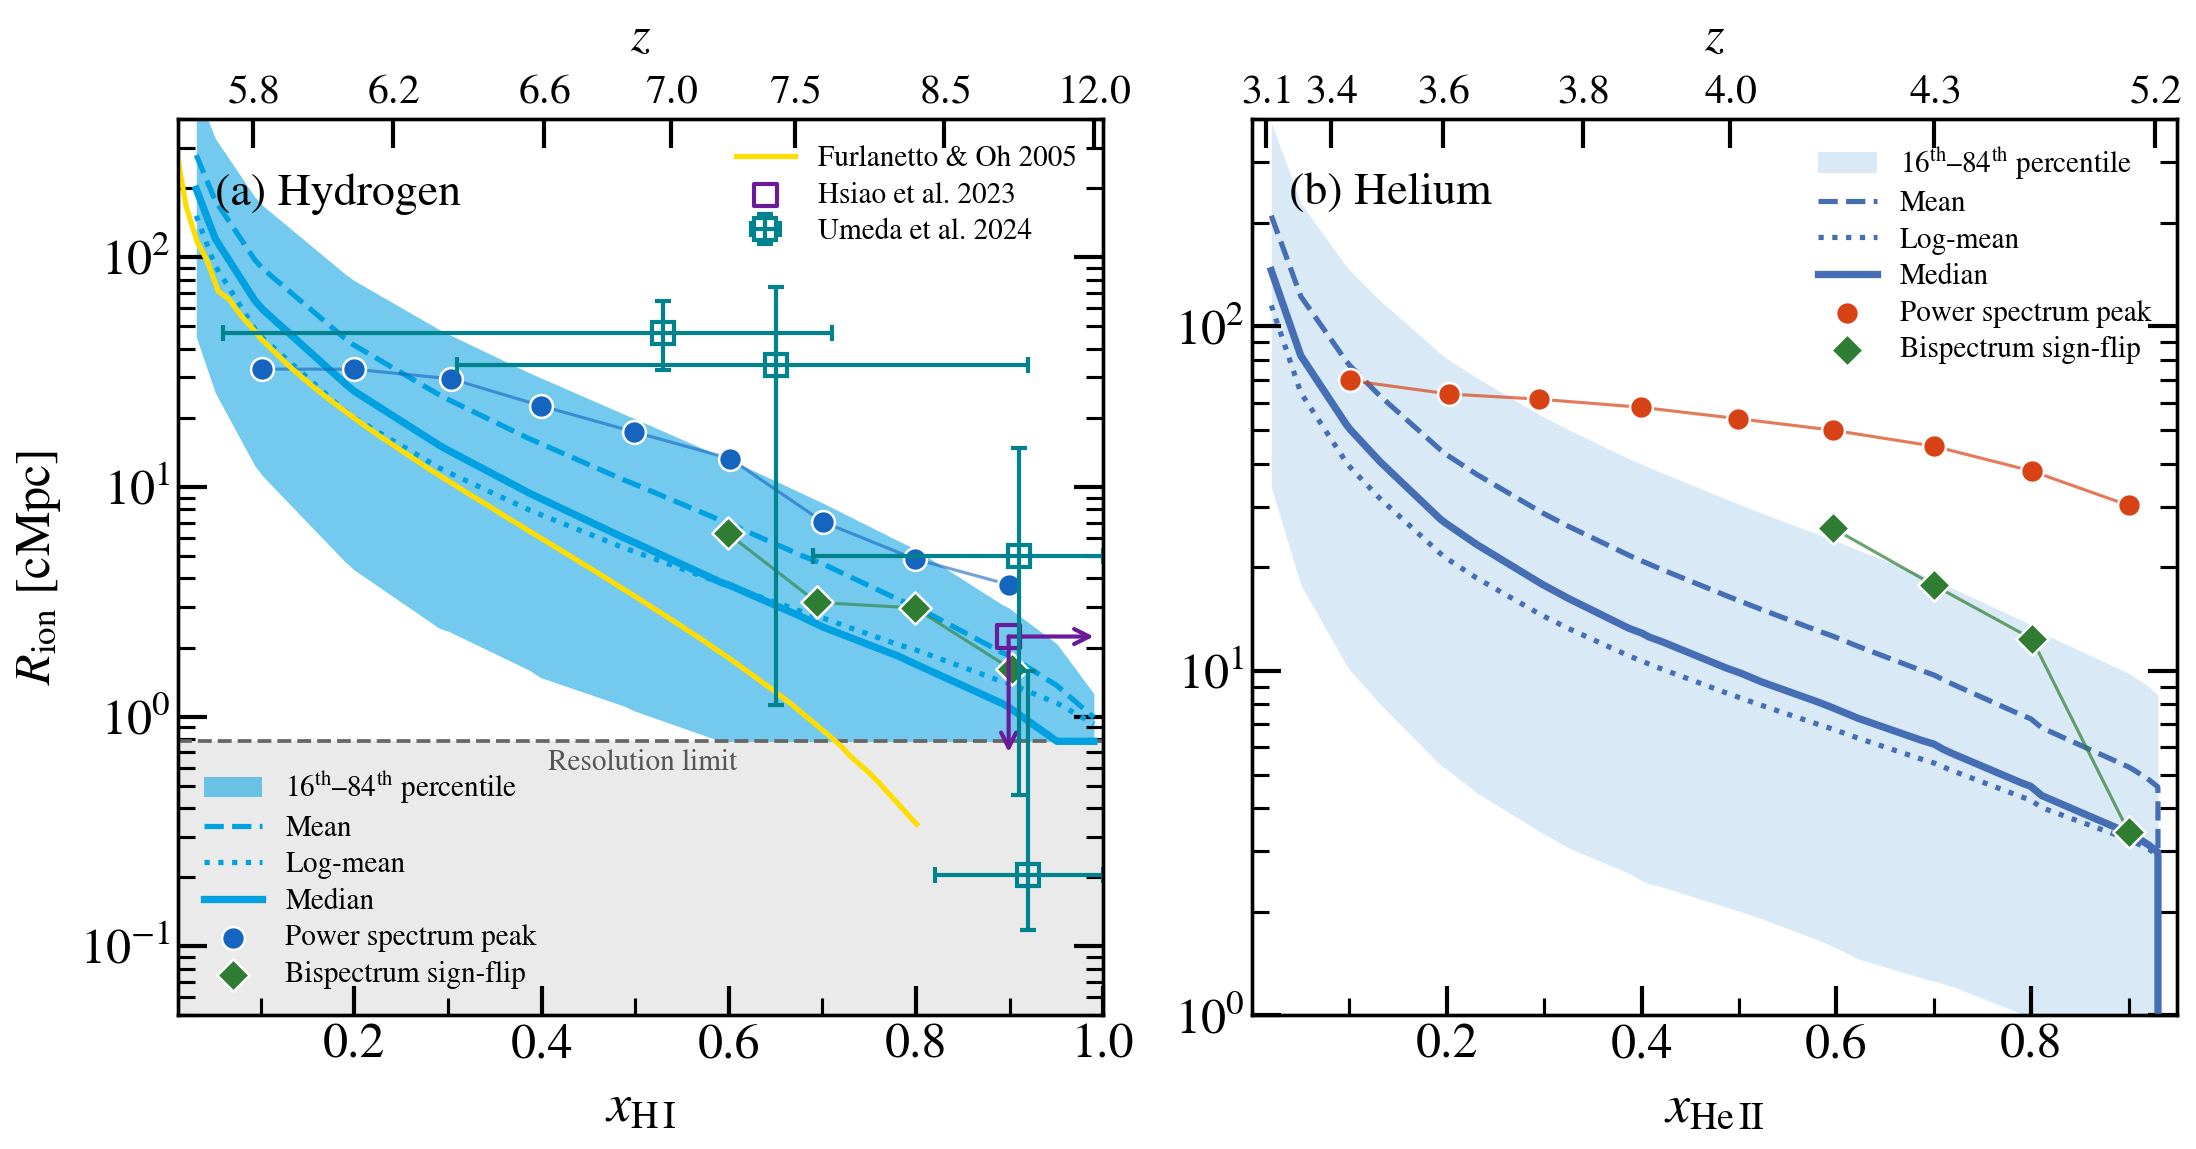

In [7]:
import os
import glob
import h5py
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import LogLocator, NullFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# =====================================================
# Global rcParams (Matplotlib Styling Upgraded)
# =====================================================
matplotlib.rcParams.update({
    "font.family":         "STIXGeneral",
    "mathtext.fontset":   "stix",
    "font.size":          18,          # Scaled up from 14
    "axes.linewidth":     1.6,          # Thicker frame lines
    "axes.labelsize":     24,          # Scaled up from 18
    "axes.titlesize":     22,          # Scaled up from 16
    # X-Ticks
    "xtick.major.size":   20,   # Length of major ticks (was 10)
    "xtick.minor.size":   8,    # Length of minor ticks (was 5.5)
    "xtick.major.width":  2.0,  # Thickness of major ticks (was 1.6)
    "xtick.minor.width":  1.5,  # Thickness of minor ticks (was 1.1)
    "xtick.labelsize":    24,   # Font size of the tick numbers (was 18)
    "xtick.direction":    "in",
    "xtick.top":          True,
    "xtick.labelsize":    18,          # Scaled up from 14
    # Y-Ticks
    "ytick.major.size":   14,   
    "ytick.minor.size":   8,    
    "ytick.major.width":  2.0,  
    "ytick.minor.width":  1.5,  
    "ytick.labelsize":    24,
    "ytick.direction":    "in",
    "ytick.right":         True,
    "legend.fontsize":    14,          # Scaled up from 11
    "legend.frameon":     False,
    "legend.handlelength":2.0,
    "lines.linewidth":    2.5,
    "figure.dpi":         150,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",    
})

N_RESOLVED_BINS = 1000000
R_GLOBAL_MIN    = 0.1
R_GLOBAL_MAX    = 1000.0

def rebin_by_overlap(edges_src, counts_src, edges_dst):
    """Rebin a histogram by calculating exact 1D overlap weights."""
    out = np.zeros(len(edges_dst) - 1)
    for j in range(len(counts_src)):
        count = counts_src[j]
        if count == 0: continue
        lo, hi = edges_src[j], edges_src[j + 1]
        width  = hi - lo
        if width <= 0: continue
        i_lo = max(np.searchsorted(edges_dst, lo, side="right") - 1, 0)
        i_hi = min(np.searchsorted(edges_dst, hi, side="left"), len(out) - 1)
        for k in range(i_lo, i_hi + 1):
            overlap = min(hi, edges_dst[k + 1]) - max(lo, edges_dst[k])
            if overlap > 0:
                out[k] += count * overlap / width
    return out

# =====================================================
# 1. HYDROGEN DATA PROCESSING
# =====================================================
DATA_DIR_H = "/orcd/data/mvogelsb/004/chcho/mfp-bubbles-thesan/output/LUMINA_hydrogen"
files_h = sorted(glob.glob(os.path.join(DATA_DIR_H, "mfp_*.hdf5")))
if len(files_h) == 0:
    raise RuntimeError(f"No H files found in {DATA_DIR_H}")

with h5py.File(files_h[0], "r") as f:
    boxsize    = float(f["Header"].attrs["BoxSize"])
    hubble     = float(f["Header"].attrs["HubbleParam"])
    box_cMpc   = boxsize / hubble / 1000.0
    Ngrid      = int(f["Header"].attrs["NumPixels"])
    cell_size_h = box_cMpc / Ngrid

R_min_h = cell_size_h
resolved_edges_h = np.logspace(np.log10(R_min_h), np.log10(R_GLOBAL_MAX), N_RESOLVED_BINS + 1)
bin_edges_h       = np.concatenate([[R_GLOBAL_MIN], resolved_edges_h])
R_centers_h       = np.sqrt(bin_edges_h[:-1] * bin_edges_h[1:])
#R_centers_h[0]   = np.sqrt(R_GLOBAL_MIN * R_min_h)
R_centers_h[0] = R_min_h   # = cell_size_h
dlogR_h          = np.diff(np.log10(bin_edges_h))

snap_to_fHII = {
    112: 0.01, 129: 0.02, 140: 0.03, 148: 0.04, 154: 0.05, 160: 0.06, 165: 0.07, 169: 0.08, 173: 0.09, 177: 0.10,
    203: 0.20, 220: 0.30, 242: 0.40, 264: 0.50, 283: 0.60, 300: 0.70, 318: 0.80, 338: 0.90, 341: 0.91, 343: 0.92,
    346: 0.93, 349: 0.94, 352: 0.95, 356: 0.96, 360: 0.97, 366: 0.98, 374: 0.99,
}
snap_to_redshift_h = {
    112: 12.006999, 129: 11.205740, 140: 10.718889, 148: 10.363529, 154: 10.081991, 160:  9.847533, 165:  9.645984,
    169:  9.469432, 173:  9.311993, 177:  9.170129, 203:  8.207879, 220:  7.624910, 242:  7.204283, 264:  6.872631,
    283:  6.592783, 300:  6.342011, 318:  6.099902, 338:  5.826679, 341:  5.794754, 343:  5.761251, 346:  5.725699,
    349:  5.687586, 352:  5.645994, 356:  5.599397, 360:  5.545151, 366:  5.477609, 374:  5.379672,
}

_snaps_h   = np.array(sorted(snap_to_redshift_h.keys()))
_z_table_h = np.array([snap_to_redshift_h[s] for s in _snaps_h])
_f_table_h = np.array([snap_to_fHII[s]     for s in _snaps_h])
_sort_h    = np.argsort(_z_table_h)
_z_table_h, _f_table_h = _z_table_h[_sort_h], _f_table_h[_sort_h]

def z_to_xHII(z): return np.interp(z, _z_table_h, _f_table_h)

z_all_h, mean_all_h, median_all_h, logmean_all_h, p16_all_h, p84_all_h = [], [], [], [], [], []
for fp in files_h:
    with h5py.File(fp, "r") as f:
        z = float(f["Header"].attrs["Redshift"])
        hist = f["mfp_hist"][:].astype(float)
        n_bins_native = len(hist)
        n_bins_per_cell = int(f["Header"].attrs["NumBinsPerCell"])
    edges_native = np.arange(n_bins_native + 1) / n_bins_per_cell * cell_size_h
    hist_rebin   = rebin_by_overlap(edges_native, hist, bin_edges_h)
    total = hist_rebin.sum()
    if total == 0: continue
    P = hist_rebin / total
    #mask_stat = (R_centers_h >= R_min_h) & (P > 0)
    #R_stat, P_stat = R_centers_h[mask_stat], P[mask_stat] / P[mask_stat].sum()
    #cdf = np.cumsum(P_stat)
    # AFTER — includes all bins with nonzero P, no renormalization needed
    # P already sums to 1 by construction (hist_rebin / total)
    mask_stat = P > 0
    R_stat    = R_centers_h[mask_stat]   # was R_centers
    P_stat    = P[mask_stat]
    cdf       = np.cumsum(P_stat)
    z_all_h.append(z)
    mean_all_h.append(np.sum(P_stat * R_stat))
    logmean_all_h.append(10 ** np.sum(P_stat * np.log10(R_stat)))
    median_all_h.append(np.interp(0.50, cdf, R_stat))
    p16_all_h.append(np.interp(0.16, cdf, R_stat))
    p84_all_h.append(np.interp(0.84, cdf, R_stat))

sort_idx_h = np.argsort(z_all_h)
z_all_h, mean_all_h, median_all_h, logmean_all_h, p16_all_h, p84_all_h = [np.array(x)[sort_idx_h] for x in [z_all_h, mean_all_h, median_all_h, logmean_all_h, p16_all_h, p84_all_h]]
xHI_all = 1.0 - z_to_xHII(z_all_h)

# Hydrogen Literature Setup
z_ps_h  = np.array([9.16, 8.20, 7.63, 7.21, 6.87, 6.59, 6.35, 6.10, 5.83])
R_ps_h  = np.array([2.544, 3.288, 4.763, 8.999, 11.747, 15.292, 20.024, 22.041, 22.073]) / hubble
xHI_ps  = 1.0 - z_to_xHII(z_ps_h)

z_bispec_h  = np.array([9.2, 8.2, 7.6, 7.2])
R_bispec_h  = np.array([1.08827, 2.01348, 2.12863, 4.25726]) / hubble
xHI_bispec = 1.0 - z_to_xHII(z_bispec_h)

z_hsiao, R_hsiao = np.array([9.16]), np.array([2.234])
xHI_hsiao = 1.0 - z_to_xHII(z_hsiao)

xHI_umeda, xHI_err_low, xHI_err_high = np.array([0.53, 0.65, 0.91, 0.92]), np.array([0.47, 0.34, 0.22, 0.10]), np.array([0.18, 0.27, 0.09, 0.08])
logRb, logRb_err_low, logRb_err_high = np.array([1.67, 1.53, 0.70, -0.69]), np.array([0.16, 1.48, 1.04, 0.24]), np.array([0.14, 0.34, 0.47, 0.89])
Rb_umeda = 10**logRb
Rb_low, Rb_high = Rb_umeda - 10**(logRb - logRb_err_low), 10**(logRb + logRb_err_high) - Rb_umeda

xi_furlanetto = np.array([0.1992, 0.2109, 0.2226, 0.2385, 0.2503, 0.2687, 0.2804, 0.2921, 0.3089, 0.3206, 0.3324, 0.3499, 0.3617, 0.3726, 0.3910, 0.4027, 0.4145, 0.4329, 0.4438, 0.4555, 0.4739, 0.4857, 0.4974, 0.5150, 0.5267, 0.5384, 0.5569, 0.5686, 0.5795, 0.5987, 0.6105, 0.6222, 0.6398, 0.6515, 0.6632, 0.6817, 0.6934, 0.7043, 0.7227, 0.7345, 0.7462, 0.7646, 0.7755, 0.7872, 0.8057, 0.8174, 0.8291, 0.8459, 0.8576, 0.8693, 0.8877, 0.8995, 0.9104, 0.9221, 0.9338, 0.9455, 0.9573, 0.9682, 0.9799, 0.9900])
R_furlanetto = np.array([0.3400, 0.3830, 0.4330, 0.5102, 0.5715, 0.6636, 0.7469, 0.8229, 0.9382, 1.0277, 1.1279, 1.2792, 1.3868, 1.4958, 1.6944, 1.8320, 1.9750, 2.2242, 2.3746, 2.5527, 2.8536, 3.0616, 3.2919, 3.6405, 3.9111, 4.1886, 4.6573, 4.9884, 5.3024, 5.9213, 6.3318, 6.7762, 7.4903, 8.0340, 8.5978, 9.5410, 10.2468, 10.9140, 12.1634, 13.1065, 14.0946, 15.8179, 16.9384, 18.2749, 20.7074, 22.5165, 24.4675, 27.7386, 30.4569, 33.5082, 39.5524, 44.0926, 49.8666, 56.4022, 65.7361, 71.1672, 96.6880, 117.2752, 167.3574, 290.0000])
xHI_furlanetto = 1.0 - xi_furlanetto

# =====================================================
# 2. HELIUM DATA PROCESSING (Corrected File Scope)
# =====================================================

N_RESOLVED_BINS = 1000000
DATA_DIR_HE = "/orcd/data/mvogelsb/004/chcho/mfp-bubbles-thesan/output/LUMINA_helium"
files_he = sorted(glob.glob(os.path.join(DATA_DIR_HE, "mfp_*.hdf5")))
if len(files_he) == 0:
    raise RuntimeError(f"No He files found in {DATA_DIR_HE}")

with h5py.File(files_he[0], "r") as f:
    cell_size_he = (float(f["Header"].attrs["BoxSize"]) / hubble / 1000.0) / int(f["Header"].attrs["NumPixels"])

R_min_he = cell_size_he
resolved_edges_he = np.logspace(np.log10(R_min_he), np.log10(R_GLOBAL_MAX), N_RESOLVED_BINS + 1)
bin_edges_he       = np.concatenate([[R_GLOBAL_MIN], resolved_edges_he])
R_centers_he       = np.sqrt(bin_edges_he[:-1] * bin_edges_he[1:])
#R_centers_he[0]   = np.sqrt(R_GLOBAL_MIN * R_min_he)
R_centers_he[0]   = R_min_he
dlogR_he          = np.diff(np.log10(bin_edges_he))

snap_to_fHeIII = {695: 0.01, 660: 0.02, 644: 0.03, 633: 0.04, 624: 0.05, 618: 0.06, 612: 0.07, 606: 0.08, 601: 0.09, 596: 0.10, 558: 0.20, 529: 0.30, 514: 0.40, 500: 0.50, 487: 0.60, 471: 0.70, 450: 0.80, 406: 0.90, 401: 0.91, 394: 0.92, 387: 0.93}
snap_to_redshift_he = {695: 3.035828, 660: 3.172945, 644: 3.238152, 633: 3.283318, 624: 3.318701, 618: 3.347722, 612: 3.373351, 606: 3.396815, 601: 3.418623, 596: 3.439090, 558: 3.606240, 529: 3.746897, 514: 3.880495, 500: 4.011606, 487: 4.144300, 471: 4.299100, 450: 4.517370, 406: 4.999257, 401: 5.062160, 394: 5.134098, 387: 5.223496}

_snaps_he   = np.array(sorted(snap_to_redshift_he.keys()))
_z_table_he = np.array([snap_to_redshift_he[s] for s in _snaps_he])
_f_table_he = np.array([snap_to_fHeIII[s] for s in _snaps_he])
_sort_he    = np.argsort(_z_table_he)
_z_table_he, _f_table_he = _z_table_he[_sort_he], _f_table_he[_sort_he]

def z_to_xHeIII(z): return np.interp(z, _z_table_he, _f_table_he)

z_all_he, mean_all_he, median_all_he, logmean_all_he, p16_all_he, p84_all_he = [], [], [], [], [], []
for fp in files_he:
    with h5py.File(fp, "r") as f:
        z = float(f["Header"].attrs["Redshift"])
        hist = f["mfp_hist"][:].astype(float)
        n_bins_per_cell = int(f["Header"].attrs["NumBinsPerCell"])
        
    hist_rebin = rebin_by_overlap(np.arange(len(hist) + 1) / n_bins_per_cell * cell_size_he, hist, bin_edges_he)
    total = hist_rebin.sum()
    if total == 0: continue
    P = hist_rebin / total
    #mask_stat = (R_centers_he >= R_min_he) & (P > 0)
    #R_stat, P_stat = R_centers_he[mask_stat], P[mask_stat] / P[mask_stat].sum()
    #cdf = np.cumsum(P_stat)
    # AFTER — includes all bins with nonzero P, no renormalization needed
    # P already sums to 1 by construction (hist_rebin / total)
    mask_stat = P > 0
    R_stat    = R_centers_he[mask_stat]  # was R_centers
    P_stat    = P[mask_stat]
    cdf       = np.cumsum(P_stat)
    
    z_all_he.append(z)
    mean_all_he.append(np.sum(P_stat * R_stat))
    logmean_all_he.append(10 ** np.sum(P_stat * np.log10(R_stat)))
    median_all_he.append(np.interp(0.50, cdf, R_stat))
    p16_all_he.append(np.interp(0.16, cdf, R_stat))
    p84_all_he.append(np.interp(0.84, cdf, R_stat))

sort_idx_he = np.argsort(z_all_he)
z_all_he, mean_all_he, median_all_he, logmean_all_he, p16_all_he, p84_all_he = [np.array(x)[sort_idx_he] for x in [z_all_he, mean_all_he, median_all_he, logmean_all_he, p16_all_he, p84_all_he]]
xHe_all = z_to_xHeIII(z_all_he)

# Helium Literature Setup
z_ps_he  = np.array([5.00, 4.52, 4.30, 4.14, 4.01, 3.88, 3.74, 3.61, 3.44])
R_ps_he  = np.array([20.452, 25.749, 30.390, 33.819, 36.550, 39.431, 41.624, 43.081, 47.186]) / hubble
xHe_ps   = z_to_xHeIII(z_ps_he)

z_bispec_he = np.array([5.00, 4.52, 4.30, 4.14]) #, 4.01
R_bispec_he = np.array([2.30112, 8.39200, 11.9886, 17.5531]) / hubble #, 35.6680
xHe_bispec  = z_to_xHeIII(z_bispec_he)

# =====================================================
# 3. UNIFIED 2-PANEL SCIENCE PLOT
# =====================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8.0)) # Slightly taller layout
plt.subplots_adjust(wspace=0.08) # Opened spacing slightly for clear label isolation

# -----------------------------------------------------
# PANEL (a) HYDROGEN REIONIZATION
# -----------------------------------------------------
C_FILL_H   = "#00a0e1"  #FFCDD2
C_MEDIAN_H = "#00a0e1"  #01befe was B71C1C
C_MEAN_H   = "#00a0e1"  #F44336
C_LMEAN_H  = "#00a0e1"  #FF8A80
C_PS_H     = "#1565C0"  
C_BIS_H    = "#2E7D32"  
C_HSIAO    = "#6A1B9A"  
C_UMEDA    = "#00838F"  
C_FURL     = "#ffdd00" #royalblue

ax1.fill_between(xHI_all, p16_all_h, p84_all_h, color=C_FILL_H, alpha=0.55, lw=0, label=r"$16^{\rm th}$–$84^{\rm th}$ percentile")
ax1.plot(xHI_all, mean_all_h,    color=C_MEAN_H,   lw=2.5, ls="--", zorder=3, label=r"Mean")
ax1.plot(xHI_all, logmean_all_h, color=C_LMEAN_H,  lw=2.5, ls=":",  zorder=3, label=r"Log-mean")
ax1.plot(xHI_all, median_all_h,  color=C_MEDIAN_H, lw=3.5, ls="-",  zorder=4, label=r"Median")

ax1.plot(xHI_ps, R_ps_h, color=C_PS_H, lw=1.5, ls="-", alpha=0.6, zorder=5)
ax1.scatter(xHI_ps, R_ps_h, s=120, color=C_PS_H, marker="o", zorder=6, edgecolors="white", linewidths=1.2, label=r"Power spectrum peak")

ax1.plot(xHI_bispec, R_bispec_h, color=C_BIS_H, lw=1.5, ls="-", alpha=0.6, zorder=5)
ax1.scatter(xHI_bispec, R_bispec_h, s=120, color=C_BIS_H, marker="D", zorder=6, edgecolors="white", linewidths=1.2, label=r"Bispectrum sign-flip")

ax1.scatter(xHI_hsiao, R_hsiao, s=120, color="none", marker="s", zorder=7, edgecolors=C_HSIAO, linewidths=2.0, label=r"Hsiao et al. 2023")
ax1.plot(xHI_furlanetto, R_furlanetto, color=C_FURL, lw=2.5, ls="-", zorder=6, label=r"Furlanetto & Oh 2005")

xHI_z12_target = 1.0 - z_to_xHII(12.0)
ax1.annotate("", xy=(xHI_z12_target, R_hsiao[0]), xytext=(xHI_hsiao[0], R_hsiao[0]), arrowprops=dict(arrowstyle="->", color=C_HSIAO, lw=2.0, shrinkA=0, shrinkB=0), zorder=7)
ax1.annotate("", xy=(xHI_hsiao[0], 0.7), xytext=(xHI_hsiao[0], R_hsiao[0]), arrowprops=dict(arrowstyle="->", color=C_HSIAO, lw=2.0, shrinkA=0, shrinkB=0), zorder=7)

ax1.errorbar(
    xHI_umeda, Rb_umeda, xerr=[xHI_err_low, xHI_err_high], yerr=[Rb_low, Rb_high],
    fmt="s", ms=11, mfc="none", mec=C_UMEDA, mew=2.0, ecolor=C_UMEDA, elinewidth=2.0, capsize=4, linestyle="none", zorder=7, label=r"Umeda et al. 2024"
)

ax1.set_xlabel(r"$x_{\rm H\,I}$", fontsize=26, labelpad=8)
ax1.set_ylabel(r"$R_{\rm ion}\ [\mathrm{cMpc}]$", fontsize=24, labelpad=8)
ax1.set_yscale("log")
xHI_lo, xHI_hi = max(xHI_all.min() - 0.02, 0.0), min(xHI_all.max() + 0.02, 1.0)
ax1.set_xlim(xHI_lo, xHI_hi)
ax1.text(0.04, 0.94, "(a) Hydrogen", transform=ax1.transAxes, fontsize=22, va="top")

# Split Legend Layout for Panel A
handles_h, labels_h = ax1.get_legend_handles_labels()
upper_right_labels_h = ["Furlanetto & Oh 2005", "Hsiao et al. 2023", "Umeda et al. 2024"]
h1, l1, h2, l2 = [], [], [], []
for h, l in zip(handles_h, labels_h):
    if l in upper_right_labels_h: h2.append(h); l2.append(l)
    else: h1.append(h); l1.append(l)

sorted_h2, sorted_l2 = [], []
for target in upper_right_labels_h:
    if target in l2:
        idx = l2.index(target)
        sorted_h2.append(h2[idx]); sorted_l2.append(l2[idx])

leg1_h = ax1.legend(h1, l1, loc="lower left", fontsize=14, borderpad=0.4, labelspacing=0.3, frameon=False)
ax1.add_artist(leg1_h)
ax1.legend(sorted_h2, sorted_l2, loc="upper right", fontsize=14, borderpad=0.4, labelspacing=0.3, frameon=False)

# Twin Redshift Top Axis (Panel A)
ax_top1 = ax1.twiny()
z_ticks_c1 = np.array([5.8, 6.2, 6.6, 7.0, 7.5, 8.5, 12.0])
z_ticks_1 = z_ticks_c1[(z_ticks_c1 >= _z_table_h.min()) & (z_ticks_c1 <= _z_table_h.max())]
xHI_tick_pos = 1.0 - z_to_xHII(z_ticks_1)
in_range1 = (xHI_tick_pos >= xHI_lo) & (xHI_tick_pos <= xHI_hi)
ax_top1.set_xlim(ax1.get_xlim())
ax_top1.set_xticks(xHI_tick_pos[in_range1])
ax_top1.set_xticklabels([f"${z:.1f}$" for z in z_ticks_1[in_range1]], fontsize=16)
ax_top1.set_xlabel(r"$z$", fontsize=24, labelpad=12)
ax_top1.tick_params(which="major", direction="in", length=10, width=1.6)

# -----------------------------------------------------
# PANEL (b) HELIUM REIONIZATION
# -----------------------------------------------------
C_FILL_HE   = "#BBD9F0"  
C_MEDIAN_HE = "#466eb4"  
C_MEAN_HE   = "#466eb4"   #42A5F5
C_LMEAN_HE  = "#466eb4"   #
C_PS_HE     = "#D84315"  
C_BIS_HE    = "#2E7D32"  

ax2.fill_between(xHe_all, p16_all_he, p84_all_he, color=C_FILL_HE, alpha=0.55, lw=0, label=r"$16^{\mathrm{th}}$–$84^{\mathrm{th}}$ percentile")
ax2.plot(xHe_all, mean_all_he,    color=C_MEAN_HE,   lw=2.5, ls="--", zorder=3, label=r"Mean")
ax2.plot(xHe_all, logmean_all_he, color=C_LMEAN_HE,  lw=2.5, ls=":",  zorder=3, label=r"Log-mean")
ax2.plot(xHe_all, median_all_he,  color=C_MEDIAN_HE, lw=3.5, ls="-",  zorder=4, label=r"Median")

ax2.plot(xHe_ps, R_ps_he, color=C_PS_HE, lw=1.5, ls="-", alpha=0.7, zorder=5)
ax2.scatter(xHe_ps, R_ps_he, s=120, color=C_PS_HE, marker="o", zorder=6, edgecolors="white", linewidths=1.2, label=r"Power spectrum peak")

ax2.plot(xHe_bispec, R_bispec_he, color=C_BIS_HE, lw=1.5, ls="-", alpha=0.7, zorder=5)
ax2.scatter(xHe_bispec, R_bispec_he, s=120, color=C_BIS_HE, marker="D", zorder=6, edgecolors="white", linewidths=1.2, label=r"Bispectrum sign-flip")

ax2.set_xlabel(r"$x_{\mathrm{He\,II}}$", fontsize=26, labelpad=8)
xHe_lo, xHe_hi = max(xHe_all.min() - 0.02, 0.0), min(xHe_all.max() + 0.02, 1.0)
ax2.set_xlim(xHe_lo, xHe_hi)
ax2.text(0.04, 0.94, "(b) Helium", transform=ax2.transAxes, fontsize=22, va="top")

ax2.legend(loc="upper right", fontsize=14, borderpad=0.4, labelspacing=0.3, frameon=False)

# Twin Redshift Top Axis (Panel B)
ax_top2 = ax2.twiny()
z_ticks_c2 = np.array([3.1, 3.4, 3.6, 3.8, 4.0, 4.3, 5.2])
z_ticks_2 = z_ticks_c2[(z_ticks_c2 >= _z_table_he.min()) & (z_ticks_c2 <= _z_table_he.max())]
xHe_tick_pos = z_to_xHeIII(z_ticks_2)
in_range2 = (xHe_tick_pos >= xHe_lo) & (xHe_tick_pos <= xHe_hi)
ax_top2.set_xlim(ax2.get_xlim())
ax_top2.set_ylim(1,300)
ax_top2.set_yscale("log", nonpositive="clip")
ax_top2.set_xticks(xHe_tick_pos[in_range2])
ax_top2.set_xticklabels([f"${z:.1f}$" for z in z_ticks_2[in_range2]], fontsize=16)
ax_top2.set_xlabel(r"$z$", fontsize=24, labelpad=12)
ax_top2.tick_params(which="major", direction="in", length=10, width=1.6)
# Look for this section at the bottom of your script and swap it with this:
for ax in [ax1, ax2]:
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax.yaxis.set_major_locator(LogLocator(base=10, numticks=6))
    ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1, numticks=20))
    ax.yaxis.set_minor_formatter(NullFormatter())
    
    # --- BUMPED UP TICK SIZE & LABELS HERE ---
    ax.tick_params(which="major", direction="in", length=14, width=2.0, labelsize=24) # Length from 10->14, Width from 1.6->2.0, Labels from 18->24
    ax.tick_params(which="minor", direction="in", length=8, width=1.5)               # Minor length from 5.5->8, Width from 1.1->1.5
    
for ax_top in [ax_top1, ax_top2]:
    ax_top.xaxis.set_minor_locator(ticker.NullLocator())
    # Adjust the top twin redshift axes to match the new size
    ax_top.tick_params(which="major", direction="in", length=14, width=2.0, labelsize=20)

# =====================================================
# Resolution limit shading
# y = 500/640 ≈ 0.781 cMpc  — below this is unresolved
# =====================================================
ax1.set_ylim(0.05, 400.0)
ax2.set_ylim(1, 400.0)


R_res_h  = 500.0 / 640.0    # cMpc — hydrogen resolution limit
R_res_he = 500.0 / 640.0    # cMpc — helium resolution limit (same box?)
# If helium has a different box/grid, set R_res_he separately, e.g.:
# R_res_he = cell_size_he

for ax, R_res in [(ax1, R_res_h)]: #, (ax2, R_res_he)
    # Shaded region below resolution limit
    ylo = ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else 1e-2
    ax.axhspan(1.0e-2, R_res,
               color="#bbbbbb", alpha=0.30, zorder=0, lw=0)
    # Dashed horizontal line at the limit
    ax.axhline(R_res, color="#666666", ls="--", lw=1.8, zorder=3)
    # Text label — placed just above the line, left side
    ax.text(
        ax.get_xlim()[0] + 0.4 * (ax.get_xlim()[1] - ax.get_xlim()[0]),
        R_res * 0.7,
        "Resolution limit",
        color="#555555", fontsize=14,
        va="bottom", ha="left", zorder=4
    )

plt.tight_layout()
#plt.savefig("BSD.png")
plt.show()

<>:294: SyntaxWarning: "\&" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\&"? A raw string is also an option.
<>:294: SyntaxWarning: "\&" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\&"? A raw string is also an option.
/tmp/ipykernel_1593099/516449765.py:294: SyntaxWarning: "\&" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\&"? A raw string is also an option.
  #        label=r"Furlanetto \& Oh 2005")


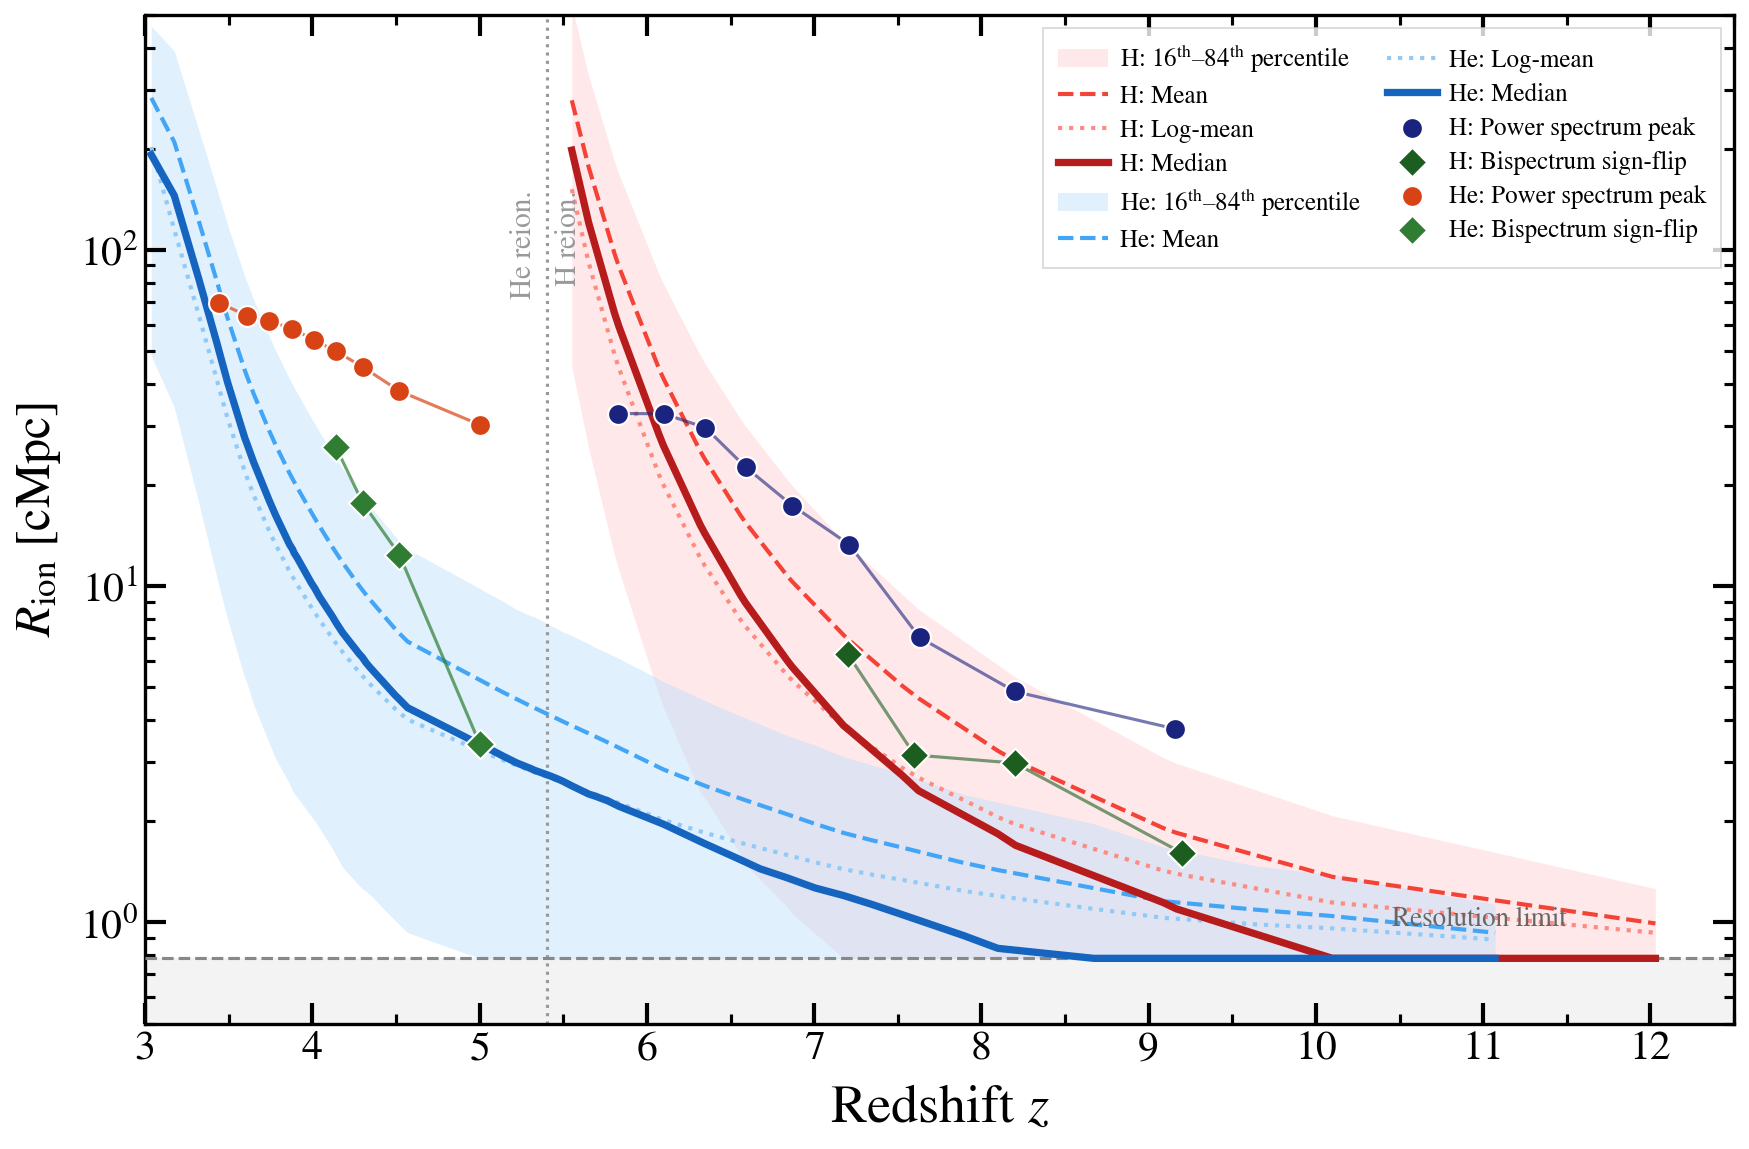

In [10]:
import os
import glob
import h5py
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import LogLocator, NullFormatter

# =====================================================
# rcParams
# =====================================================
matplotlib.rcParams.update({
    "font.family":        "STIXGeneral",
    "mathtext.fontset":   "stix",
    "font.size":          18,
    "axes.linewidth":     1.6,
    "axes.labelsize":     24,
    "xtick.major.size":   10,
    "xtick.minor.size":   5,
    "xtick.major.width":  2.0,
    "xtick.minor.width":  1.5,
    "xtick.direction":    "in",
    "xtick.top":          True,
    "xtick.labelsize":    20,
    "ytick.major.size":   10,
    "ytick.minor.size":   5,
    "ytick.major.width":  2.0,
    "ytick.minor.width":  1.5,
    "ytick.direction":    "in",
    "ytick.right":        True,
    "ytick.labelsize":    20,
    "legend.fontsize":    14,
    "legend.frameon":     False,
    "legend.handlelength":2.0,
    "lines.linewidth":    2.5,
    "figure.dpi":         150,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
})

N_RESOLVED_BINS = 1000000
R_GLOBAL_MIN    = 0.1
R_GLOBAL_MAX    = 1000.0

def rebin_by_overlap(edges_src, counts_src, edges_dst):
    out = np.zeros(len(edges_dst) - 1)
    for j in range(len(counts_src)):
        count = counts_src[j]
        if count == 0: continue
        lo, hi = edges_src[j], edges_src[j + 1]
        width  = hi - lo
        if width <= 0: continue
        i_lo = max(np.searchsorted(edges_dst, lo, side="right") - 1, 0)
        i_hi = min(np.searchsorted(edges_dst, hi, side="left"), len(out) - 1)
        for k in range(i_lo, i_hi + 1):
            overlap = min(hi, edges_dst[k + 1]) - max(lo, edges_dst[k])
            if overlap > 0:
                out[k] += count * overlap / width
    return out

# =====================================================
# 1. Hydrogen data
# =====================================================
DATA_DIR_H = "/orcd/data/mvogelsb/004/chcho/mfp-bubbles-thesan/output/LUMINA_hydrogen"
files_h = sorted(glob.glob(os.path.join(DATA_DIR_H, "mfp_*.hdf5")))

with h5py.File(files_h[0], "r") as f:
    boxsize     = float(f["Header"].attrs["BoxSize"])
    hubble      = float(f["Header"].attrs["HubbleParam"])
    box_cMpc    = boxsize / hubble / 1000.0
    Ngrid       = int(f["Header"].attrs["NumPixels"])
    cell_size_h = box_cMpc / Ngrid

R_min_h          = cell_size_h
resolved_edges_h = np.logspace(np.log10(R_min_h), np.log10(R_GLOBAL_MAX), N_RESOLVED_BINS + 1)
bin_edges_h      = np.concatenate([[R_GLOBAL_MIN], resolved_edges_h])
R_centers_h      = np.sqrt(bin_edges_h[:-1] * bin_edges_h[1:])
R_centers_h[0]   = R_min_h

z_all_h, mean_all_h, median_all_h, logmean_all_h, p16_all_h, p84_all_h = [], [], [], [], [], []
for fp in files_h:
    with h5py.File(fp, "r") as f:
        z               = float(f["Header"].attrs["Redshift"])
        hist            = f["mfp_hist"][:].astype(float)
        n_bins_native   = len(hist)
        n_bins_per_cell = int(f["Header"].attrs["NumBinsPerCell"])
    edges_native = np.arange(n_bins_native + 1) / n_bins_per_cell * cell_size_h
    hist_rebin   = rebin_by_overlap(edges_native, hist, bin_edges_h)
    total = hist_rebin.sum()
    if total == 0: continue
    P      = hist_rebin / total
    mask   = P > 0
    R_s    = R_centers_h[mask]
    P_s    = P[mask]
    cdf    = np.cumsum(P_s)
    z_all_h.append(z)
    mean_all_h.append(np.sum(P_s * R_s))
    logmean_all_h.append(10 ** np.sum(P_s * np.log10(R_s)))
    median_all_h.append(np.interp(0.50, cdf, R_s))
    p16_all_h.append(np.interp(0.16, cdf, R_s))
    p84_all_h.append(np.interp(0.84, cdf, R_s))

idx_h = np.argsort(z_all_h)
z_all_h, mean_all_h, median_all_h, logmean_all_h, p16_all_h, p84_all_h = [
    np.array(x)[idx_h] for x in
    [z_all_h, mean_all_h, median_all_h, logmean_all_h, p16_all_h, p84_all_h]
]

# Hydrogen external estimators
z_ps_h   = np.array([9.16, 8.20, 7.63, 7.21, 6.87, 6.59, 6.35, 6.10, 5.83])
R_ps_h   = np.array([2.544, 3.288, 4.763, 8.999, 11.747,
                      15.292, 20.024, 22.041, 22.073]) / hubble
z_bispec_h = np.array([9.2, 8.2, 7.6, 7.2])
R_bispec_h = np.array([1.08827, 2.01348, 2.12863, 4.25726]) / hubble

z_hsiao, R_hsiao = np.array([9.16]), np.array([2.234])

# Umeda et al. 2024 — mapped via redshift
snap_to_redshift_h_full = {
    112: 12.006999, 129: 11.205740, 140: 10.718889, 148: 10.363529,
    154: 10.081991, 160: 9.847533,  165: 9.645984,  169: 9.469432,
    173: 9.311993,  177: 9.170129,  203: 8.207879,  220: 7.624910,
    242: 7.204283,  264: 6.872631,  283: 6.592783,  300: 6.342011,
    318: 6.099902,  338: 5.826679,  341: 5.794754,  343: 5.761251,
    346: 5.725699,  349: 5.687586,  352: 5.645994,  356: 5.599397,
    360: 5.545151,  366: 5.477609,  374: 5.379672,
}
snap_to_fHII_full = {
    112: 0.01, 129: 0.02, 140: 0.03, 148: 0.04, 154: 0.05,
    160: 0.06, 165: 0.07, 169: 0.08, 173: 0.09, 177: 0.10,
    203: 0.20, 220: 0.30, 242: 0.40, 264: 0.50, 283: 0.60,
    300: 0.70, 318: 0.80, 338: 0.90, 341: 0.91, 343: 0.92,
    346: 0.93, 349: 0.94, 352: 0.95, 356: 0.96, 360: 0.97,
    366: 0.98, 374: 0.99,
}
_snaps_h   = np.array(sorted(snap_to_redshift_h_full.keys()))
_z_tab_h   = np.array([snap_to_redshift_h_full[s] for s in _snaps_h])
_f_tab_h   = np.array([snap_to_fHII_full[s]        for s in _snaps_h])
_idx       = np.argsort(_z_tab_h)
_z_tab_h   = _z_tab_h[_idx]
_f_tab_h   = _f_tab_h[_idx]
def z_to_xHII(z): return np.interp(z, _z_tab_h, _f_tab_h)

xHI_umeda     = np.array([0.53, 0.65, 0.91, 0.92])
xHI_err_low   = np.array([0.47, 0.34, 0.22, 0.10])
xHI_err_high  = np.array([0.18, 0.27, 0.09, 0.08])
logRb         = np.array([1.67, 1.53, 0.70, -0.69])
logRb_err_low = np.array([0.16, 1.48, 1.04,  0.24])
logRb_err_hi  = np.array([0.14, 0.34, 0.47,  0.89])
Rb_umeda      = 10**logRb
Rb_low        = Rb_umeda - 10**(logRb - logRb_err_low)
Rb_high       = 10**(logRb + logRb_err_hi) - Rb_umeda
# Convert x_HI → redshift for plotting on z-axis
# x_HII = 1 - x_HI; invert z_to_xHII via the table
z_umeda = np.interp(1.0 - xHI_umeda, _f_tab_h[::-1], _z_tab_h[::-1])
z_umeda_zlo = np.interp(1.0 - (xHI_umeda - xHI_err_low),  _f_tab_h[::-1], _z_tab_h[::-1])
z_umeda_zhi = np.interp(1.0 - (xHI_umeda + xHI_err_high), _f_tab_h[::-1], _z_tab_h[::-1])
#zerr_lo = z_umeda - z_umeda_zhi   # toward lower z (higher ionization)
#zerr_hi = z_umeda_zlo - z_umeda   # toward higher z (less ionization)
zerr_lo = np.abs(z_umeda - z_umeda_zhi)   # toward lower z
zerr_hi = np.abs(z_umeda_zlo - z_umeda)   # toward higher z


xi_furlanetto = np.array([0.1992,0.2109,0.2226,0.2385,0.2503,0.2687,0.2804,0.2921,0.3089,0.3206,0.3324,0.3499,0.3617,0.3726,0.3910,0.4027,0.4145,0.4329,0.4438,0.4555,0.4739,0.4857,0.4974,0.5150,0.5267,0.5384,0.5569,0.5686,0.5795,0.5987,0.6105,0.6222,0.6398,0.6515,0.6632,0.6817,0.6934,0.7043,0.7227,0.7345,0.7462,0.7646,0.7755,0.7872,0.8057,0.8174,0.8291,0.8459,0.8576,0.8693,0.8877,0.8995,0.9104,0.9221,0.9338,0.9455,0.9573,0.9682,0.9799,0.9900])
R_furlanetto  = np.array([0.3400,0.3830,0.4330,0.5102,0.5715,0.6636,0.7469,0.8229,0.9382,1.0277,1.1279,1.2792,1.3868,1.4958,1.6944,1.8320,1.9750,2.2242,2.3746,2.5527,2.8536,3.0616,3.2919,3.6405,3.9111,4.1886,4.6573,4.9884,5.3024,5.9213,6.3318,6.7762,7.4903,8.0340,8.5978,9.5410,10.2468,10.9140,12.1634,13.1065,14.0946,15.8179,16.9384,18.2749,20.7074,22.5165,24.4675,27.7386,30.4569,33.5082,39.5524,44.0926,49.8666,56.4022,65.7361,71.1672,96.6880,117.2752,167.3574,290.0000])
z_furlanetto  = np.interp(1.0 - xi_furlanetto, _f_tab_h[::-1], _z_tab_h[::-1])

# =====================================================
# 2. Helium data
# =====================================================
DATA_DIR_HE = "/orcd/data/mvogelsb/004/chcho/mfp-bubbles-thesan/output/LUMINA_helium"
files_he = sorted(glob.glob(os.path.join(DATA_DIR_HE, "mfp_*.hdf5")))

with h5py.File(files_he[0], "r") as f:
    cell_size_he = (float(f["Header"].attrs["BoxSize"]) / hubble / 1000.0) / \
                   int(f["Header"].attrs["NumPixels"])

R_min_he          = cell_size_he
resolved_edges_he = np.logspace(np.log10(R_min_he), np.log10(R_GLOBAL_MAX), N_RESOLVED_BINS + 1)
bin_edges_he      = np.concatenate([[R_GLOBAL_MIN], resolved_edges_he])
R_centers_he      = np.sqrt(bin_edges_he[:-1] * bin_edges_he[1:])
R_centers_he[0]   = R_min_he

z_all_he, mean_all_he, median_all_he, logmean_all_he, p16_all_he, p84_all_he = [], [], [], [], [], []
for fp in files_he:
    with h5py.File(fp, "r") as f:
        z               = float(f["Header"].attrs["Redshift"])
        hist            = f["mfp_hist"][:].astype(float)
        n_bins_per_cell = int(f["Header"].attrs["NumBinsPerCell"])
    hist_rebin = rebin_by_overlap(
        np.arange(len(hist) + 1) / n_bins_per_cell * cell_size_he,
        hist, bin_edges_he
    )
    total = hist_rebin.sum()
    if total == 0: continue
    P   = hist_rebin / total
    mask = P > 0
    R_s  = R_centers_he[mask]
    P_s  = P[mask]
    cdf  = np.cumsum(P_s)
    z_all_he.append(z)
    mean_all_he.append(np.sum(P_s * R_s))
    logmean_all_he.append(10 ** np.sum(P_s * np.log10(R_s)))
    median_all_he.append(np.interp(0.50, cdf, R_s))
    p16_all_he.append(np.interp(0.16, cdf, R_s))
    p84_all_he.append(np.interp(0.84, cdf, R_s))

idx_he = np.argsort(z_all_he)
z_all_he, mean_all_he, median_all_he, logmean_all_he, p16_all_he, p84_all_he = [
    np.array(x)[idx_he] for x in
    [z_all_he, mean_all_he, median_all_he, logmean_all_he, p16_all_he, p84_all_he]
]

# Helium external estimators
z_ps_he    = np.array([5.00, 4.52, 4.30, 4.14, 4.01, 3.88, 3.74, 3.61, 3.44])
R_ps_he    = np.array([20.452, 25.749, 30.390, 33.819, 36.550,
                        39.431, 41.624, 43.081, 47.186]) / hubble
z_bispec_he = np.array([5.00, 4.52, 4.30, 4.14])
R_bispec_he = np.array([2.30112, 8.39200, 11.9886, 17.5531]) / hubble

# =====================================================
# 3. Single combined figure: R_ion vs redshift z
# =====================================================

# Color palette — hydrogen red, helium blue, shared estimator colors
C_FILL_H    = "#FFCDD2";  C_MEDIAN_H  = "#B71C1C"
C_MEAN_H    = "#F44336";  C_LMEAN_H   = "#FF8A80"
C_FILL_HE   = "#BBDEFB";  C_MEDIAN_HE = "#1565C0"
C_MEAN_HE   = "#42A5F5";  C_LMEAN_HE  = "#90CAF9"
C_PS_H      = "#1A237E"   # dark indigo  — H PS peak
C_BIS_H     = "#1B5E20"   # dark green   — H bispectrum
C_PS_HE     = "#D84315"   # burnt orange — He PS peak
C_BIS_HE    = "#2E7D32"   # forest green — He bispectrum
C_HSIAO     = "#6A1B9A"   # deep purple
C_UMEDA     = "#00838F"   # teal
C_FURL      = "royalblue"

fig, ax = plt.subplots(figsize=(12, 8))

# ---- Hydrogen simulation band & statistics ----
ax.fill_between(z_all_h, p16_all_h, p84_all_h,
                color=C_FILL_H, alpha=0.45, lw=0,
                label=r"H: $16^{\rm th}$–$84^{\rm th}$ percentile")
ax.plot(z_all_h, mean_all_h,    color=C_MEAN_H,  lw=2.0, ls="--", zorder=3,
        label=r"H: Mean")
ax.plot(z_all_h, logmean_all_h, color=C_LMEAN_H, lw=2.0, ls=":",  zorder=3,
        label=r"H: Log-mean")
ax.plot(z_all_h, median_all_h,  color=C_MEDIAN_H,lw=3.5, ls="-",  zorder=4,
        label=r"H: Median")

# ---- Helium simulation band & statistics ----
ax.fill_between(z_all_he, p16_all_he, p84_all_he,
                color=C_FILL_HE, alpha=0.45, lw=0,
                label=r"He: $16^{\rm th}$–$84^{\rm th}$ percentile")
ax.plot(z_all_he, mean_all_he,    color=C_MEAN_HE,  lw=2.0, ls="--", zorder=3,
        label=r"He: Mean")
ax.plot(z_all_he, logmean_all_he, color=C_LMEAN_HE, lw=2.0, ls=":",  zorder=3,
        label=r"He: Log-mean")
ax.plot(z_all_he, median_all_he,  color=C_MEDIAN_HE,lw=3.5, ls="-",  zorder=4,
        label=r"He: Median")

# ---- Hydrogen external estimators ----

ax.plot(z_ps_h, R_ps_h, color=C_PS_H, lw=1.5, ls="-", alpha=0.6, zorder=5)
ax.scatter(z_ps_h, R_ps_h, s=100, color=C_PS_H, marker="o", zorder=6,
           edgecolors="white", linewidths=1.0,
           label=r"H: Power spectrum peak")

ax.plot(z_bispec_h, R_bispec_h, color=C_BIS_H, lw=1.5, ls="-", alpha=0.6, zorder=5)
ax.scatter(z_bispec_h, R_bispec_h, s=100, color=C_BIS_H, marker="D", zorder=6,
           edgecolors="white", linewidths=1.0,
           label=r"H: Bispectrum sign-flip")
"""
ax.scatter(z_hsiao, R_hsiao, s=110, color="none", marker="s", zorder=7,
           edgecolors=C_HSIAO, linewidths=2.0,
           label=r"Hsiao et al. 2023")
# Hsiao upper-limit arrows
ax.annotate("", xy=(12.0, R_hsiao[0]), xytext=(z_hsiao[0], R_hsiao[0]),
            arrowprops=dict(arrowstyle="->", color=C_HSIAO, lw=2.0,
                            shrinkA=0, shrinkB=0), zorder=7)
ax.annotate("", xy=(z_hsiao[0], 0.06), xytext=(z_hsiao[0], R_hsiao[0]),
            arrowprops=dict(arrowstyle="->", color=C_HSIAO, lw=2.0,
                            shrinkA=0, shrinkB=0), zorder=7)

ax.errorbar(z_umeda, Rb_umeda,
            xerr=[zerr_lo, zerr_hi], yerr=[Rb_low, Rb_high],
            fmt="s", ms=10, mfc="none", mec=C_UMEDA, mew=2.0,
            ecolor=C_UMEDA, elinewidth=2.0, capsize=4,
            linestyle="none", zorder=7,
            label=r"Umeda et al. 2024")

#ax.plot(z_furlanetto, R_furlanetto, color=C_FURL, lw=2.0, ls=":", zorder=6,
#        label=r"Furlanetto \& Oh 2005")
"""
# ---- Helium external estimators ----
ax.plot(z_ps_he, R_ps_he, color=C_PS_HE, lw=1.5, ls="-", alpha=0.7, zorder=5)
ax.scatter(z_ps_he, R_ps_he, s=100, color=C_PS_HE, marker="o", zorder=6,
           edgecolors="white", linewidths=1.0,
           label=r"He: Power spectrum peak")

ax.plot(z_bispec_he, R_bispec_he, color=C_BIS_HE, lw=1.5, ls="-", alpha=0.7, zorder=5)
ax.scatter(z_bispec_he, R_bispec_he, s=100, color=C_BIS_HE, marker="D", zorder=6,
           edgecolors="white", linewidths=1.0,
           label=r"He: Bispectrum sign-flip")

# ---- Vertical divider between H and He epochs ----
ax.axvline(5.4, color="#999999", ls=":", lw=1.5, zorder=2)
ax.text(5.45, 150, "H reion.", color="#999999", fontsize=14,
        ha="left", va="top", rotation=90)
ax.text(5.35, 150, "He reion.", color="#999999", fontsize=14,
        ha="right", va="top", rotation=90)

# ---- Resolution limit (hydrogen) ----
ax.set_ylim(0.5, 500.0)
R_res_h = cell_size_h
ax.axhspan(0.05, R_res_h, color="#dddddd", alpha=0.35, zorder=0, lw=0)
ax.axhline(R_res_h, color="#888888", ls="--", lw=1.5, zorder=3)
ax.text(11.5, R_res_h * 1.2, "Resolution limit",
        color="#666666", fontsize=13, ha="right", va="bottom")

# ---- Axes ----
ax.set_xlabel(r"Redshift $z$", fontsize=26, labelpad=8)
ax.set_ylabel(r"$R_{\rm ion}\ [\mathrm{cMpc}]$", fontsize=24, labelpad=8)
ax.set_yscale("log")
ax.set_xlim(12.5, 3.0)
ax.invert_xaxis()   # high z on left, low z on right — conventional direction

ax.xaxis.set_major_locator(ticker.MultipleLocator(1.0))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))
ax.yaxis.set_major_locator(LogLocator(base=10, numticks=8))
ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2,10)*0.1, numticks=40))
ax.yaxis.set_minor_formatter(NullFormatter())
ax.tick_params(which="major", direction="in", length=10, width=2.0, labelsize=20)
ax.tick_params(which="minor", direction="in", length=5,  width=1.5)

# ---- Two-column legend ----
leg = ax.legend(
    loc="upper right",
    ncol=2,
    fontsize=12,
    handlelength=2.0,
    handletextpad=0.5,
    borderpad=0.6,
    labelspacing=0.4,
    columnspacing=1.0,
    frameon=True,
    facecolor="white",
    edgecolor="#cccccc",
    fancybox=False,
)
leg.get_frame().set_linewidth(0.8)

plt.tight_layout()
#plt.savefig("BSD_combined_redshift.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Testing Umeda


Object 1
z   = 7.12 +0.06 -0.08
xHI = 0.53 +0.18 -0.47
Rb  = 46.77 cMpc +17.79 -14.41

Object 2
z   = 7.44 +0.34 -0.24
xHI = 0.65 +0.27 -0.34
Rb  = 33.88 cMpc +40.25 -32.76

Object 3
z   = 8.28 +0.41 -0.44
xHI = 0.91 +0.09 -0.22
Rb  = 5.01 cMpc +9.78 -4.55

Object 4
z   = 9.91 +1.49 -1.15
xHI = 0.92 +0.08 -0.10
Rb  = 0.20 cMpc +1.38 -0.09


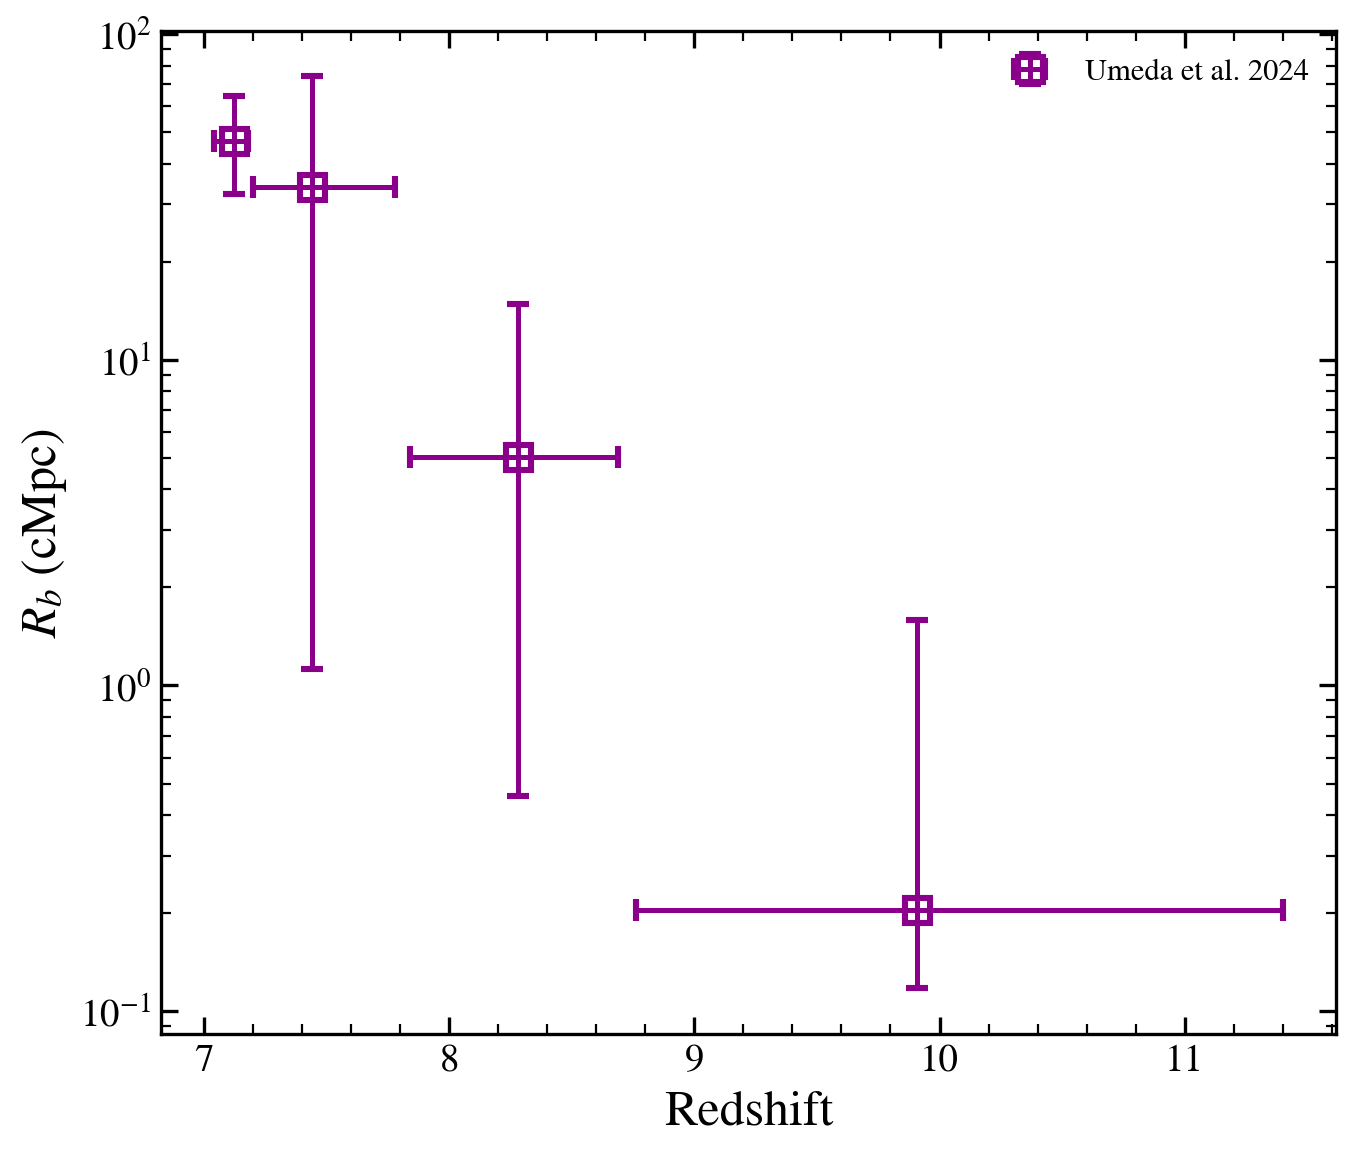

In [57]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# Data: Umeda et al. 2024 (Table 4)
# =====================================================

# Redshift (z)
z_umeda    = np.array([7.12, 7.44, 8.28, 9.91])
z_err_low  = np.array([0.08, 0.24, 0.44, 1.15])
z_err_high = np.array([0.06, 0.34, 0.41, 1.49])

# Neutral fraction (xHI)
xHI_umeda    = np.array([0.53, 0.65, 0.91, 0.92])
xHI_err_low  = np.array([0.47, 0.34, 0.22, 0.10])
xHI_err_high = np.array([0.18, 0.27, 0.09, 0.08])

# Bubble size: log10(R_b / cMpc)
logRb          = np.array([1.67, 1.53, 0.70, -0.69])
logRb_err_low  = np.array([0.16, 1.48, 1.04,  0.24])
logRb_err_high = np.array([0.14, 0.34, 0.47,  0.89])

# =====================================================
# Conversions
# =====================================================

# Convert log values to linear bubble size (cMpc)
Rb_umeda = 10**logRb

# Calculate asymmetric linear errors for the plot
Rb_low  = Rb_umeda - 10**(logRb - logRb_err_low)
Rb_high = 10**(logRb + logRb_err_high) - Rb_umeda

# =====================================================
# Console Output
# =====================================================

for i in range(len(z_umeda)):
    print(f"\nObject {i+1}")
    print(f"z   = {z_umeda[i]:.2f} +{z_err_high[i]:.2f} -{z_err_low[i]:.2f}")
    print(f"xHI = {xHI_umeda[i]:.2f} +{xHI_err_high[i]:.2f} -{xHI_err_low[i]:.2f}")
    print(f"Rb  = {Rb_umeda[i]:.2f} cMpc +{Rb_high[i]:.2f} -{Rb_low[i]:.2f}")

# =====================================================
# Plotting
# =====================================================

fig, ax = plt.subplots(figsize=(7, 6))

ax.errorbar(
    x=z_umeda, 
    y=Rb_umeda,
    xerr=[z_err_low, z_err_high],
    yerr=[Rb_low, Rb_high],
    fmt="s", ms=9, mfc="none", mec="darkmagenta", mew=2.2,    # Marker styling
    ecolor="darkmagenta", elinewidth=1.8, capsize=4,          # Error bar styling
    linestyle="none", label="Umeda et al. 2024"
)

# Axis formatting
ax.set_yscale("log")
ax.set_xlabel("Redshift")
ax.set_ylabel(r"$R_b\ ({\rm cMpc})$")

# Tick marks and legend
ax.tick_params(which="both", direction="in", top=True, right=True)
ax.minorticks_on()
ax.legend(frameon=False)

plt.tight_layout()
plt.show()


Object 1
z   = 7.12 +0.06 -0.08
xHI = 0.53 +0.18 -0.47
Rb  = 46.77 cMpc +17.79 -14.41

Object 2
z   = 7.44 +0.34 -0.24
xHI = 0.65 +0.27 -0.34
Rb  = 33.88 cMpc +40.25 -32.76

Object 3
z   = 8.28 +0.41 -0.44
xHI = 0.91 +0.09 -0.22
Rb  = 5.01 cMpc +9.78 -4.55

Object 4
z   = 9.91 +1.49 -1.15
xHI = 0.92 +0.08 -0.10
Rb  = 0.20 cMpc +1.38 -0.09


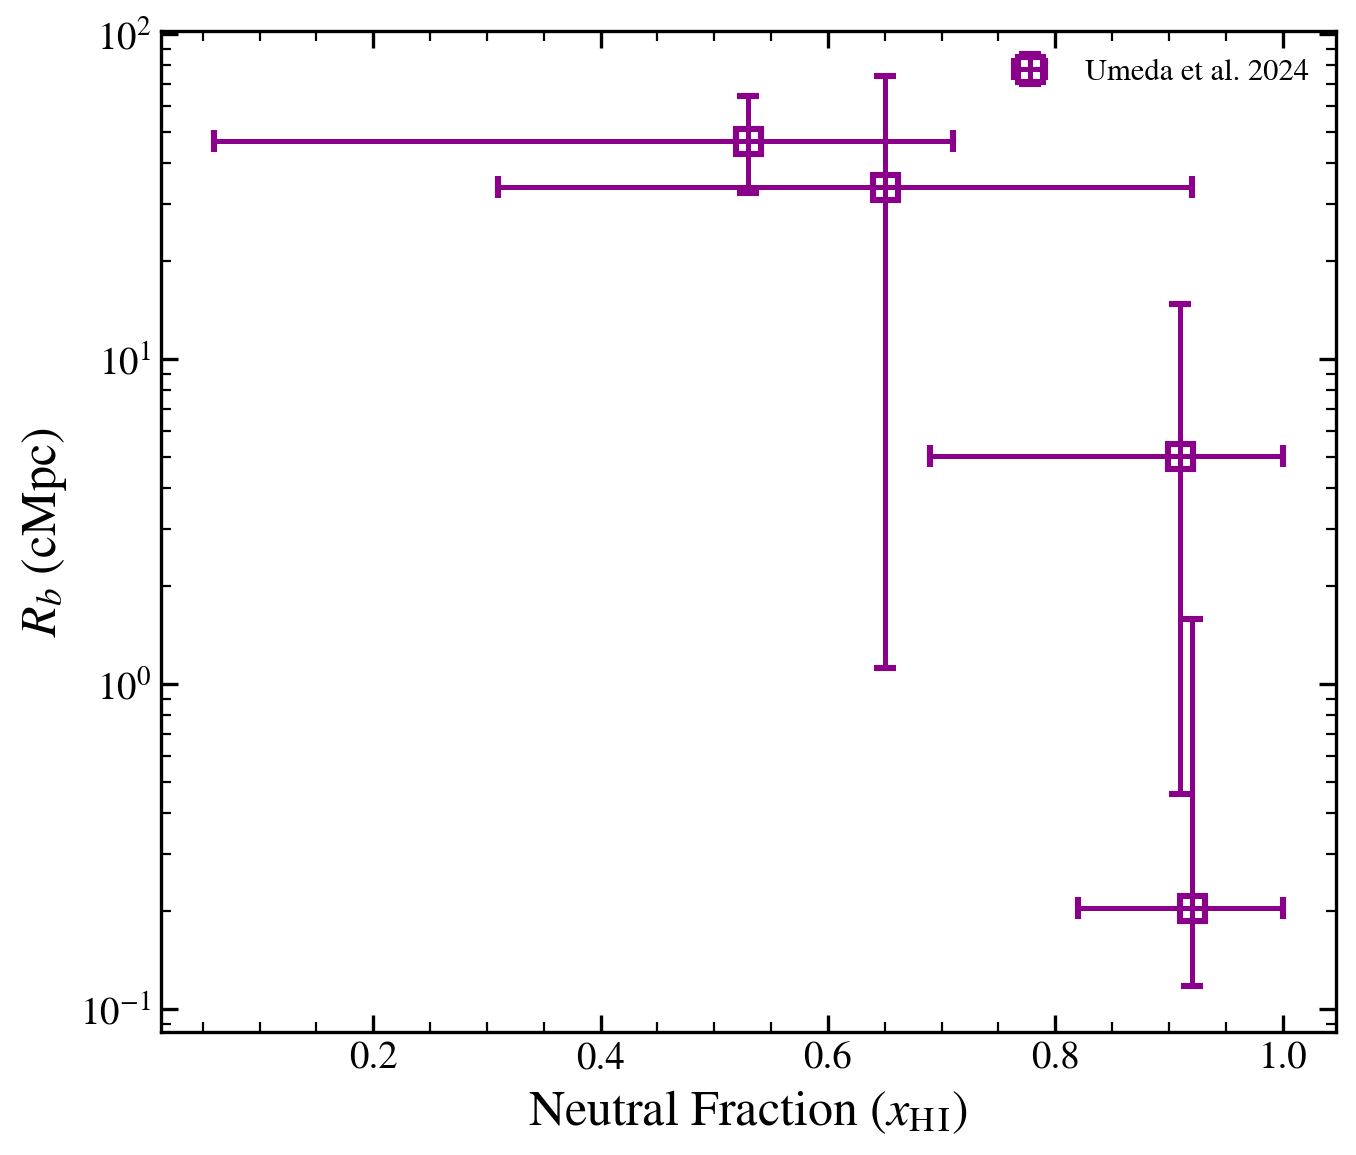

In [59]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# Data: Umeda et al. 2024 (Table 4)
# =====================================================

# Redshift (z)
z_umeda    = np.array([7.12, 7.44, 8.28, 9.91])
z_err_low  = np.array([0.08, 0.24, 0.44, 1.15])
z_err_high = np.array([0.06, 0.34, 0.41, 1.49])

# Neutral fraction (xHI)
xHI_umeda    = np.array([0.53, 0.65, 0.91, 0.92])
xHI_err_low  = np.array([0.47, 0.34, 0.22, 0.10])
xHI_err_high = np.array([0.18, 0.27, 0.09, 0.08])

# Bubble size: log10(R_b / cMpc)
logRb          = np.array([1.67, 1.53, 0.70, -0.69])
logRb_err_low  = np.array([0.16, 1.48, 1.04,  0.24])
logRb_err_high = np.array([0.14, 0.34, 0.47,  0.89])

# =====================================================
# Conversions
# =====================================================

# Convert log values to linear bubble size (cMpc)
Rb_umeda = 10**logRb

# Calculate asymmetric linear errors for the plot
Rb_low  = Rb_umeda - 10**(logRb - logRb_err_low)
Rb_high = 10**(logRb + logRb_err_high) - Rb_umeda

# =====================================================
# Console Output
# =====================================================

for i in range(len(z_umeda)):
    print(f"\nObject {i+1}")
    print(f"z   = {z_umeda[i]:.2f} +{z_err_high[i]:.2f} -{z_err_low[i]:.2f}")
    print(f"xHI = {xHI_umeda[i]:.2f} +{xHI_err_high[i]:.2f} -{xHI_err_low[i]:.2f}")
    print(f"Rb  = {Rb_umeda[i]:.2f} cMpc +{Rb_high[i]:.2f} -{Rb_low[i]:.2f}")

# =====================================================
# Plotting
# =====================================================

fig, ax = plt.subplots(figsize=(7, 6))

ax.errorbar(
    x=xHI_umeda,              # Changed from z_umeda
    y=Rb_umeda,
    xerr=[xHI_err_low, xHI_err_high],  # Changed from z errors
    yerr=[Rb_low, Rb_high],
    fmt="s", ms=9, mfc="none", mec="darkmagenta", mew=2.2,    # Marker styling
    ecolor="darkmagenta", elinewidth=1.8, capsize=4,          # Error bar styling
    linestyle="none", label="Umeda et al. 2024"
)

# Axis formatting
ax.set_yscale("log")
ax.set_xlabel(r"Neutral Fraction ($x_{\rm H\,I}$)")  # Updated label
ax.set_ylabel(r"$R_b\ ({\rm cMpc})$")

# Tick marks and legend
ax.tick_params(which="both", direction="in", top=True, right=True)
ax.minorticks_on()
ax.legend(frameon=False)

# Optional: Invert x-axis if you want to show chronological evolution (xHI goes from 1 to 0)
# ax.invert_xaxis() 

plt.tight_layout()
plt.show()

## Hydrogen (Umeda redshift)

BoxSize=500.000 cMpc  Ngrid=640  cell=0.78125 cMpc  h=0.67660
  z=12.03  unresolved=67.326% *** HIGH ***
  z=10.10  unresolved=51.624% *** HIGH ***
  z=9.16  unresolved=41.777% *** HIGH ***
  z=9.09  unresolved=40.895% *** HIGH ***
  z=8.20  unresolved=30.312% *** HIGH ***
  z=8.10  unresolved=28.998% *** HIGH ***
  z=7.63  unresolved=22.968% *** HIGH ***
  z=7.53  unresolved=21.706% *** HIGH ***
  z=7.21  unresolved=17.590% *** HIGH ***
  z=7.18  unresolved=17.187% *** HIGH ***
  z=6.87  unresolved=13.282% *** HIGH ***
  z=6.84  unresolved=12.906% *** HIGH ***
  z=6.59  unresolved=9.827% *** HIGH ***
  z=6.56  unresolved=9.482% *** HIGH ***
  z=6.35  unresolved=7.013% *** HIGH ***
  z=6.32  unresolved=6.703% *** HIGH ***
  z=6.10  unresolved=4.409%
  z=6.07  unresolved=4.150%
  z=5.83  unresolved=2.181%
  z=5.81  unresolved=2.003%
  z=5.65  unresolved=1.105%


/tmp/ipykernel_646762/1884686686.py:201: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


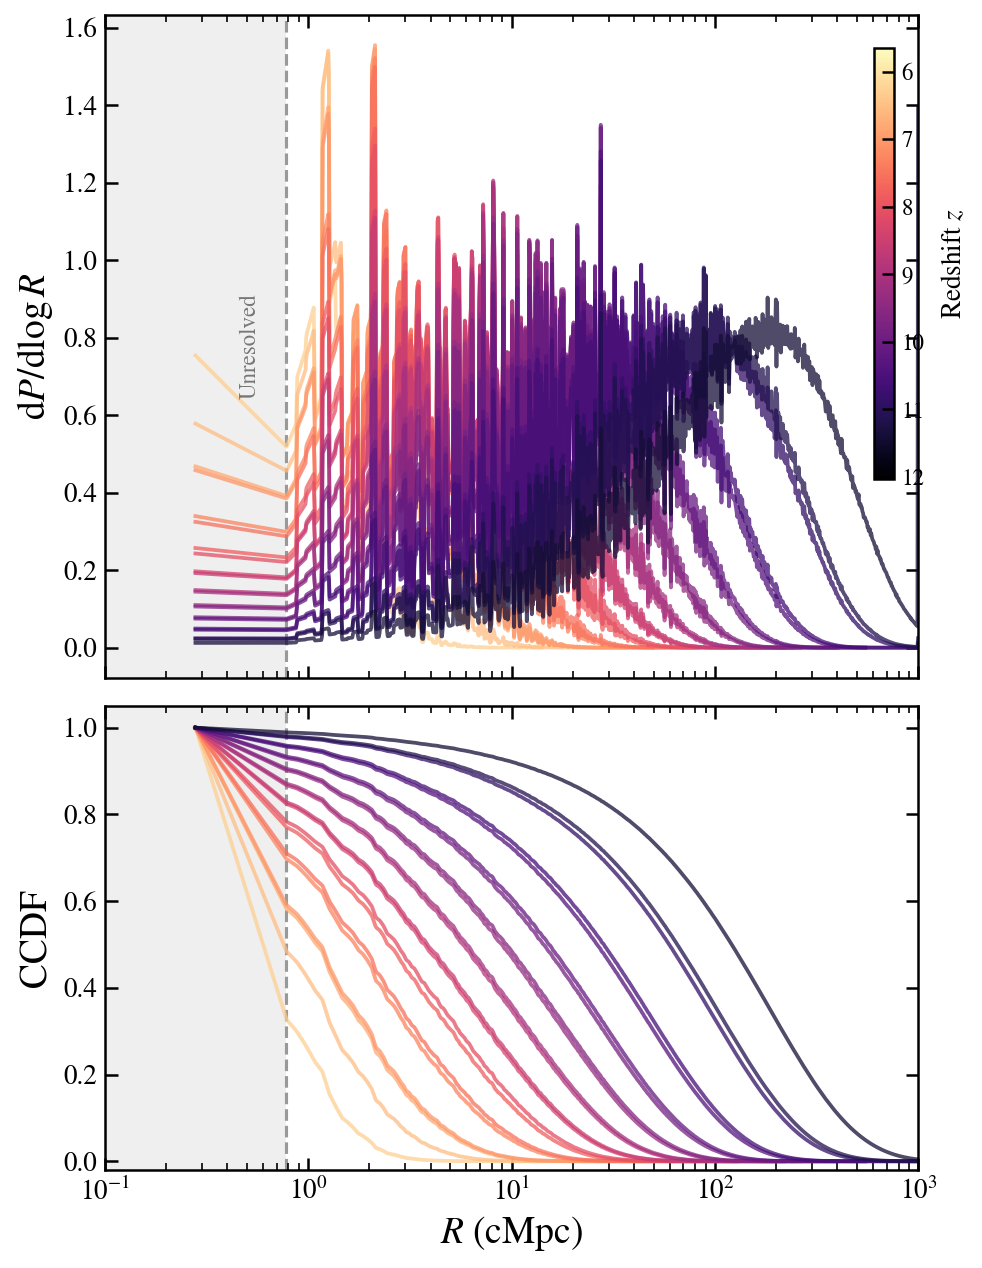

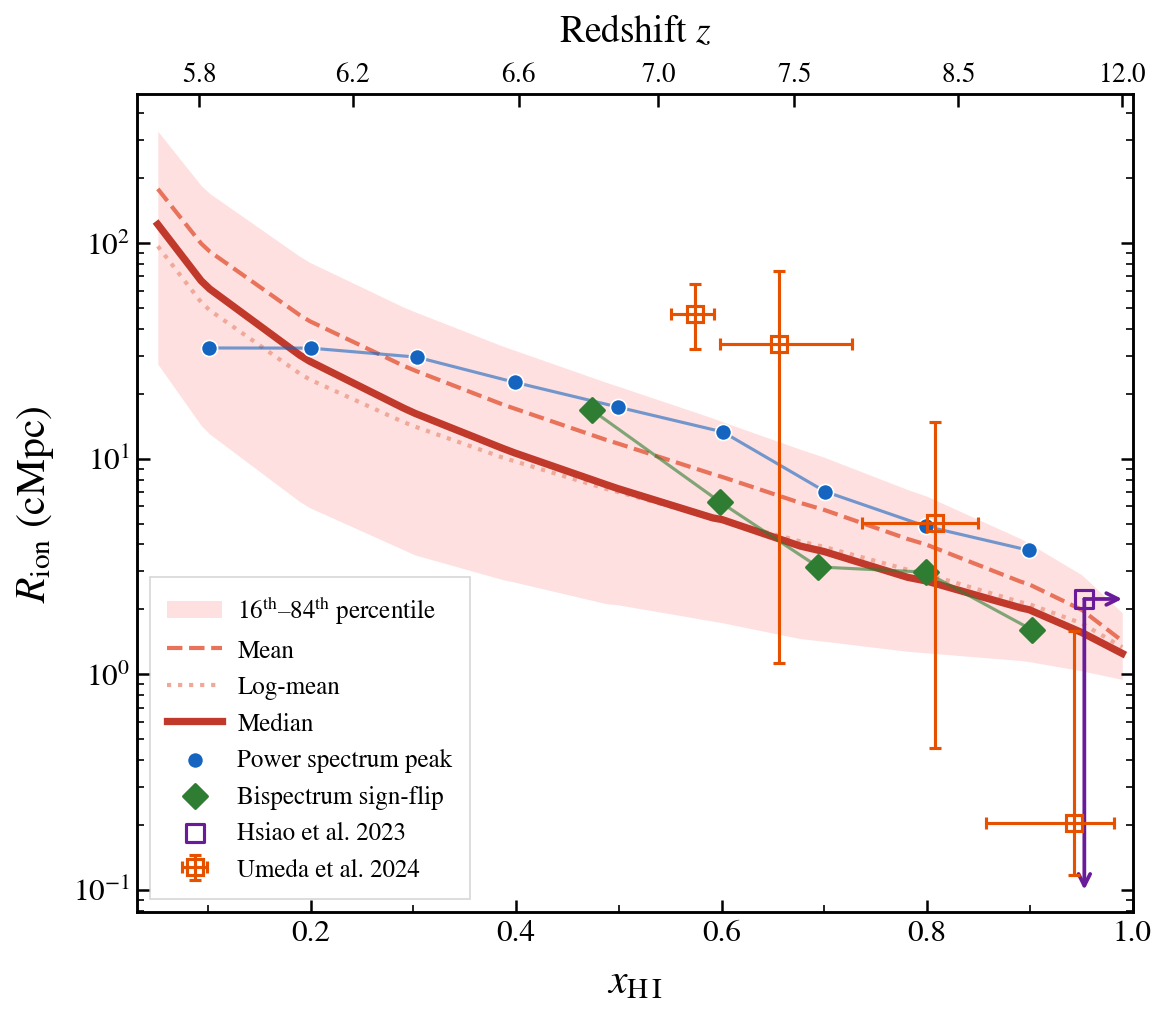

In [ ]:
import os
import glob
import h5py
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import LogLocator, NullFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# =====================================================
# rcParams  (matches helium figure style exactly)
# =====================================================

matplotlib.rcParams.update({
    "font.family":        "STIXGeneral",
    "mathtext.fontset":   "stix",
    "font.size":          14,
    "axes.linewidth":     1.2,
    "axes.labelsize":     18,
    "axes.titlesize":     16,
    "xtick.major.size":   6,
    "xtick.minor.size":   3.5,
    "xtick.major.width":  1.2,
    "xtick.minor.width":  0.8,
    "xtick.direction":    "in",
    "xtick.top":          True,
    "xtick.labelsize":    13,
    "ytick.major.size":   6,
    "ytick.minor.size":   3.5,
    "ytick.major.width":  1.2,
    "ytick.minor.width":  0.8,
    "ytick.direction":    "in",
    "ytick.right":        True,
    "ytick.labelsize":    13,
    "legend.fontsize":    12,
    "legend.frameon":     False,
    "legend.handlelength":1.8,
    "lines.linewidth":    2.0,
    "figure.dpi":         150,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
})

# =====================================================
# Directory & binning
# =====================================================

DATA_DIR        = "/orcd/data/mvogelsb/004/chcho/mfp-bubbles-thesan/output/LUMINA_hydrogen"
N_RESOLVED_BINS = 1000
R_GLOBAL_MIN    = 0.1
R_GLOBAL_MAX    = 1000.0

files = sorted(glob.glob(os.path.join(DATA_DIR, "mfp_*.hdf5")))
if len(files) == 0:
    raise RuntimeError(f"No mfp_*.hdf5 files found in {DATA_DIR}")

with h5py.File(files[0], "r") as f:
    boxsize   = float(f["Header"].attrs["BoxSize"])
    hubble    = float(f["Header"].attrs["HubbleParam"])
    box_cMpc  = boxsize / hubble / 1000.0
    Ngrid     = int(f["Header"].attrs["NumPixels"])
    cell_size = box_cMpc / Ngrid

assert 0.6 < hubble < 0.8, f"Unexpected HubbleParam={hubble:.4f}"
print(f"BoxSize={box_cMpc:.3f} cMpc  Ngrid={Ngrid}  cell={cell_size:.5f} cMpc  h={hubble:.5f}")

R_min          = cell_size
resolved_edges = np.logspace(np.log10(R_min), np.log10(R_GLOBAL_MAX), N_RESOLVED_BINS + 1)
bin_edges      = np.concatenate([[R_GLOBAL_MIN], resolved_edges])
R_centers      = np.sqrt(bin_edges[:-1] * bin_edges[1:])
R_centers[0]   = np.sqrt(R_GLOBAL_MIN * R_min)
dlogR          = np.diff(np.log10(bin_edges))

# =====================================================
# Overlap-weighted rebinning
# =====================================================

def rebin_by_overlap(edges_src, counts_src, edges_dst):
    out = np.zeros(len(edges_dst) - 1)
    for j in range(len(counts_src)):
        count = counts_src[j]
        if count == 0:
            continue
        lo, hi = edges_src[j], edges_src[j + 1]
        width  = hi - lo
        if width <= 0:
            continue
        i_lo = max(np.searchsorted(edges_dst, lo, side="right") - 1, 0)
        i_hi = min(np.searchsorted(edges_dst, hi, side="left"), len(out) - 1)
        for k in range(i_lo, i_hi + 1):
            overlap = min(hi, edges_dst[k + 1]) - max(lo, edges_dst[k])
            if overlap > 0:
                out[k] += count * overlap / width
    return out

# =====================================================
# Storage
# =====================================================

z_all          = []
mean_all       = []
median_all     = []
logmean_all    = []
p16_all        = []
p84_all        = []
unresolved_all = []

# =====================================================
# Figure 1: BSD + CCDF
# =====================================================

fig_bsd, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(7, 10), sharex=True,
    gridspec_kw={"hspace": 0.05, "height_ratios": [1, 0.7]}
)

cmap   = matplotlib.colormaps["magma"].reversed()
colors = cmap(np.linspace(0.1, 0.9, len(files)))

for ax in [ax1, ax2]:
    ax.axvspan(R_GLOBAL_MIN, R_min, color="#e0e0e0", alpha=0.5, zorder=0, lw=0)
    ax.axvline(R_min, color="#999999", ls="--", lw=1.5, zorder=1)

for i, fp in enumerate(files):
    with h5py.File(fp, "r") as f:
        snap_Ngrid = int(f["Header"].attrs["NumPixels"])
        assert snap_Ngrid == Ngrid
        z               = float(f["Header"].attrs["Redshift"])
        hist            = f["mfp_hist"][:].astype(float)
        n_bins_native   = len(hist)
        n_bins_per_cell = int(f["Header"].attrs["NumBinsPerCell"])

    edges_native = np.arange(n_bins_native + 1) / n_bins_per_cell * cell_size
    hist_rebin   = rebin_by_overlap(edges_native, hist, bin_edges)

    total = hist_rebin.sum()
    if total == 0:
        print(f"  WARNING: all-zero at z={z:.2f}, skipping.")
        continue

    P       = hist_rebin / total
    dPdlogR = P / dlogR
    ccdf    = np.cumsum(P[::-1])[::-1]

    unresolved_frac = P[0]
    unresolved_all.append(unresolved_frac)
    flag = " *** HIGH ***" if unresolved_frac > 0.05 else ""
    print(f"  z={z:.2f}  unresolved={unresolved_frac:.3%}{flag}")

    mask_stat = (R_centers >= R_min) & (P > 0)
    R_stat    = R_centers[mask_stat]
    P_stat    = P[mask_stat] / P[mask_stat].sum()
    cdf       = np.cumsum(P_stat)

    z_all.append(z)
    mean_all.append(np.sum(P_stat * R_stat))
    logmean_all.append(10 ** np.sum(P_stat * np.log10(R_stat)))
    median_all.append(np.interp(0.50, cdf, R_stat))
    p16_all.append(np.interp(0.16, cdf, R_stat))
    p84_all.append(np.interp(0.84, cdf, R_stat))

    mask_plot = P > 0
    ax1.plot(R_centers[mask_plot], dPdlogR[mask_plot], lw=1.8, color=colors[i], alpha=0.75)
    ax2.plot(R_centers[mask_plot], ccdf[mask_plot],    lw=1.8, color=colors[i], alpha=0.75)

# Colorbar
sm = plt.cm.ScalarMappable(
    cmap=cmap,
    norm=matplotlib.colors.Normalize(vmin=min(z_all), vmax=max(z_all))
)
sm.set_array([])
cax = inset_axes(ax1, width="2.5%", height="65%", loc="upper right",
                 bbox_to_anchor=(-0.03, -0.05, 1, 1),
                 bbox_transform=ax1.transAxes, borderpad=0)
cb  = fig_bsd.colorbar(sm, cax=cax)
cb.set_label("Redshift $z$", fontsize=13, labelpad=8)
cb.ax.tick_params(labelsize=11, direction="in")
cb.ax.invert_yaxis()

ax1.set_ylabel(r"$\mathrm{d}P/\mathrm{d}\log R$")
ax2.set_ylabel(r"CCDF")
ax2.set_xlabel(r"$R\ (\mathrm{cMpc})$", fontsize=18)
ax1.set_xscale("log")
ax2.set_xscale("log")
ax1.set_xlim(R_GLOBAL_MIN, R_GLOBAL_MAX)
ax2.set_ylim(-0.02, 1.05)
ax2.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])

for ax in [ax1, ax2]:
    ax.xaxis.set_minor_locator(LogLocator(subs=np.arange(2, 10) * 0.1))
    ax.xaxis.set_minor_formatter(NullFormatter())

ax1.text(R_min * 0.75, 0.5, "Unresolved", rotation=90,
         va="center", ha="right", color="#777777", fontsize=11,
         transform=ax1.get_xaxis_transform())

plt.setp(ax1.get_xticklabels(), visible=False)
fig_bsd.align_ylabels([ax1, ax2])
plt.tight_layout()
plt.show()

# =====================================================
# Sort statistics
# =====================================================

z_all       = np.array(z_all)
mean_all    = np.array(mean_all)
median_all  = np.array(median_all)
logmean_all = np.array(logmean_all)
p16_all     = np.array(p16_all)
p84_all     = np.array(p84_all)

sort_idx    = np.argsort(z_all)
z_all       = z_all[sort_idx]
mean_all    = mean_all[sort_idx]
median_all  = median_all[sort_idx]
logmean_all = logmean_all[sort_idx]
p16_all     = p16_all[sort_idx]
p84_all     = p84_all[sort_idx]

# =====================================================
# Save CSV
# =====================================================

pd.DataFrame({
    "z": z_all, "mean_cMpc": mean_all, "median_cMpc": median_all,
    "logmean_cMpc": logmean_all, "p16_cMpc": p16_all, "p84_cMpc": p84_all,
}).to_csv("bubble_statistics_hydrogen.csv", index=False)

# =====================================================
# Reference estimators  (cMpc/h → cMpc)
# =====================================================

z_ps    = np.array([9.16, 8.20, 7.63, 7.21, 6.87, 6.59, 6.35, 6.10, 5.83])
R_ps    = np.array([2.544, 3.288, 4.763, 8.999, 11.747,
                    15.292, 20.024, 22.041, 22.073]) / hubble

z_bispec = np.array([9.2, 8.2, 7.6, 7.2, 6.8])
R_bispec = np.array([1.08827, 2.01348, 2.12863, 4.25726, 11.3571]) / hubble

z_hsiao = np.array([10.17])
R_hsiao = np.array([2.234])          # already cMpc; check if needs /hubble

# =====================================================
# Umeda et al. 2024 (Table 4)
# =====================================================
z_umeda = np.array([7.12, 7.44, 8.28, 9.91])
z_err_low = np.array([0.08, 0.24, 0.44, 1.15])
z_err_high = np.array([0.06, 0.34, 0.41, 1.49])

logRb = np.array([1.67, 1.53, 0.70, -0.69])
logRb_err_low = np.array([0.16, 1.48, 1.04, 0.24])
logRb_err_high = np.array([0.14, 0.34, 0.47, 0.89])

# Convert log(Rb) to linear Rb distances for error bars
Rb_umeda = 10**logRb
Rb_low  = Rb_umeda - 10**(logRb - logRb_err_low)
Rb_high = 10**(logRb + logRb_err_high) - Rb_umeda

# Map redshift (and its errors) to the plot's native x_HI coordinates
# This forces the points to be placed according to their Redshift (aligning with the top axis)
x_pos_umeda      = 1.0 - z_to_xHII(z_umeda)
x_pos_umeda_low  = 1.0 - z_to_xHII(z_umeda - z_err_low)
x_pos_umeda_high = 1.0 - z_to_xHII(z_umeda + z_err_high)

# Calculate horizontal error bar distances in the native x_HI space
# (Because higher z means higher x_HI in this simulation mapping)
xerr_low_plot  = x_pos_umeda - x_pos_umeda_low
xerr_high_plot = x_pos_umeda_high - x_pos_umeda

# =====================================================
# Snap lookup tables: redshift ↔ x_HII
# =====================================================

snap_to_fHII = {
    112: 0.01, 129: 0.02, 140: 0.03, 148: 0.04, 154: 0.05,
    160: 0.06, 165: 0.07, 169: 0.08, 173: 0.09, 177: 0.10,
    203: 0.20, 220: 0.30, 242: 0.40, 264: 0.50, 283: 0.60,
    300: 0.70, 318: 0.80, 338: 0.90, 341: 0.91, 343: 0.92,
    346: 0.93, 349: 0.94, 352: 0.95, 356: 0.96, 360: 0.97,
    366: 0.98, 374: 0.99,
}

snap_to_redshift = {
    112: 12.006999, 129: 11.205740, 140: 10.718889, 148: 10.363529,
    154: 10.081991, 160:  9.847533, 165:  9.645984, 169:  9.469432,
    173:  9.311993, 177:  9.170129, 203:  8.207879, 220:  7.624910,
    242:  7.204283, 264:  6.872631, 283:  6.592783, 300:  6.342011,
    318:  6.099902, 338:  5.826679, 341:  5.794754, 343:  5.761251,
    346:  5.725699, 349:  5.687586, 352:  5.645994, 356:  5.599397,
    360:  5.545151, 366:  5.477609, 374:  5.379672,
}

_snaps   = np.array(sorted(snap_to_redshift.keys()))
_z_table = np.array([snap_to_redshift[s] for s in _snaps])
_f_table = np.array([snap_to_fHII[s]     for s in _snaps])
_sort    = np.argsort(_z_table)
_z_table = _z_table[_sort]   # ascending z  →  ascending x_HII
_f_table = _f_table[_sort]

def z_to_xHII(z):
    """Linearly interpolate redshift → x_HII."""
    return np.interp(z, _z_table, _f_table)

# Convert all redshift arrays to x_HII
xHII_all    = z_to_xHII(z_all)
xHII_ps     = z_to_xHII(z_ps)
xHII_bispec = z_to_xHII(z_bispec)
xHII_hsiao  = z_to_xHII(z_hsiao)
xHII_umeda  = z_to_xHII(z_umeda)

# =====================================================
# Figure 2: R_ion vs x_HI
# =====================================================

# Convert x_HII → x_HI
xHI_all    = 1.0 - xHII_all
xHI_ps     = 1.0 - xHII_ps
xHI_bispec = 1.0 - xHII_bispec
xHI_hsiao  = 1.0 - xHII_hsiao
xHI_umeda  = 1.0 - xHII_umeda

# Color palette
C_FILL   = "#FBBCB8"
C_MEDIAN = "#C0392B"
C_MEAN   = "#E8735A"
C_LMEAN  = "#F0A899"
C_PS     = "#1565C0"
C_BISPEC = "#2E7D32"
C_HSIAO  = "#6A1B9A"
C_UMEDA  = "#E65100"

# Updated figure size to (8, 7) as requested
fig2, ax = plt.subplots(figsize=(8, 7))

# ---- Percentile band ----
ax.fill_between(xHI_all, p16_all, p84_all,
                color=C_FILL, alpha=0.45, lw=0,
                label=r"$16^{\rm th}$–$84^{\rm th}$ percentile")

# ---- Simulation statistics ----
ax.plot(xHI_all, mean_all,    color=C_MEAN,   lw=2.0, ls="--", zorder=3, label=r"Mean")
ax.plot(xHI_all, logmean_all, color=C_LMEAN,  lw=2.0, ls=":",  zorder=3, label=r"Log-mean")
ax.plot(xHI_all, median_all,  color=C_MEDIAN, lw=3.5, ls="-",  zorder=4, label=r"Median")

# ---- Power spectrum peak ----
ax.plot(xHI_ps, R_ps, color=C_PS, lw=1.5, ls="-", alpha=0.6, zorder=5)
ax.scatter(xHI_ps, R_ps, s=60, color=C_PS, marker="o", zorder=6,
           edgecolors="white", linewidths=0.8,
           label=r"Power spectrum peak")

# ---- Bispectrum sign-flip ----
ax.plot(xHI_bispec, R_bispec, color=C_BISPEC, lw=1.5, ls="-", alpha=0.6, zorder=5)
ax.scatter(xHI_bispec, R_bispec, s=65, color=C_BISPEC, marker="D", zorder=6,
           edgecolors=C_BISPEC, linewidths=1.5,
           label=r"Bispectrum sign-flip")

# ---- Hsiao et al. 2023 ----
ax.scatter(xHI_hsiao, R_hsiao, s=75, color="none", marker="s", zorder=7,
           edgecolors=C_HSIAO, linewidths=1.5,
           label=r"Hsiao et al. 2023")

# Target x_HI position for redshift 12
xHI_z12_target = 1.0 - z_to_xHII(12.0)

# Horizontal arrow pointing to redshift 12
ax.annotate(
    "",
    xy=(xHI_z12_target, R_hsiao[0]),      # Arrow tip (at z=12)
    xytext=(xHI_hsiao[0], R_hsiao[0]),    # Arrow base (at Hsiao data point)
    arrowprops=dict(
        arrowstyle="->", 
        color=C_HSIAO, 
        lw=1.8, 
        linestyle="-",
        shrinkA=0, shrinkB=0
    ),
    zorder=7
)

# Vertical arrow pointing down to radius 0.1
ax.annotate(
    "",
    xy=(xHI_hsiao[0], 0.1),               # Arrow tip (at R=0.1)
    xytext=(xHI_hsiao[0], R_hsiao[0]),    # Arrow base (at Hsiao data point)
    arrowprops=dict(
        arrowstyle="->", 
        color=C_HSIAO, 
        lw=1.8, 
        linestyle="-",
        shrinkA=0, shrinkB=0
    ),
    zorder=7
)

# ---- Umeda et al. 2024 ----
ax.errorbar(
    x_pos_umeda,
    Rb_umeda,
    xerr=[xerr_low_plot, xerr_high_plot],
    yerr=[Rb_low, Rb_high],
    fmt="s",
    ms=8,
    mfc="none",
    mec=C_UMEDA,
    mew=1.5,
    ecolor=C_UMEDA,
    elinewidth=1.5,
    capsize=3,
    linestyle="none",
    zorder=7,
    label=r"Umeda et al. 2024"
)

# ---- Primary axis: x_HI decreasing left→right ----
ax.set_xlabel(r"$x_{\rm H\,I}$", fontsize=20, labelpad=8)
ax.set_ylabel(r"$R_{\rm ion}\ (\mathrm{cMpc})$", fontsize=20, labelpad=8)
ax.set_yscale("log")

xHI_lo = max(xHI_all.min() - 0.02, 0.0)
xHI_hi = min(xHI_all.max() + 0.02, 1.0)
ax.set_xlim(xHI_lo, xHI_hi) # Inverted axis order

ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
ax.yaxis.set_major_locator(LogLocator(base=10, numticks=6))
ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1, numticks=20))
ax.yaxis.set_minor_formatter(NullFormatter())
ax.tick_params(which="both", direction="in", labelsize=15)

# ---- Secondary (top) axis ----
ax_top = ax.twiny()

z_ticks_candidate = np.array([5.8, 6.2, 6.6, 7.0, 7.5, 8.5, 12.0])
z_ticks = z_ticks_candidate[
    (z_ticks_candidate >= _z_table.min()) &
    (z_ticks_candidate <= _z_table.max())
]

xHI_tick_pos = 1.0 - z_to_xHII(z_ticks)

in_range      = (xHI_tick_pos >= xHI_lo) & (xHI_tick_pos <= xHI_hi)
z_ticks       = z_ticks[in_range]
xHI_tick_pos  = xHI_tick_pos[in_range]

ax_top.set_xlim(ax.get_xlim())   
ax_top.set_xticks(xHI_tick_pos)
ax_top.set_xticklabels([f"${z:.1f}$" for z in z_ticks], fontsize=13)
ax_top.set_xlabel(r"Redshift $z$", fontsize=18, labelpad=10)
ax_top.tick_params(which="major", direction="in", length=6, width=1.2, labelsize=13)
ax_top.xaxis.set_minor_locator(ticker.NullLocator())

# ---- Legend: Moved to Lower Left ----
leg = ax.legend(
    loc="lower left",
    fontsize=12,
    handlelength=2.2,
    handletextpad=0.6,
    borderpad=0.7,
    labelspacing=0.5,
    frameon=True,
    facecolor="#FFFFFF",
    edgecolor="#cccccc",
    fancybox=False,
)
leg.get_frame().set_linewidth(0.8)

plt.tight_layout()
plt.show()

## Hydrogen (Umeda fraction)

BoxSize=500.000 cMpc | Ngrid=640 | Cell=0.78125 cMpc | h=0.67660
  z=12.03  unresolved=67.326% *** HIGH ***
  z=10.10  unresolved=51.624% *** HIGH ***
  z=9.16  unresolved=41.777% *** HIGH ***
  z=9.09  unresolved=40.895% *** HIGH ***
  z=8.20  unresolved=30.312% *** HIGH ***
  z=8.10  unresolved=28.998% *** HIGH ***
  z=7.63  unresolved=22.968% *** HIGH ***
  z=7.53  unresolved=21.706% *** HIGH ***
  z=7.21  unresolved=17.590% *** HIGH ***
  z=7.18  unresolved=17.187% *** HIGH ***
  z=6.87  unresolved=13.282% *** HIGH ***
  z=6.84  unresolved=12.906% *** HIGH ***
  z=6.59  unresolved=9.827% *** HIGH ***
  z=6.56  unresolved=9.482% *** HIGH ***
  z=6.35  unresolved=7.013% *** HIGH ***
  z=6.32  unresolved=6.703% *** HIGH ***
  z=6.10  unresolved=4.409%
  z=6.07  unresolved=4.150%
  z=5.83  unresolved=2.181%
  z=5.81  unresolved=2.003%
  z=5.65  unresolved=1.105%


/tmp/ipykernel_3289500/3272729525.py:211: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


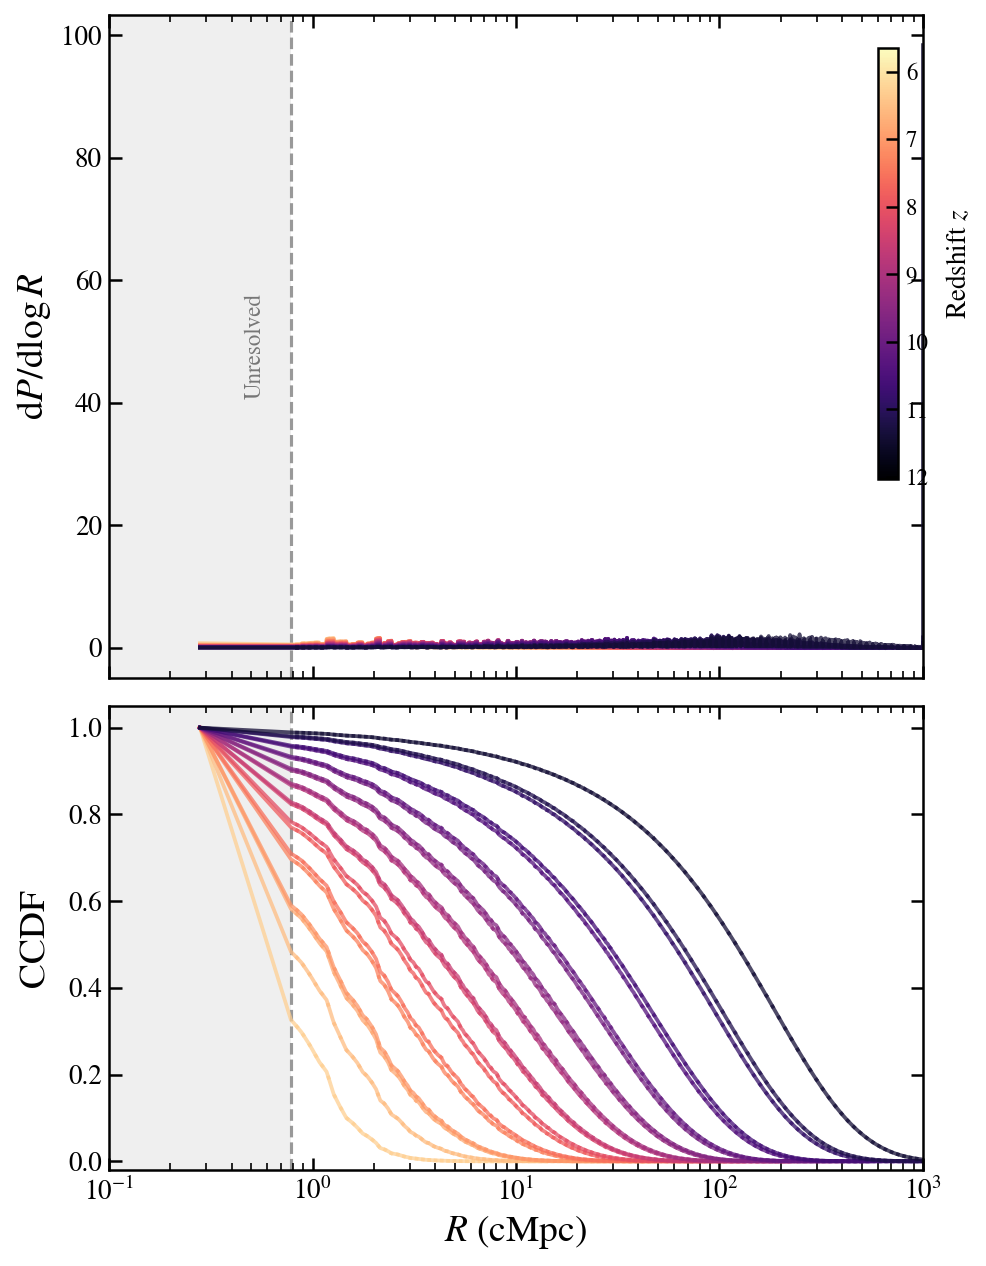

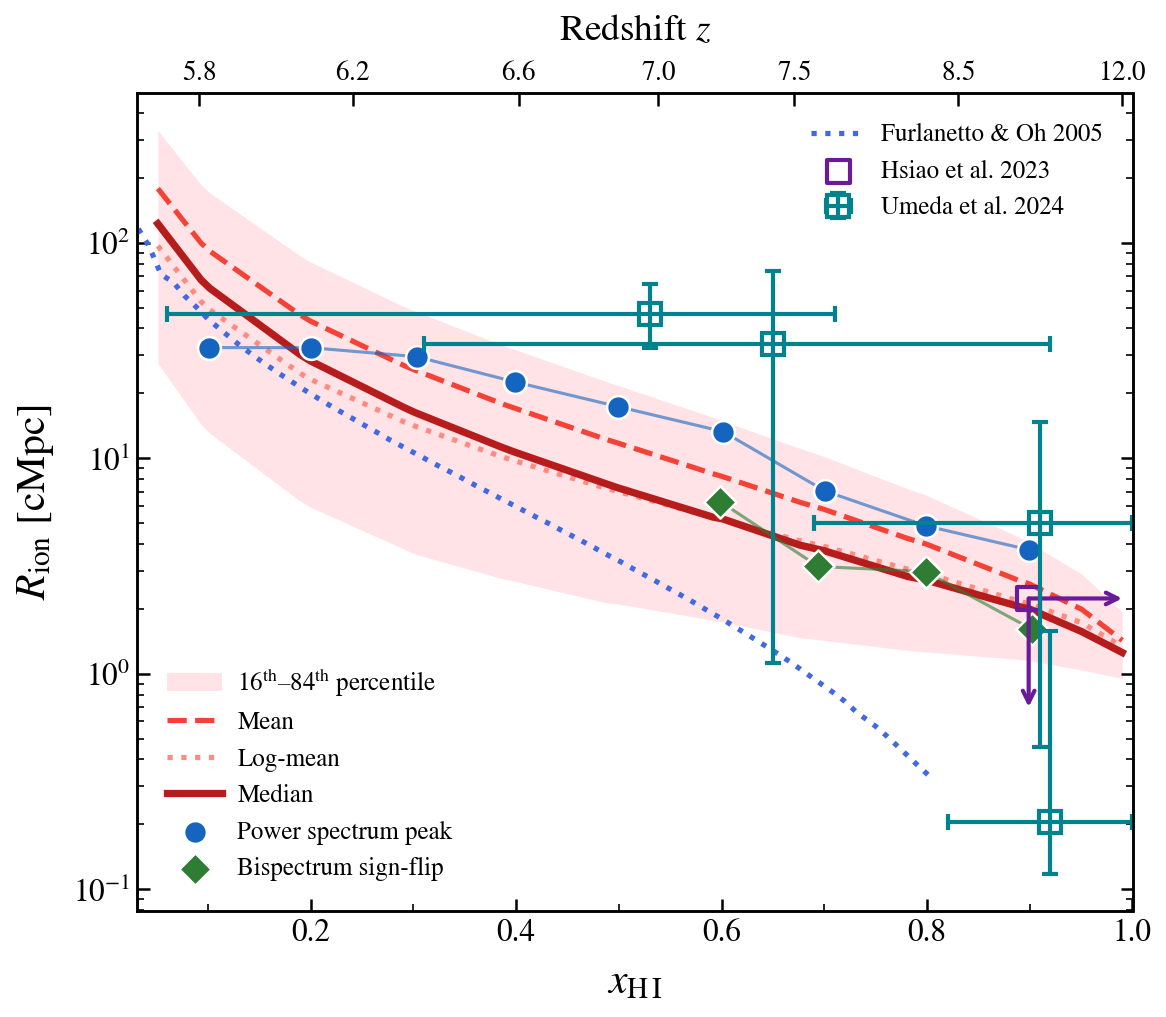

In [74]:
import os
import glob
import h5py
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import LogLocator, NullFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# =====================================================
# Global rcParams (Matplotlib Styling)
# =====================================================
matplotlib.rcParams.update({
    "font.family":         "STIXGeneral",
    "mathtext.fontset":   "stix",
    "font.size":          14,
    "axes.linewidth":     1.2,
    "axes.labelsize":     18,
    "axes.titlesize":     16,
    "xtick.major.size":   6,
    "xtick.minor.size":   3.5,
    "xtick.major.width":  1.2,
    "xtick.minor.width":  0.8,
    "xtick.direction":    "in",
    "xtick.top":          True,
    "xtick.labelsize":    13,
    "ytick.major.size":   6,
    "ytick.minor.size":   3.5,
    "ytick.major.width":  1.2,
    "ytick.minor.width":  0.8,
    "ytick.direction":    "in",
    "ytick.right":        True,
    "ytick.labelsize":    13,
    "legend.fontsize":    12,
    "legend.frameon":     False,
    "legend.handlelength":1.8,
    "lines.linewidth":    2.0,
    "figure.dpi":         150,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
})

# =====================================================
# Simulation Directory & Binning Setup
# =====================================================
DATA_DIR        = "/orcd/data/mvogelsb/004/chcho/mfp-bubbles-thesan/output/LUMINA_hydrogen"
N_RESOLVED_BINS = 1000000
R_GLOBAL_MIN    = 0.1
R_GLOBAL_MAX    = 1000.0

files = sorted(glob.glob(os.path.join(DATA_DIR, "mfp_*.hdf5")))
if len(files) == 0:
    raise RuntimeError(f"No mfp_*.hdf5 files found in {DATA_DIR}")

# Read geometry from first snapshot
with h5py.File(files[0], "r") as f:
    boxsize   = float(f["Header"].attrs["BoxSize"])
    hubble    = float(f["Header"].attrs["HubbleParam"])
    box_cMpc  = boxsize / hubble / 1000.0
    Ngrid     = int(f["Header"].attrs["NumPixels"])
    cell_size = box_cMpc / Ngrid

assert 0.6 < hubble < 0.8, f"Unexpected HubbleParam={hubble:.4f}"
print(f"BoxSize={box_cMpc:.3f} cMpc | Ngrid={Ngrid} | Cell={cell_size:.5f} cMpc | h={hubble:.5f}")

# Generate logarithmic bin grids
R_min          = cell_size
resolved_edges = np.logspace(np.log10(R_min), np.log10(R_GLOBAL_MAX), N_RESOLVED_BINS + 1)
bin_edges      = np.concatenate([[R_GLOBAL_MIN], resolved_edges])
R_centers      = np.sqrt(bin_edges[:-1] * bin_edges[1:])
R_centers[0]   = np.sqrt(R_GLOBAL_MIN * R_min)
dlogR          = np.diff(np.log10(bin_edges))

# =====================================================
# Lookups & Mapping Functions
# =====================================================
snap_to_fHII = {
    112: 0.01, 129: 0.02, 140: 0.03, 148: 0.04, 154: 0.05,
    160: 0.06, 165: 0.07, 169: 0.08, 173: 0.09, 177: 0.10,
    203: 0.20, 220: 0.30, 242: 0.40, 264: 0.50, 283: 0.60,
    300: 0.70, 318: 0.80, 338: 0.90, 341: 0.91, 343: 0.92,
    346: 0.93, 349: 0.94, 352: 0.95, 356: 0.96, 360: 0.97,
    366: 0.98, 374: 0.99,
}

snap_to_redshift = {
    112: 12.006999, 129: 11.205740, 140: 10.718889, 148: 10.363529,
    154: 10.081991, 160:  9.847533, 165:  9.645984, 169:  9.469432,
    173:  9.311993, 177:  9.170129, 203:  8.207879, 220:  7.624910,
    242:  7.204283, 264:  6.872631, 283:  6.592783, 300:  6.342011,
    318:  6.099902, 338:  5.826679, 341:  5.794754, 343:  5.761251,
    346:  5.725699, 349:  5.687586, 352:  5.645994, 356:  5.599397,
    360:  5.545151, 366:  5.477609, 374:  5.379672,
}

_snaps   = np.array(sorted(snap_to_redshift.keys()))
_z_table = np.array([snap_to_redshift[s] for s in _snaps])
_f_table = np.array([snap_to_fHII[s]     for s in _snaps])
_sort    = np.argsort(_z_table)
_z_table = _z_table[_sort]
_f_table = _f_table[_sort]

def z_to_xHII(z):
    """Linearly interpolate redshift → x_HII."""
    return np.interp(z, _z_table, _f_table)

def rebin_by_overlap(edges_src, counts_src, edges_dst):
    """Rebin a histogram by calculating exact 1D overlap weights."""
    out = np.zeros(len(edges_dst) - 1)
    for j in range(len(counts_src)):
        count = counts_src[j]
        if count == 0: continue
        lo, hi = edges_src[j], edges_src[j + 1]
        width  = hi - lo
        if width <= 0: continue
        i_lo = max(np.searchsorted(edges_dst, lo, side="right") - 1, 0)
        i_hi = min(np.searchsorted(edges_dst, hi, side="left"), len(out) - 1)
        for k in range(i_lo, i_hi + 1):
            overlap = min(hi, edges_dst[k + 1]) - max(lo, edges_dst[k])
            if overlap > 0:
                out[k] += count * overlap / width
    return out

# =====================================================
# Data Processing Loop (Figure 1 Summary Calculations)
# =====================================================
z_all, mean_all, median_all, logmean_all = [], [], [], []
p16_all, p84_all, unresolved_all = [], [], []

fig_bsd, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(7, 10), sharex=True,
    gridspec_kw={"hspace": 0.05, "height_ratios": [1, 0.7]}
)

cmap   = matplotlib.colormaps["magma"].reversed()
colors = cmap(np.linspace(0.1, 0.9, len(files)))

for ax in [ax1, ax2]:
    ax.axvspan(R_GLOBAL_MIN, R_min, color="#e0e0e0", alpha=0.5, zorder=0, lw=0)
    ax.axvline(R_min, color="#999999", ls="--", lw=1.5, zorder=1)

for i, fp in enumerate(files):
    with h5py.File(fp, "r") as f:
        snap_Ngrid = int(f["Header"].attrs["NumPixels"])
        assert snap_Ngrid == Ngrid
        z               = float(f["Header"].attrs["Redshift"])
        hist            = f["mfp_hist"][:].astype(float)
        n_bins_native   = len(hist)
        n_bins_per_cell = int(f["Header"].attrs["NumBinsPerCell"])

    edges_native = np.arange(n_bins_native + 1) / n_bins_per_cell * cell_size
    hist_rebin   = rebin_by_overlap(edges_native, hist, bin_edges)

    total = hist_rebin.sum()
    if total == 0:
        print(f"  WARNING: all-zero at z={z:.2f}, skipping.")
        continue

    P       = hist_rebin / total
    dPdlogR = P / dlogR
    ccdf    = np.cumsum(P[::-1])[::-1]

    unresolved_frac = P[0]
    unresolved_all.append(unresolved_frac)
    flag = " *** HIGH ***" if unresolved_frac > 0.05 else ""
    print(f"  z={z:.2f}  unresolved={unresolved_frac:.3%}{flag}")

    mask_stat = (R_centers >= R_min) & (P > 0)
    R_stat    = R_centers[mask_stat]
    P_stat    = P[mask_stat] / P[mask_stat].sum()
    cdf       = np.cumsum(P_stat)

    z_all.append(z)
    mean_all.append(np.sum(P_stat * R_stat))
    logmean_all.append(10 ** np.sum(P_stat * np.log10(R_stat)))
    median_all.append(np.interp(0.50, cdf, R_stat))
    p16_all.append(np.interp(0.16, cdf, R_stat))
    p84_all.append(np.interp(0.84, cdf, R_stat))

    mask_plot = P > 0
    ax1.plot(R_centers[mask_plot], dPdlogR[mask_plot], lw=1.8, color=colors[i], alpha=0.75)
    ax2.plot(R_centers[mask_plot], ccdf[mask_plot],    lw=1.8, color=colors[i], alpha=0.75)

# Render Figure 1 Colorbar & Labels
sm = plt.cm.ScalarMappable(cmap=cmap, norm=matplotlib.colors.Normalize(vmin=min(z_all), vmax=max(z_all)))
sm.set_array([])
cax = inset_axes(ax1, width="2.5%", height="65%", loc="upper right", bbox_to_anchor=(-0.03, -0.05, 1, 1), bbox_transform=ax1.transAxes, borderpad=0)
cb  = fig_bsd.colorbar(sm, cax=cax)
cb.set_label("Redshift $z$", fontsize=13, labelpad=8)
cb.ax.tick_params(labelsize=11, direction="in")
cb.ax.invert_yaxis()

ax1.set_ylabel(r"$\mathrm{d}P/\mathrm{d}\log R$")
ax2.set_ylabel(r"CCDF")
ax2.set_xlabel(r"$R\ (\mathrm{cMpc})$", fontsize=18)
ax1.set_xscale("log")
ax2.set_xscale("log")
ax1.set_xlim(R_GLOBAL_MIN, R_GLOBAL_MAX)
ax2.set_ylim(-0.02, 1.05)
ax2.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])

for ax in [ax1, ax2]:
    ax.xaxis.set_minor_locator(LogLocator(subs=np.arange(2, 10) * 0.1))
    ax.xaxis.set_minor_formatter(NullFormatter())

ax1.text(R_min * 0.75, 0.5, "Unresolved", rotation=90, va="center", ha="right", color="#777777", fontsize=11, transform=ax1.get_xaxis_transform())
plt.setp(ax1.get_xticklabels(), visible=False)
fig_bsd.align_ylabels([ax1, ax2])
plt.tight_layout()
plt.show()

# =====================================================
# Clean, Sort, and Save Catalog Data
# =====================================================
z_all       = np.array(z_all)
mean_all    = np.array(mean_all)
median_all  = np.array(median_all)
logmean_all = np.array(logmean_all)
p16_all     = np.array(p16_all)
p84_all     = np.array(p84_all)

sort_idx    = np.argsort(z_all)
z_all       = z_all[sort_idx]
mean_all    = mean_all[sort_idx]
median_all  = median_all[sort_idx]
logmean_all = logmean_all[sort_idx]
p16_all     = p16_all[sort_idx]
p84_all     = p84_all[sort_idx]

pd.DataFrame({
    "z": z_all, "mean_cMpc": mean_all, "median_cMpc": median_all,
    "logmean_cMpc": logmean_all, "p16_cMpc": p16_all, "p84_cMpc": p84_all,
}).to_csv("bubble_statistics_hydrogen.csv", index=False)

# Convert simulation redshift arrays to neutral fraction space (x_HI)
xHII_all    = z_to_xHII(z_all)
xHI_all     = 1.0 - xHII_all

# =====================================================
# Literature & Reference Data Configurations
# =====================================================
# 1. Power Spectrum Peak
z_ps  = np.array([9.16, 8.20, 7.63, 7.21, 6.87, 6.59, 6.35, 6.10, 5.83])
R_ps  = np.array([2.544, 3.288, 4.763, 8.999, 11.747, 15.292, 20.024, 22.041, 22.073]) / hubble
xHI_ps = 1.0 - z_to_xHII(z_ps)

# 2. Bispectrum Sign-Flip
z_bispec  = np.array([9.2, 8.2, 7.6, 7.2]) #, 6.8
R_bispec  = np.array([1.08827, 2.01348, 2.12863, 4.25726]) / hubble #, 11.3571
xHI_bispec = 1.0 - z_to_xHII(z_bispec)

# 3. Hsiao et al. 2023
z_hsiao  = np.array([9.16])
R_hsiao  = np.array([2.234])
xHI_hsiao = 1.0 - z_to_xHII(z_hsiao)

# 4. Umeda et al. 2024 (Table 4)
xHI_umeda    = np.array([0.53, 0.65, 0.91, 0.92])
xHI_err_low  = np.array([0.47, 0.34, 0.22, 0.10])
xHI_err_high = np.array([0.18, 0.27, 0.09, 0.08])

logRb          = np.array([1.67, 1.53, 0.70, -0.69])
logRb_err_low  = np.array([0.16, 1.48, 1.04, 0.24])
logRb_err_high = np.array([0.14, 0.34, 0.47, 0.89])

Rb_umeda = 10**logRb
Rb_low   = Rb_umeda - 10**(logRb - logRb_err_low)
Rb_high  = 10**(logRb + logRb_err_high) - Rb_umeda

# 5. Furlanetto & Oh 2005
xi_furlanetto = np.array([
    0.1992, 0.2109, 0.2226, 0.2385, 0.2503, 0.2687, 0.2804, 0.2921,
    0.3089, 0.3206, 0.3324, 0.3499, 0.3617, 0.3726, 0.3910, 0.4027,
    0.4145, 0.4329, 0.4438, 0.4555, 0.4739, 0.4857, 0.4974, 0.5150,
    0.5267, 0.5384, 0.5569, 0.5686, 0.5795, 0.5987, 0.6105, 0.6222,
    0.6398, 0.6515, 0.6632, 0.6817, 0.6934, 0.7043, 0.7227, 0.7345,
    0.7462, 0.7646, 0.7755, 0.7872, 0.8057, 0.8174, 0.8291, 0.8459,
    0.8576, 0.8693, 0.8877, 0.8995, 0.9104, 0.9221, 0.9338, 0.9455,
    0.9573, 0.9682, 0.9799, 0.9900,
])
R_furlanetto = np.array([
     0.3400,  0.3830,  0.4330,  0.5102,  0.5715,  0.6636,  0.7469,  0.8229,
     0.9382,  1.0277,  1.1279,  1.2792,  1.3868,  1.4958,  1.6944,  1.8320,
     1.9750,  2.2242,  2.3746,  2.5527,  2.8536,  3.0616,  3.2919,  3.6405,
     3.9111,  4.1886,  4.6573,  4.9884,  5.3024,  5.9213,  6.3318,  6.7762,
     7.4903,  8.0340,  8.5978,  9.5410, 10.2468, 10.9140, 12.1634, 13.1065,
    14.0946, 15.8179, 16.9384, 18.2749, 20.7074, 22.5165, 24.4675, 27.7386,
    30.4569, 33.5082, 39.5524, 44.0926, 49.8666, 56.4022, 65.7361, 71.1672,
    96.6880, 117.2752, 167.3574, 290.0000,
])
# Convert ionized fraction to neutral fraction to match Figure 2's x-axis
xHI_furlanetto = 1.0 - xi_furlanetto

# =====================================================
# Figure 2: R_ion vs x_HI (Chronological Axis)
# =====================================================
# --- Updated, Redder Palette ---
C_FILL   = "#FFCDD2"  # Lighter, crisper red background
C_MEDIAN = "#B71C1C"  # Deep, strong dark red
C_MEAN   = "#F44336"  # Vibrant standard red
C_LMEAN  = "#FF8A80"  # Bright coral/light red
C_PS     = "#1565C0"
C_BISPEC = "#2E7D32"
C_HSIAO  = "#6A1B9A"
C_UMEDA  = "#00838F"
C_FURL   = "royalblue"

fig2, ax = plt.subplots(figsize=(8, 7))

# ---- Simulation Percentiles & Trends ----
ax.fill_between(xHI_all, p16_all, p84_all, color=C_FILL, alpha=0.55, lw=0, label=r"$16^{\rm th}$–$84^{\rm th}$ percentile")
ax.plot(xHI_all, mean_all,    color=C_MEAN,   lw=2.5, ls="--", zorder=3, label=r"Mean")
ax.plot(xHI_all, logmean_all, color=C_LMEAN,  lw=2.5, ls=":",  zorder=3, label=r"Log-mean")
ax.plot(xHI_all, median_all,  color=C_MEDIAN, lw=3.5, ls="-",  zorder=4, label=r"Median")

# ---- Observational & Alternative Track Overlays ----
# Equalized and enlarged scatter sizes (s=120)
ax.plot(xHI_ps, R_ps, color=C_PS, lw=1.5, ls="-", alpha=0.6, zorder=5)
ax.scatter(xHI_ps, R_ps, s=120, color=C_PS, marker="o", zorder=6, edgecolors="white", linewidths=1.2, label=r"Power spectrum peak")

ax.plot(xHI_bispec, R_bispec, color=C_BISPEC, lw=1.5, ls="-", alpha=0.6, zorder=5)
ax.scatter(xHI_bispec, R_bispec, s=120, color=C_BISPEC, marker="D", zorder=6, edgecolors="white", linewidths=1.2, label=r"Bispectrum sign-flip")

# Hsiao (Enlarged to s=120, thicker edges)
ax.scatter(xHI_hsiao, R_hsiao, s=120, color="none", marker="s", zorder=7, edgecolors=C_HSIAO, linewidths=2.0, label=r"Hsiao et al. 2023")

# Furlanetto & Oh 2005
ax.plot(xHI_furlanetto, R_furlanetto, color=C_FURL, lw=2.5, ls=":", zorder=6, label=r"Furlanetto & Oh 2005")

# Hsiao Target vectors (Thicker arrows to match the bigger marker)
xHI_z12_target = 1.0 - z_to_xHII(12.0)
ax.annotate("", xy=(xHI_z12_target, R_hsiao[0]), xytext=(xHI_hsiao[0], R_hsiao[0]), arrowprops=dict(arrowstyle="->", color=C_HSIAO, lw=2.0, shrinkA=0, shrinkB=0), zorder=7)
ax.annotate("", xy=(xHI_hsiao[0], 0.7), xytext=(xHI_hsiao[0], R_hsiao[0]), arrowprops=dict(arrowstyle="->", color=C_HSIAO, lw=2.0, shrinkA=0, shrinkB=0), zorder=7)

# Umeda (Enlarged markersize (ms=11 is roughly equivalent to s=120 in area) and thicker lines)
ax.errorbar(
    xHI_umeda, Rb_umeda,
    xerr=[xHI_err_low, xHI_err_high], yerr=[Rb_low, Rb_high],
    fmt="s", ms=11, mfc="none", mec=C_UMEDA, mew=2.0, ecolor=C_UMEDA, elinewidth=2.0, capsize=4,
    linestyle="none", zorder=7, label=r"Umeda et al. 2024"
)

# ---- Primary Axis Layout: Decreasing left → right ----
ax.set_xlabel(r"$x_{\rm H\,I}$", fontsize=20, labelpad=8)
ax.set_ylabel(r"$R_{\rm ion}\ [\mathrm{cMpc}]$", fontsize=20, labelpad=8)
ax.set_yscale("log")

xHI_lo = max(xHI_all.min() - 0.02, 0.0)
xHI_hi = min(xHI_all.max() + 0.02, 1.0)
ax.set_xlim(xHI_lo, xHI_hi)  # Inverted limits enforce chronological reionization flow

ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
ax.yaxis.set_major_locator(LogLocator(base=10, numticks=6))
ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1, numticks=20))
ax.yaxis.set_minor_formatter(NullFormatter())
ax.tick_params(which="both", direction="in", labelsize=15)

# ---- Secondary Twin Top Axis (Redshift Mapping) ----
ax_top = ax.twiny()
z_ticks_candidate = np.array([5.8, 6.2, 6.6, 7.0, 7.5, 8.5, 12.0])
z_ticks = z_ticks_candidate[(z_ticks_candidate >= _z_table.min()) & (z_ticks_candidate <= _z_table.max())]

xHI_tick_pos = 1.0 - z_to_xHII(z_ticks)
in_range     = (xHI_tick_pos >= xHI_lo) & (xHI_tick_pos <= xHI_hi)
z_ticks      = z_ticks[in_range]
xHI_tick_pos = xHI_tick_pos[in_range]

ax_top.set_xlim(ax.get_xlim())  # Synchronizes with the inverted main view frame
ax_top.set_xticks(xHI_tick_pos)
ax_top.set_xticklabels([f"${z:.1f}$" for z in z_ticks], fontsize=13)
ax_top.set_xlabel(r"Redshift $z$", fontsize=18, labelpad=10)
ax_top.tick_params(which="major", direction="in", length=6, width=1.2, labelsize=13)
ax_top.xaxis.set_minor_locator(ticker.NullLocator())

# ---- Legend Formatting ----
handles, labels = ax.get_legend_handles_labels()

# Define the labels in the EXACT order you want them to appear in the upper right legend
upper_right_labels = [
    "Furlanetto & Oh 2005",
    "Hsiao et al. 2023",
    "Umeda et al. 2024"
]

h1, l1 = [], [] # For the lower left
h2, l2 = [], [] # For the upper right

# Extract lower left labels
for h, l in zip(handles, labels):
    if l not in upper_right_labels:
        h1.append(h)
        l1.append(l)

# Extract upper right labels (enforcing exact custom order)
for target_label in upper_right_labels:
    if target_label in labels:
        idx = labels.index(target_label)
        h2.append(handles[idx])
        l2.append(labels[idx])

# Create the first legend (lower left)
leg1 = ax.legend(
    h1, l1, loc="lower left", fontsize=12, handlelength=2.2, 
    handletextpad=0.6, borderpad=0.7, labelspacing=0.5, 
    frameon=False, facecolor="#FFFFFF", edgecolor="#cccccc", fancybox=False
)
leg1.get_frame().set_linewidth(0.8)
ax.add_artist(leg1)

# Create the second legend (upper right) using the sorted handles
leg2 = ax.legend(
    h2, l2, loc="upper right", fontsize=12, handlelength=2.2, 
    handletextpad=0.6, borderpad=0.7, labelspacing=0.5, 
    frameon=False, facecolor="#FFFFFF", edgecolor="#cccccc", fancybox=False
)
leg2.get_frame().set_linewidth(0.8)

plt.tight_layout()
plt.show()

## Helium

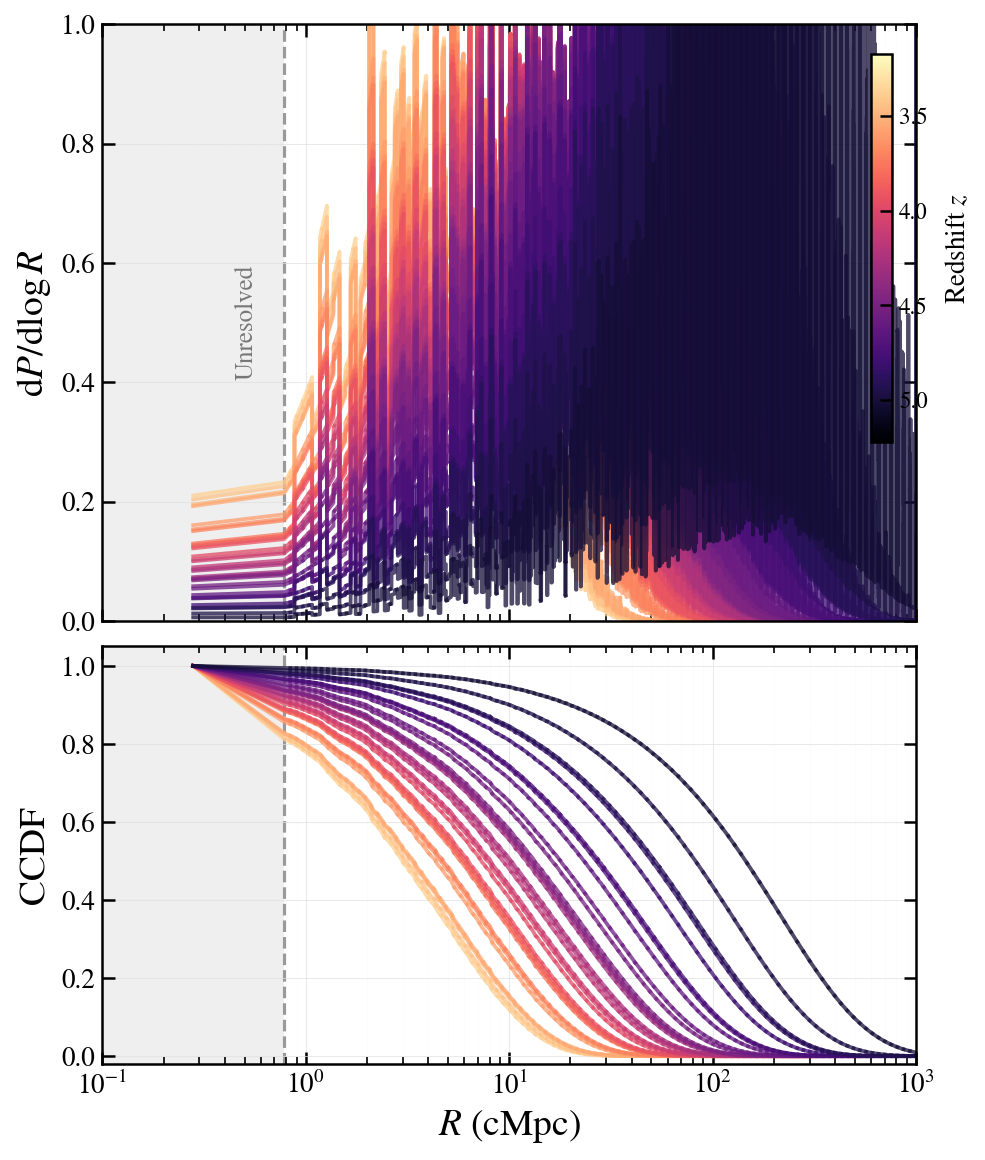

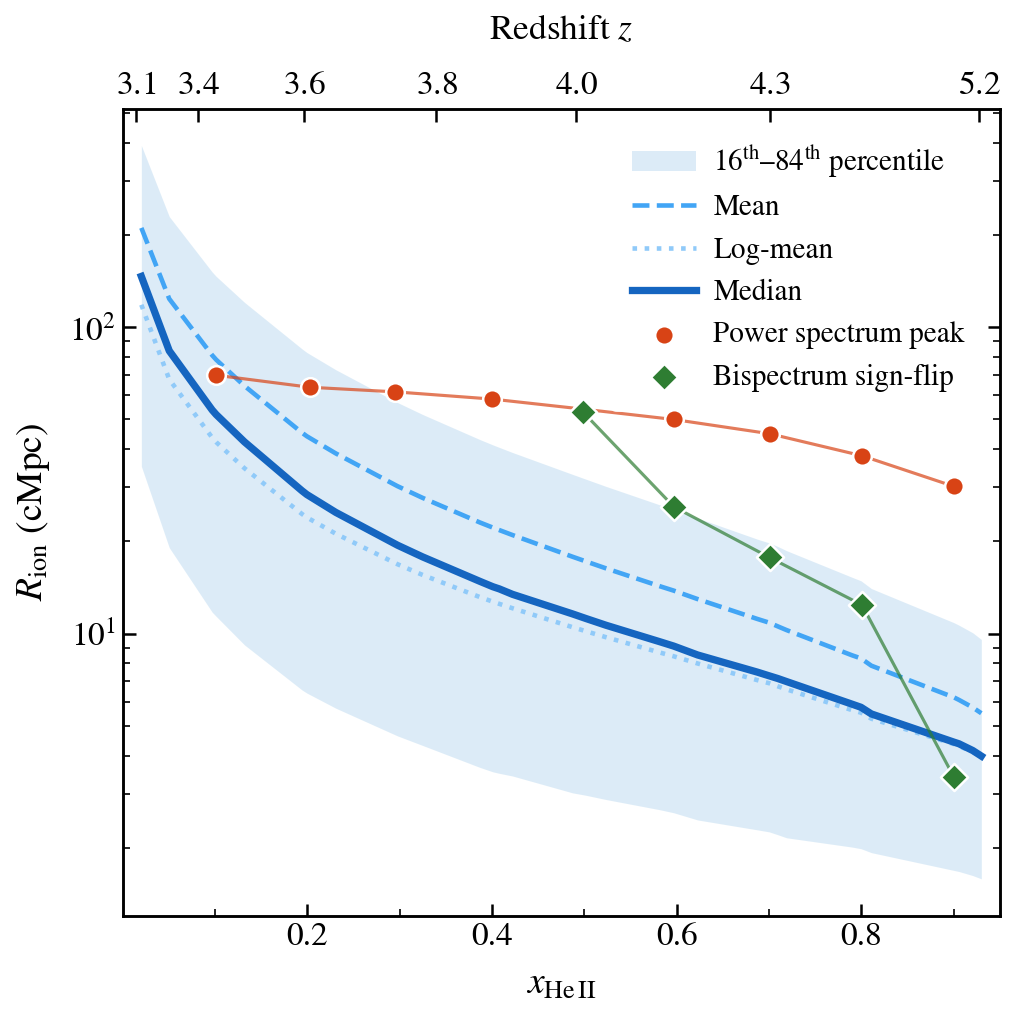

In [23]:
import os
import glob
import h5py
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import LogLocator, NullFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# =====================================================
# Publication-quality rcParams
# =====================================================
matplotlib.rcParams.update({
    "font.family":        "STIXGeneral",
    "mathtext.fontset":   "stix",
    "font.size":          14,
    "axes.linewidth":     1.2,
    "axes.labelsize":     18,
    "axes.titlesize":     16,
    "xtick.major.size":   6,
    "xtick.minor.size":   3.5,
    "xtick.major.width":  1.2,
    "xtick.minor.width":  0.8,
    "xtick.direction":    "in",
    "xtick.top":          True,
    "xtick.labelsize":    13,
    "ytick.major.size":   6,
    "ytick.minor.size":   3.5,
    "ytick.major.width":  1.2,
    "ytick.minor.width":  0.8,
    "ytick.direction":    "in",
    "ytick.right":        True,
    "ytick.labelsize":    13,
    "legend.fontsize":    12,
    "legend.frameon":     False,
    "legend.handlelength":1.8,
    "lines.linewidth":    2.0,
    "figure.dpi":         150,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
})

# =====================================================
# Directory & Binning 
# =====================================================
DATA_DIR = "/orcd/data/mvogelsb/004/chcho/mfp-bubbles-thesan/output/LUMINA_helium"

N_RESOLVED_BINS = 1000000
R_GLOBAL_MIN    = 0.1
R_GLOBAL_MAX    = 1000.0

files = sorted(glob.glob(os.path.join(DATA_DIR, "mfp_*.hdf5")))
if len(files) == 0:
    raise RuntimeError(f"No mfp_*.hdf5 files found in {DATA_DIR}")

with h5py.File(files[0], "r") as f:
    boxsize   = float(f["Header"].attrs["BoxSize"])
    hubble    = float(f["Header"].attrs["HubbleParam"])
    box_cMpc  = boxsize / hubble / 1000.0
    Ngrid     = int(f["Header"].attrs["NumPixels"])
    cell_size = box_cMpc / Ngrid

R_min = cell_size

resolved_edges = np.logspace(np.log10(R_min), np.log10(R_GLOBAL_MAX), N_RESOLVED_BINS + 1)
bin_edges  = np.concatenate([[R_GLOBAL_MIN], resolved_edges])
R_centers  = np.sqrt(bin_edges[:-1] * bin_edges[1:])
R_centers[0] = np.sqrt(R_GLOBAL_MIN * R_min)
dlogR      = np.diff(np.log10(bin_edges))

def rebin_by_overlap(edges_src, counts_src, edges_dst):
    out = np.zeros(len(edges_dst) - 1)
    for j in range(len(counts_src)):
        count = counts_src[j]
        if count == 0: continue
        lo, hi = edges_src[j], edges_src[j + 1]
        width  = hi - lo
        if width <= 0: continue
        i_lo = max(np.searchsorted(edges_dst, lo, side="right") - 1, 0)
        i_hi = min(np.searchsorted(edges_dst, hi, side="left"), len(out) - 1)
        for k in range(i_lo, i_hi + 1):
            overlap = min(hi, edges_dst[k + 1]) - max(lo, edges_dst[k])
            if overlap > 0:
                out[k] += count * overlap / width
    return out

z_all, mean_all, median_all, logmean_all = [], [], [], []
p16_all, p84_all, unresolved_all = [], [], []

# =====================================================
# FIGURE 1: BSD + CCDF 
# =====================================================
fig_bsd, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(7, 9), sharex=True,
    gridspec_kw={"hspace": 0.05, "height_ratios": [1, 0.7]}
)

n_files = len(files)
cmap   = matplotlib.colormaps["magma"].reversed()
colors = cmap(np.linspace(0.1, 0.9, n_files))

for ax in [ax1, ax2]:
    ax.axvspan(R_GLOBAL_MIN, R_min, color="#e0e0e0", alpha=0.5, zorder=0, lw=0)
    ax.axvline(R_min, color="#999999", ls="--", lw=1.5, zorder=1)

for i, fp in enumerate(files):
    with h5py.File(fp, "r") as f:
        z = float(f["Header"].attrs["Redshift"])
        hist = f["mfp_hist"][:].astype(float)
        n_bins_native = len(hist)
        n_bins_per_cell = int(f["Header"].attrs["NumBinsPerCell"])

    edges_native = np.arange(n_bins_native + 1) / n_bins_per_cell * cell_size
    hist_rebin = rebin_by_overlap(edges_native, hist, bin_edges)

    total = hist_rebin.sum()
    if total == 0: continue

    P       = hist_rebin / total
    dPdlogR = P / dlogR
    ccdf    = np.cumsum(P[::-1])[::-1]

    unresolved_all.append(P[0])
    
    mask_stat = (R_centers >= R_min) & (P > 0)
    R_stat    = R_centers[mask_stat]
    P_stat    = P[mask_stat] / P[mask_stat].sum()

    cdf = np.cumsum(P_stat)
    z_all.append(z)
    mean_all.append(np.sum(P_stat * R_stat))
    logmean_all.append(10 ** np.sum(P_stat * np.log10(R_stat)))
    median_all.append(np.interp(0.50, cdf, R_stat))
    p16_all.append(np.interp(0.16, cdf, R_stat))
    p84_all.append(np.interp(0.84, cdf, R_stat))

    mask_plot = P > 0
    ax1.plot(R_centers[mask_plot], dPdlogR[mask_plot], lw=1.8, color=colors[i], alpha=0.75)
    ax2.plot(R_centers[mask_plot], ccdf[mask_plot], lw=1.8, color=colors[i], alpha=0.75)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=matplotlib.colors.Normalize(vmin=min(z_all), vmax=max(z_all)))
sm.set_array([])

cax = inset_axes(ax1, width="2.5%", height="65%", loc="upper right",
                 bbox_to_anchor=(-0.03, -0.05, 1, 1), bbox_transform=ax1.transAxes, borderpad=0)
cb  = fig_bsd.colorbar(sm, cax=cax)
cb.set_label("Redshift $z$", fontsize=13, labelpad=8)
cb.ax.tick_params(labelsize=11, direction="in")
cb.ax.invert_yaxis()

ax1.set_ylabel(r"$\mathrm{d}P/\mathrm{d}\log R$")
ax2.set_ylabel(r"CCDF")
ax2.set_xlabel(r"$R\ (\mathrm{cMpc})$", fontsize=18)

ax1.set_xscale("log")
ax2.set_xscale("log")
ax1.set_xlim(R_GLOBAL_MIN, R_GLOBAL_MAX)
ax1.set_ylim(0.0, 1.0)
ax2.set_ylim(-0.02, 1.05)
ax2.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])

for ax in [ax1, ax2]:
    ax.xaxis.set_minor_locator(LogLocator(subs=np.arange(2, 10) * 0.1))
    ax.xaxis.set_minor_formatter(NullFormatter())
    ax.grid(which="major", ls="-", lw=0.5, color="#e0e0e0", alpha=0.7)
    ax.grid(which="minor", ls=":", lw=0.4, color="#eeeeee", alpha=0.5)

ax1.text(R_min * 0.75, ax1.get_ylim()[1] * 0.5, "Unresolved", rotation=90, va="center", ha="right", color="#777777", fontsize=12)
plt.setp(ax1.get_xticklabels(), visible=False)
fig_bsd.align_ylabels([ax1, ax2])
plt.show()

# =====================================================
# Data Sorting & Reference Setup 
# =====================================================
z_all = np.array(z_all)
mean_all = np.array(mean_all)
median_all = np.array(median_all)
logmean_all = np.array(logmean_all)
p16_all = np.array(p16_all)
p84_all = np.array(p84_all)

sort_idx = np.argsort(z_all)
z_all = z_all[sort_idx]
mean_all = mean_all[sort_idx]
median_all = median_all[sort_idx]
logmean_all = logmean_all[sort_idx]
p16_all = p16_all[sort_idx]
p84_all = p84_all[sort_idx]

z_ps = np.array([5.00, 4.52, 4.30, 4.14, 4.01, 3.88, 3.74, 3.61, 3.44])
R_ps = np.array([20.452, 25.749, 30.390, 33.819, 36.550, 39.431, 41.624, 43.081, 47.186]) / hubble

z_bispec = np.array([5.00, 4.52, 4.30, 4.14, 4.01])
R_bispec = np.array([2.30112, 8.39200, 11.9886, 17.5531, 35.6680]) / hubble

snap_to_fHeIII = {695: 0.01, 660: 0.02, 644: 0.03, 633: 0.04, 624: 0.05, 618: 0.06, 612: 0.07, 606: 0.08, 601: 0.09, 596: 0.10, 558: 0.20, 529: 0.30, 514: 0.40, 500: 0.50, 487: 0.60, 471: 0.70, 450: 0.80, 406: 0.90, 401: 0.91, 394: 0.92, 387: 0.93}
snap_to_redshift = {695: 3.035828, 660: 3.172945, 644: 3.238152, 633: 3.283318, 624: 3.318701, 618: 3.347722, 612: 3.373351, 606: 3.396815, 601: 3.418623, 596: 3.439090, 558: 3.606240, 529: 3.746897, 514: 3.880495, 500: 4.011606, 487: 4.144300, 471: 4.299100, 450: 4.517370, 406: 4.999257, 401: 5.062160, 394: 5.134098, 387: 5.223496}

_snaps = np.array(sorted(snap_to_redshift.keys()))
_z_table = np.array([snap_to_redshift[s] for s in _snaps])
_f_table = np.array([snap_to_fHeIII[s] for s in _snaps])
_sort = np.argsort(_z_table)
_z_table, _f_table = _z_table[_sort], _f_table[_sort]

def z_to_xHeIII(z): return np.interp(z, _z_table, _f_table)

xHe_all = z_to_xHeIII(z_all)
xHe_ps = z_to_xHeIII(z_ps)
xHe_bispec = z_to_xHeIII(z_bispec)

# =====================================================
# FIGURE 2: R_ion vs x_HeIII 
# =====================================================

# Color Palette
C_FILL   = "#BBD9F0"   # Light steel blue — percentile band fill
C_MEDIAN = "#1565C0"   # Deep blue — median (primary)
C_MEAN   = "#42A5F5"   # Mid blue — mean
C_LMEAN  = "#90CAF9"   # Pale blue — log-mean
C_PS     = "#D84315"   # Burnt orange — power spectrum peak
C_BISPEC = "#2E7D32"   # Forest green — bispectrum sign-flip

fig2, ax = plt.subplots(figsize=(7, 7))

# Plot Percentile Band 
ax.fill_between(
    xHe_all, p16_all, p84_all,
    color=C_FILL, alpha=0.5, lw=0,
    label=r"$16^{\mathrm{th}}$–$84^{\mathrm{th}}$ percentile"
)

# Plot Primary Statistics
ax.plot(xHe_all, mean_all, color=C_MEAN, lw=2.2, ls="--", zorder=3, label=r"Mean")
ax.plot(xHe_all, logmean_all, color=C_LMEAN, lw=2.2, ls=":", zorder=3, label=r"Log-mean")
ax.plot(xHe_all, median_all, color=C_MEDIAN, lw=3.5, ls="-", zorder=4, label=r"Median")

# Plot External Estimators
ax.plot(xHe_ps, R_ps, color=C_PS, lw=1.5, ls="-", alpha=0.7, zorder=5)
ax.scatter(xHe_ps, R_ps, s=80, color=C_PS, marker="o", zorder=6,
           edgecolors="white", linewidths=1.2, label=r"Power spectrum peak")

ax.plot(xHe_bispec, R_bispec, color=C_BISPEC, lw=1.5, ls="-", alpha=0.7, zorder=5)
ax.scatter(xHe_bispec, R_bispec, s=85, color=C_BISPEC, marker="D", zorder=6,
           edgecolors="white", linewidths=1.2, label=r"Bispectrum sign-flip")

# --- Primary (Bottom & Left) Axes Formatting ---
ax.set_xlabel(r"$x_{\mathrm{He\,II}}$", fontsize=18, labelpad=8)
ax.set_ylabel(r"$R_{\mathrm{ion}}\ (\mathrm{cMpc})$", fontsize=18, labelpad=8) 
ax.set_yscale("log")
ax.set_xlim(max(xHe_all.min() - 0.02, 0.0), min(xHe_all.max() + 0.02, 1.0))

# Sync tick sizes with the top axis for LaTeX scaling
ax.tick_params(axis='both', which='major', labelsize=16, length=6, width=1.2, direction="in")
ax.tick_params(axis='both', which='minor', length=3.5, width=0.8, direction="in")

ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
ax.yaxis.set_major_locator(LogLocator(base=10, numticks=6))
ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1, numticks=20))
ax.yaxis.set_minor_formatter(NullFormatter())

# --- Secondary (Top) Axis Formatting ---
ax_top = ax.twiny()
z_ticks_candidate = np.array([3.1, 3.4, 3.6, 3.8, 4.0, 4.3, 5.2])
z_ticks = z_ticks_candidate[(z_ticks_candidate >= _z_table.min()) & (z_ticks_candidate <= _z_table.max())]
xHe_tick_pos = z_to_xHeIII(z_ticks)

in_range = (xHe_tick_pos >= ax.get_xlim()[0]) & (xHe_tick_pos <= ax.get_xlim()[1])
z_ticks = z_ticks[in_range]
xHe_tick_pos = xHe_tick_pos[in_range]

ax_top.set_xlim(ax.get_xlim())
ax_top.set_xticks(xHe_tick_pos)
ax_top.set_xticklabels([f"${z:.1f}$" for z in z_ticks], fontsize=16) 
ax_top.set_xlabel(r"Redshift $z$", fontsize=17, labelpad=16)

ax_top.tick_params(which="major", direction="in", length=6, width=1.2, labelsize=16)
ax_top.tick_params(which="minor", direction="in", length=3.5, width=0.8)
ax_top.xaxis.set_minor_locator(ticker.NullLocator())

# --- Legend Setup ---
leg = ax.legend(
    loc="upper right", 
    fontsize=14, 
    handlelength=2.2,
    handletextpad=0.6,
    borderpad=0.7,
    labelspacing=0.5,
    frameon=True,
    facecolor="#FFFFFF",
    edgecolor="none",
    fancybox=True,
)

plt.tight_layout()
plt.show()

## ALL

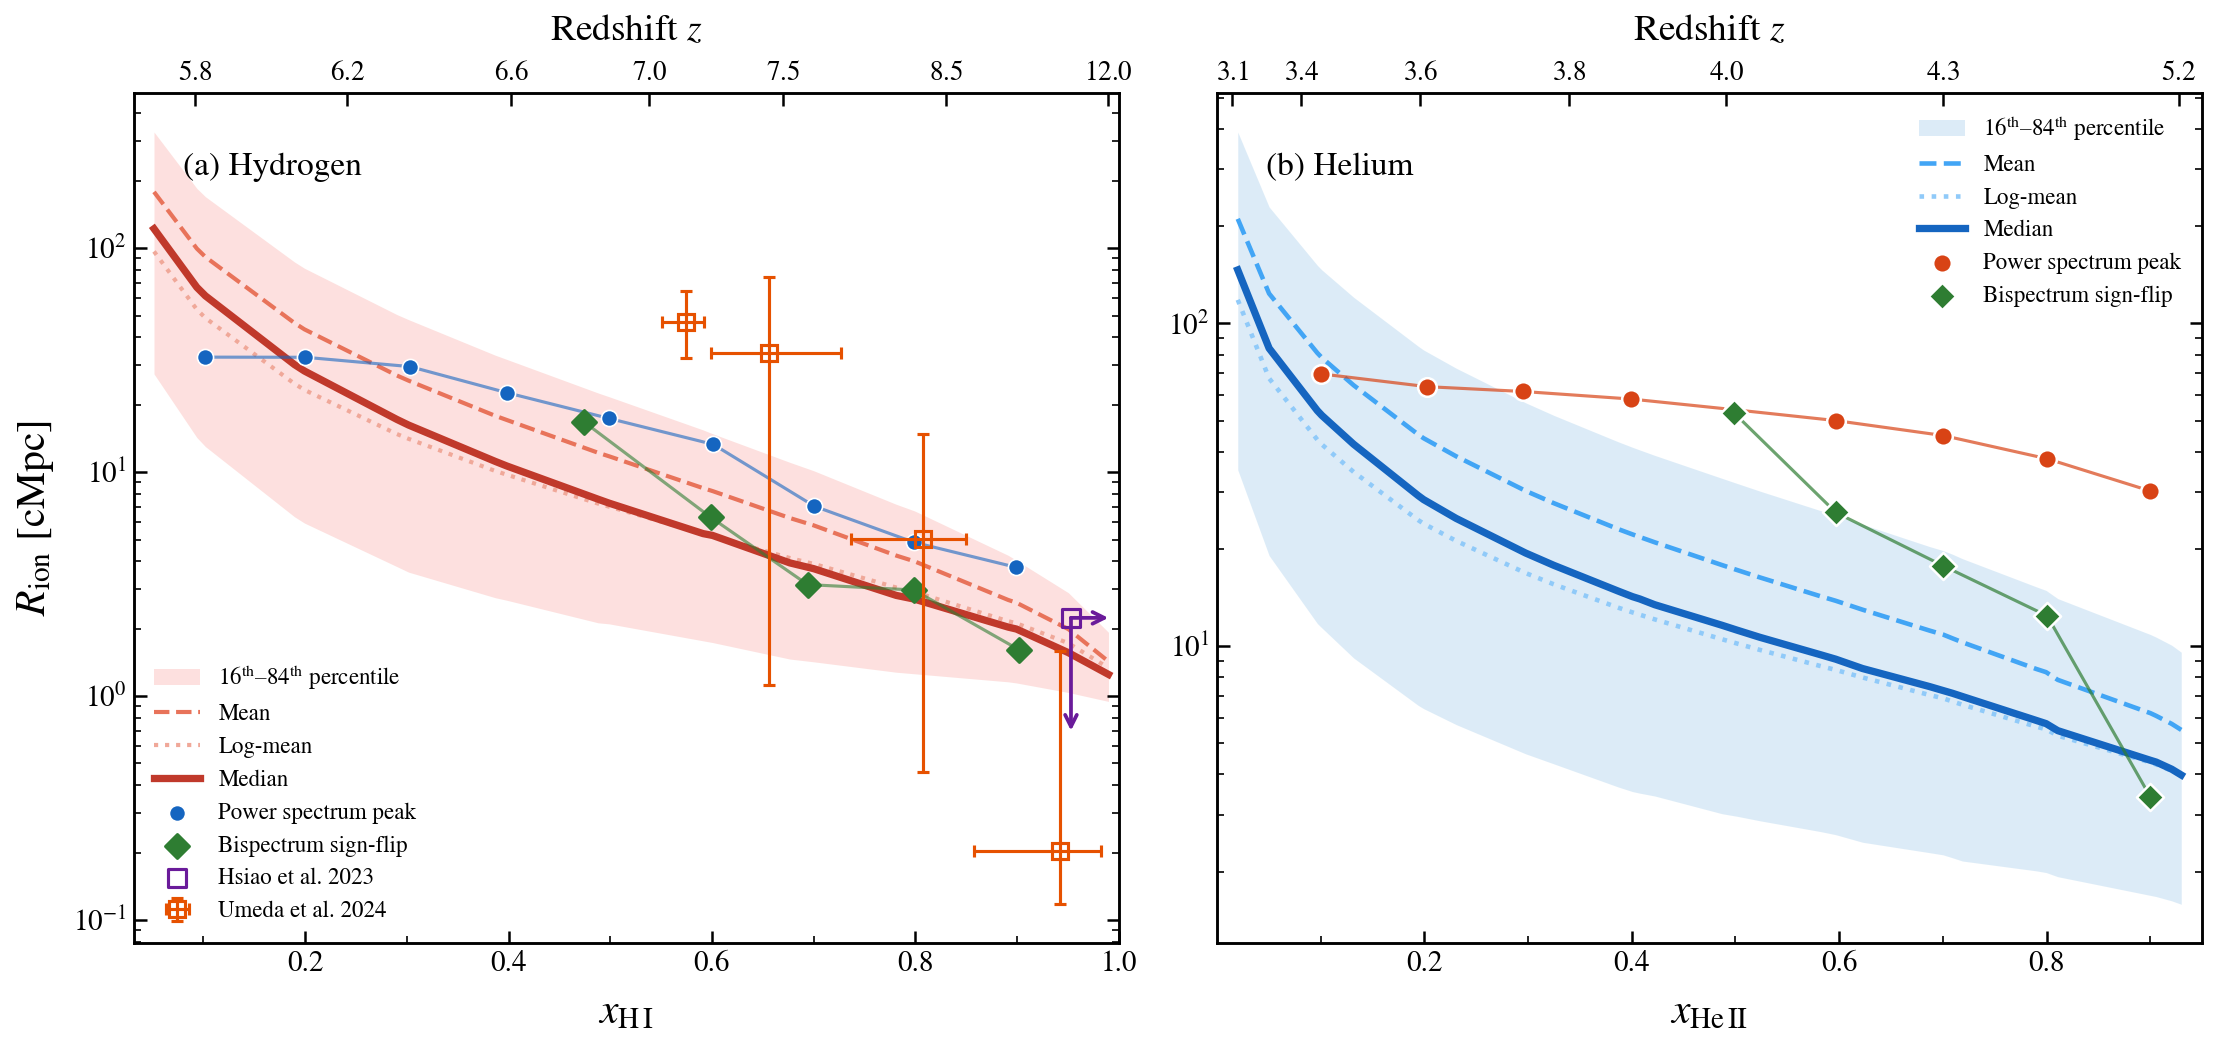

In [31]:
import os
import glob
import h5py
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import LogLocator, NullFormatter

# =====================================================
# Publication-Quality rcParams Setup
# =====================================================
matplotlib.rcParams.update({
    "font.family":         "STIXGeneral",
    "mathtext.fontset":   "stix",
    "font.size":          14,
    "axes.linewidth":     1.2,
    "axes.labelsize":     18,
    "axes.titlesize":     16,
    "xtick.major.size":   6,
    "xtick.minor.size":   3.5,
    "xtick.major.width":  1.2,
    "xtick.minor.width":  0.8,
    "xtick.direction":    "in",
    "xtick.top":          True,
    "xtick.labelsize":    14,
    "ytick.major.size":   6,
    "ytick.minor.size":   3.5,
    "ytick.major.width":  1.2,
    "ytick.minor.width":  0.8,
    "ytick.direction":    "in",
    "ytick.right":         True,
    "ytick.labelsize":    14,
    "legend.fontsize":    11,
    "legend.frameon":     False,
    "legend.handlelength":2.0,
    "lines.linewidth":    2.0,
    "figure.dpi":         150,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
})

# =====================================================
# Shared Helper Function: Overlap-weighted Rebinning
# =====================================================
def rebin_by_overlap(edges_src, counts_src, edges_dst):
    out = np.zeros(len(edges_dst) - 1)
    for j in range(len(counts_src)):
        count = counts_src[j]
        if count == 0: continue
        lo, hi = edges_src[j], edges_src[j + 1]
        width  = hi - lo
        if width <= 0: continue
        i_lo = max(np.searchsorted(edges_dst, lo, side="right") - 1, 0)
        i_hi = min(np.searchsorted(edges_dst, hi, side="left"), len(out) - 1)
        for k in range(i_lo, i_hi + 1):
            overlap = min(hi, edges_dst[k + 1]) - max(lo, edges_dst[k])
            if overlap > 0:
                out[k] += count * overlap / width
    return out


# =====================================================
# 1. HYDROGEN DATA PROCESSING
# =====================================================
DATA_DIR_H = "/orcd/data/mvogelsb/004/chcho/mfp-bubbles-thesan/output/LUMINA_hydrogen"
files_h = sorted(glob.glob(os.path.join(DATA_DIR_H, "mfp_*.hdf5")))
if len(files_h) == 0:
    raise RuntimeError(f"No mfp_*.hdf5 files found in {DATA_DIR_H}")

with h5py.File(files_h[0], "r") as f:
    boxsize_h   = float(f["Header"].attrs["BoxSize"])
    hubble      = float(f["Header"].attrs["HubbleParam"]) 
    box_cMpc_h  = boxsize_h / hubble / 1000.0
    Ngrid_h     = int(f["Header"].attrs["NumPixels"])
    cell_size_h = box_cMpc_h / Ngrid_h

R_min_h = cell_size_h
resolved_edges_h = np.logspace(np.log10(R_min_h), np.log10(1000.0), 1000 + 1)
bin_edges_h      = np.concatenate([[0.1], resolved_edges_h])
R_centers_h      = np.sqrt(bin_edges_h[:-1] * bin_edges_h[1:])
R_centers_h[0]   = np.sqrt(0.1 * R_min_h)

z_all_h, mean_all_h, median_all_h, logmean_all_h, p16_all_h, p84_all_h = [], [], [], [], [], []

for fp in files_h:
    with h5py.File(fp, "r") as f:
        z = float(f["Header"].attrs["Redshift"])
        hist = f["mfp_hist"][:].astype(float)
        n_bins_native = len(hist)
        n_bins_per_cell = int(f["Header"].attrs["NumBinsPerCell"])

    edges_native = np.arange(n_bins_native + 1) / n_bins_per_cell * cell_size_h
    hist_rebin = rebin_by_overlap(edges_native, hist, bin_edges_h)
    total = hist_rebin.sum()
    if total == 0: continue

    P = hist_rebin / total
    mask_stat = (R_centers_h >= R_min_h) & (P > 0)
    R_stat = R_centers_h[mask_stat]
    P_stat = P[mask_stat] / P[mask_stat].sum()
    cdf = np.cumsum(P_stat)

    z_all_h.append(z)
    mean_all_h.append(np.sum(P_stat * R_stat))
    logmean_all_h.append(10 ** np.sum(P_stat * np.log10(R_stat)))
    median_all_h.append(np.interp(0.50, cdf, R_stat))
    p16_all_h.append(np.interp(0.16, cdf, R_stat))
    p84_all_h.append(np.interp(0.84, cdf, R_stat))

z_all_h, mean_all_h, median_all_h, logmean_all_h, p16_all_h, p84_all_h = map(
    np.array, [z_all_h, mean_all_h, median_all_h, logmean_all_h, p16_all_h, p84_all_h]
)
sort_idx_h = np.argsort(z_all_h)
z_all_h, mean_all_h, median_all_h, logmean_all_h, p16_all_h, p84_all_h = [
    arr[sort_idx_h] for arr in [z_all_h, mean_all_h, median_all_h, logmean_all_h, p16_all_h, p84_all_h]
]

# Hydrogen Lookup Setup
snap_to_fHII = {
    112: 0.01, 129: 0.02, 140: 0.03, 148: 0.04, 154: 0.05, 160: 0.06, 165: 0.07, 169: 0.08, 173: 0.09, 177: 0.10,
    203: 0.20, 220: 0.30, 242: 0.40, 264: 0.50, 283: 0.60, 300: 0.70, 318: 0.80, 338: 0.90, 341: 0.91, 343: 0.92,
    346: 0.93, 349: 0.94, 352: 0.95, 356: 0.96, 360: 0.97, 366: 0.98, 374: 0.99,
}
snap_to_redshift_h = {
    112: 12.006999, 129: 11.205740, 140: 10.718889, 148: 10.363529, 154: 10.081991, 160:  9.847533, 165:  9.645984, 
    169:  9.469432, 173:  9.311993, 177:  9.170129, 203:  8.207879, 220:  7.624910, 242:  7.204283, 264:  6.872631, 
    283:  6.592783, 300:  6.342011, 318:  6.099902, 338:  5.826679, 341:  5.794754, 343:  5.761251, 346:  5.725699, 
    349:  5.687586, 352:  5.645994, 356:  5.599397, 360:  5.545151, 366:  5.477609, 374:  5.379672,
}
_snaps_h = np.array(sorted(snap_to_redshift_h.keys()))
_z_table_h = np.array([snap_to_redshift_h[s] for s in _snaps_h])
_f_table_h = np.array([snap_to_fHII[s] for s in _snaps_h])
_sort_h = np.argsort(_z_table_h)
_z_table_h, _f_table_h = _z_table_h[_sort_h], _f_table_h[_sort_h]

def z_to_xHII(z): return np.interp(z, _z_table_h, _f_table_h)

xHI_all_h = 1.0 - z_to_xHII(z_all_h)

# Hydrogen Estimators
z_ps_h = np.array([9.16, 8.20, 7.63, 7.21, 6.87, 6.59, 6.35, 6.10, 5.83])
R_ps_h = np.array([2.544, 3.288, 4.763, 8.999, 11.747, 15.292, 20.024, 22.041, 22.073]) / hubble
xHI_ps_h = 1.0 - z_to_xHII(z_ps_h)

z_bispec_h = np.array([9.2, 8.2, 7.6, 7.2, 6.8])
R_bispec_h = np.array([1.08827, 2.01348, 2.12863, 4.25726, 11.3571]) / hubble
xHI_bispec_h = 1.0 - z_to_xHII(z_bispec_h)

z_hsiao = np.array([10.17])
R_hsiao = np.array([2.234])
xHI_hsiao = 1.0 - z_to_xHII(z_hsiao)

# Umeda mapping data
z_umeda = np.array([7.12, 7.44, 8.28, 9.91])
z_err_low = np.array([0.08, 0.24, 0.44, 1.15])
z_err_high = np.array([0.06, 0.34, 0.41, 1.49])
logRb = np.array([1.67, 1.53, 0.70, -0.69])
logRb_err_low = np.array([0.16, 1.48, 1.04, 0.24])
logRb_err_high = np.array([0.14, 0.34, 0.47, 0.89])

Rb_umeda = 10**logRb
Rb_low = Rb_umeda - 10**(logRb - logRb_err_low)
Rb_high = 10**(logRb + logRb_err_high) - Rb_umeda

x_pos_umeda = 1.0 - z_to_xHII(z_umeda)
xerr_low_plot = x_pos_umeda - (1.0 - z_to_xHII(z_umeda - z_err_low))
xerr_high_plot = (1.0 - z_to_xHII(z_umeda + z_err_high)) - x_pos_umeda


# =====================================================
# 2. HELIUM DATA PROCESSING
# =====================================================
DATA_DIR_HE = "/orcd/data/mvogelsb/004/chcho/mfp-bubbles-thesan/output/LUMINA_helium"
files_he = sorted(glob.glob(os.path.join(DATA_DIR_HE, "mfp_*.hdf5")))
if len(files_he) == 0:
    raise RuntimeError(f"No mfp_*.hdf5 files found in {DATA_DIR_HE}")

with h5py.File(files_he[0], "r") as f:
    boxsize_he   = float(f["Header"].attrs["BoxSize"])
    box_cMpc_he  = boxsize_he / hubble / 1000.0
    Ngrid_he     = int(f["Header"].attrs["NumPixels"])
    cell_size_he = box_cMpc_he / Ngrid_he

R_min_he = cell_size_he
resolved_edges_he = np.logspace(np.log10(R_min_he), np.log10(1000.0), 100000 + 1)
bin_edges_he      = np.concatenate([[0.1], resolved_edges_he])
R_centers_he      = np.sqrt(bin_edges_he[:-1] * bin_edges_he[1:])
R_centers_he[0]   = np.sqrt(0.1 * R_min_he)

z_all_he, mean_all_he, median_all_he, logmean_all_he, p16_all_he, p84_all_he = [], [], [], [], [], []

for fp in files_he:
    with h5py.File(fp, "r") as f:
        z = float(f["Header"].attrs["Redshift"])
        hist = f["mfp_hist"][:].astype(float)
        n_bins_native = len(hist)
        n_bins_per_cell = int(f["Header"].attrs["NumBinsPerCell"])

    edges_native = np.arange(n_bins_native + 1) / n_bins_per_cell * cell_size_he
    hist_rebin = rebin_by_overlap(edges_native, hist, bin_edges_he)
    total = hist_rebin.sum()
    if total == 0: continue

    P = hist_rebin / total
    mask_stat = (R_centers_he >= R_min_he) & (P > 0)
    R_stat = R_centers_he[mask_stat]
    P_stat = P[mask_stat] / P[mask_stat].sum()
    cdf = np.cumsum(P_stat)

    z_all_he.append(z)
    mean_all_he.append(np.sum(P_stat * R_stat))
    logmean_all_he.append(10 ** np.sum(P_stat * np.log10(R_stat)))
    median_all_he.append(np.interp(0.50, cdf, R_stat))
    p16_all_he.append(np.interp(0.16, cdf, R_stat))
    p84_all_he.append(np.interp(0.84, cdf, R_stat))

z_all_he, mean_all_he, median_all_he, logmean_all_he, p16_all_he, p84_all_he = map(
    np.array, [z_all_he, mean_all_he, median_all_he, logmean_all_he, p16_all_he, p84_all_he]
)
sort_idx_he = np.argsort(z_all_he)
z_all_he, mean_all_he, median_all_he, logmean_all_he, p16_all_he, p84_all_he = [
    arr[sort_idx_he] for arr in [z_all_he, mean_all_he, median_all_he, logmean_all_he, p16_all_he, p84_all_he]
]

# Helium Lookup Setup
snap_to_fHeIII = {
    695: 0.01, 660: 0.02, 644: 0.03, 633: 0.04, 624: 0.05, 618: 0.06, 612: 0.07, 606: 0.08, 601: 0.09, 596: 0.10,
    558: 0.20, 529: 0.30, 514: 0.40, 500: 0.50, 487: 0.60, 471: 0.70, 450: 0.80, 406: 0.90, 401: 0.91, 394: 0.92,
    387: 0.93
}
snap_to_redshift_he = {
    695: 3.035828, 660: 3.172945, 644: 3.238152, 633: 3.283318, 624: 3.318701, 618: 3.347722, 612: 3.373351, 
    606: 3.396815, 601: 3.418623, 596: 3.439090, 558: 3.606240, 529: 3.746897, 514: 3.880495, 500: 4.011606, 
    487: 4.144300, 471: 4.299100, 450: 4.517370, 406: 4.999257, 401: 5.062160, 394: 5.134098, 387: 5.223496
}
_snaps_he = np.array(sorted(snap_to_redshift_he.keys()))
_z_table_he = np.array([snap_to_redshift_he[s] for s in _snaps_he])
_f_table_he = np.array([snap_to_fHeIII[s] for s in _snaps_he])
_sort_he = np.argsort(_z_table_he)
_z_table_he, _f_table_he = _z_table_he[_sort_he], _f_table_he[_sort_he]

def z_to_xHeIII(z): return np.interp(z, _z_table_he, _f_table_he)

xHe_all = z_to_xHeIII(z_all_he)

# Helium Estimators
z_ps_he = np.array([5.00, 4.52, 4.30, 4.14, 4.01, 3.88, 3.74, 3.61, 3.44])
R_ps_he = np.array([20.452, 25.749, 30.390, 33.819, 36.550, 39.431, 41.624, 43.081, 47.186]) / hubble
xHe_ps = z_to_xHeIII(z_ps_he)

z_bispec_he = np.array([5.00, 4.52, 4.30, 4.14, 4.01])
R_bispec_he = np.array([2.30112, 8.39200, 11.9886, 17.5531, 35.6680]) / hubble
xHe_bispec = z_to_xHeIII(z_bispec_he)


# =====================================================
# 3. UNIFIED MANUSCRIPT PLOTTING (Side-by-Side Panels)
# =====================================================
fig, (ax_h, ax_he) = plt.subplots(1, 2, figsize=(15, 7.2))

# Color Palettes
C_FILL_H   = "#FBBCB8"; C_MEDIAN_H = "#C0392B"; C_MEAN_H   = "#E8735A"; C_LMEAN_H  = "#F0A899"
C_FILL_HE  = "#BBD9F0"; C_MEDIAN_HE = "#1565C0"; C_MEAN_HE  = "#42A5F5"; C_LMEAN_HE = "#90CAF9"
C_PS       = "#1565C0"; C_BISPEC   = "#2E7D32"; C_HSIAO   = "#6A1B9A"; C_UMEDA    = "#E65100"
C_PS_HE    = "#D84315"

# -----------------------------------------------------
# PANEL (a): HYDROGEN
# -----------------------------------------------------
ax_h.fill_between(xHI_all_h, p16_all_h, p84_all_h, color=C_FILL_H, alpha=0.45, lw=0, label=r"$16^{\rm th}$–$84^{\rm th}$ percentile")
ax_h.plot(xHI_all_h, mean_all_h,    color=C_MEAN_H,   lw=2.0, ls="--", zorder=3, label=r"Mean")
ax_h.plot(xHI_all_h, logmean_all_h, color=C_LMEAN_H,  lw=2.0, ls=":",  zorder=3, label=r"Log-mean")
ax_h.plot(xHI_all_h, median_all_h,  color=C_MEDIAN_H, lw=3.5, ls="-",  zorder=4, label=r"Median")

ax_h.plot(xHI_ps_h, R_ps_h, color=C_PS, lw=1.5, ls="-", alpha=0.6, zorder=5)
ax_h.scatter(xHI_ps_h, R_ps_h, s=60, color=C_PS, marker="o", zorder=6, edgecolors="white", linewidths=0.8, label=r"Power spectrum peak")

ax_h.plot(xHI_bispec_h, R_bispec_h, color=C_BISPEC, lw=1.5, ls="-", alpha=0.6, zorder=5)
ax_h.scatter(xHI_bispec_h, R_bispec_h, s=65, color=C_BISPEC, marker="D", zorder=6, edgecolors=C_BISPEC, linewidths=1.5, label=r"Bispectrum sign-flip")

ax_h.scatter(xHI_hsiao, R_hsiao, s=75, color="none", marker="s", zorder=7, edgecolors=C_HSIAO, linewidths=1.5, label=r"Hsiao et al. 2023")

# Hsiao limits arrows
xHI_z12_target = 1.0 - z_to_xHII(12.0)
ax_h.annotate("", xy=(xHI_z12_target, R_hsiao[0]), xytext=(xHI_hsiao[0], R_hsiao[0]),
              arrowprops=dict(arrowstyle="->", color=C_HSIAO, lw=1.8, shrinkA=0, shrinkB=0), zorder=7)
ax_h.annotate("", xy=(xHI_hsiao[0], 0.7), xytext=(xHI_hsiao[0], R_hsiao[0]),
              arrowprops=dict(arrowstyle="->", color=C_HSIAO, lw=1.8, shrinkA=0, shrinkB=0), zorder=7)

# Umeda implementation
ax_h.errorbar(x_pos_umeda, Rb_umeda, xerr=[xerr_low_plot, xerr_high_plot], yerr=[Rb_low, Rb_high],
              fmt="s", ms=8, mfc="none", mec=C_UMEDA, mew=1.5, ecolor=C_UMEDA, elinewidth=1.5, capsize=3, linestyle="none", zorder=7, label=r"Umeda et al. 2024")

# Formatting Panel (a)
ax_h.set_xlabel(r"$x_{\rm H\,I}$", fontsize=20, labelpad=8)
ax_h.set_ylabel(r"$R_{\rm ion}\ [\mathrm{cMpc}]$", fontsize=20, labelpad=8)
ax_h.set_yscale("log")
xHI_lo = max(xHI_all_h.min() - 0.02, 0.0)
xHI_hi = min(xHI_all_h.max() + 0.02, 1.0)
ax_h.set_xlim(xHI_lo, xHI_hi)

ax_h.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
ax_h.yaxis.set_major_locator(LogLocator(base=10, numticks=6))
ax_h.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1, numticks=20))
ax_h.yaxis.set_minor_formatter(NullFormatter())
ax_h.tick_params(which="both", direction="in")

# Secondary (Top) Redshift Axis Panel (a)
ax_top_h = ax_h.twiny()
z_ticks_c_h = np.array([5.8, 6.2, 6.6, 7.0, 7.5, 8.5, 12.0])
z_ticks_h = z_ticks_c_h[(z_ticks_c_h >= _z_table_h.min()) & (z_ticks_c_h <= _z_table_h.max())]
xHI_tick_pos_h = 1.0 - z_to_xHII(z_ticks_h)
in_range_h = (xHI_tick_pos_h >= min(xHI_lo, xHI_hi)) & (xHI_tick_pos_h <= max(xHI_lo, xHI_hi))
z_ticks_h, xHI_tick_pos_h = z_ticks_h[in_range_h], xHI_tick_pos_h[in_range_h]

ax_top_h.set_xlim(ax_h.get_xlim())
ax_top_h.set_xticks(xHI_tick_pos_h)
ax_top_h.set_xticklabels([f"${z:.1f}$" for z in z_ticks_h], fontsize=13)
ax_top_h.set_xlabel(r"Redshift $z$", fontsize=18, labelpad=10)
ax_top_h.tick_params(which="major", direction="in", length=6, width=1.2)
ax_top_h.xaxis.set_minor_locator(ticker.NullLocator())

# Panel Label inside plot
ax_h.text(0.05, 0.93, "(a) Hydrogen", transform=ax_h.transAxes, fontsize=16, va="top", ha="left")
ax_h.legend(loc="lower left", fontsize=11, frameon=False)


# -----------------------------------------------------
# PANEL (b): HELIUM
# -----------------------------------------------------
ax_he.fill_between(xHe_all, p16_all_he, p84_all_he, color=C_FILL_HE, alpha=0.5, lw=0, label=r"$16^{\mathrm{th}}$–$84^{\mathrm{th}}$ percentile")
ax_he.plot(xHe_all, mean_all_he,    color=C_MEAN_HE,   lw=2.2, ls="--", zorder=3, label=r"Mean")
ax_he.plot(xHe_all, logmean_all_he, color=C_LMEAN_HE,  lw=2.2, ls=":",  zorder=3, label=r"Log-mean")
ax_he.plot(xHe_all, median_all_he,  color=C_MEDIAN_HE, lw=3.5, ls="-",  zorder=4, label=r"Median")

ax_he.plot(xHe_ps, R_ps_he, color=C_PS_HE, lw=1.5, ls="-", alpha=0.7, zorder=5)
ax_he.scatter(xHe_ps, R_ps_he, s=80, color=C_PS_HE, marker="o", zorder=6, edgecolors="white", linewidths=1.2, label=r"Power spectrum peak")

ax_he.plot(xHe_bispec, R_bispec_he, color=C_BISPEC, lw=1.5, ls="-", alpha=0.7, zorder=5)
ax_he.scatter(xHe_bispec, R_bispec_he, s=85, color=C_BISPEC, marker="D", zorder=6, edgecolors="white", linewidths=1.2, label=r"Bispectrum sign-flip")

# Formatting Panel (b)
ax_he.set_xlabel(r"$x_{\mathrm{He\, II}}$", fontsize=20, labelpad=8)
#ax_he.set_ylabel(r"$R_{\rm ion}\ [\mathrm{cMpc}]$", fontsize=20, labelpad=8)
ax_he.set_yscale("log")
ax_he.set_xlim(max(xHe_all.min() - 0.02, 0.0), min(xHe_all.max() + 0.02, 1.0))

ax_he.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
ax_he.yaxis.set_major_locator(LogLocator(base=10, numticks=6))
ax_he.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1, numticks=20))
ax_he.yaxis.set_minor_formatter(NullFormatter())
ax_he.tick_params(which="both", direction="in")

# Secondary (Top) Redshift Axis Panel (b)
ax_top_he = ax_he.twiny()
z_ticks_c_he = np.array([3.1, 3.4, 3.6, 3.8, 4.0, 4.3, 5.2])
z_ticks_he = z_ticks_c_he[(z_ticks_c_he >= _z_table_he.min()) & (z_ticks_c_he <= _z_table_he.max())]
xHe_tick_pos_he = z_to_xHeIII(z_ticks_he)
in_range_he = (xHe_tick_pos_he >= ax_he.get_xlim()[0]) & (xHe_tick_pos_he <= ax_he.get_xlim()[1])
z_ticks_he, xHe_tick_pos_he = z_ticks_he[in_range_he], xHe_tick_pos_he[in_range_he]

ax_top_he.set_xlim(ax_he.get_xlim())
ax_top_he.set_xticks(xHe_tick_pos_he)
ax_top_he.set_xticklabels([f"${z:.1f}$" for z in z_ticks_he], fontsize=13)
ax_top_he.set_xlabel(r"Redshift $z$", fontsize=18, labelpad=10)
ax_top_he.tick_params(which="major", direction="in", length=6, width=1.2)
ax_top_he.xaxis.set_minor_locator(ticker.NullLocator())

# Panel Label inside plot
ax_he.text(0.05, 0.93, "(b) Helium", transform=ax_he.transAxes, fontsize=16, va="top", ha="left")
ax_he.legend(loc="upper right", fontsize=11, frameon=False)

# -----------------------------------------------------
# Global Configuration & Clean-Up
# -----------------------------------------------------
plt.tight_layout()
plt.show()

## Reproducing Furlanetto & Oh 2005

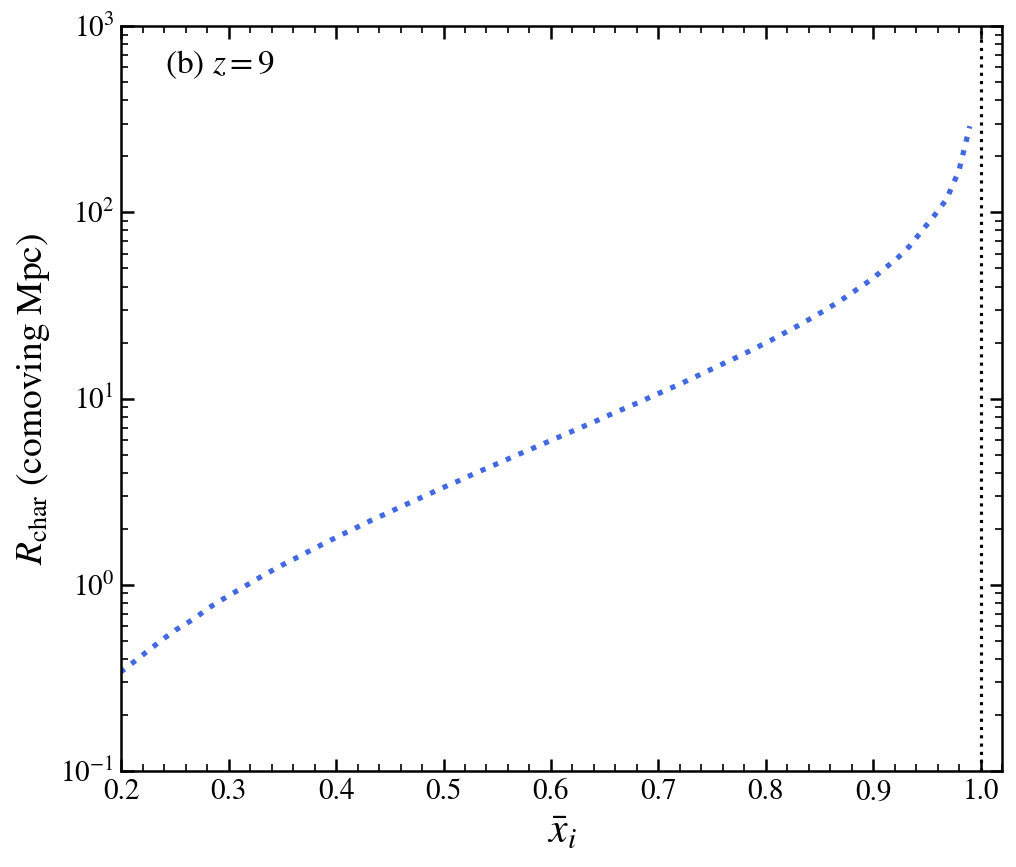

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ============================================================
# Data
# ============================================================

xi_data = np.array([
    0.1992, 0.2109, 0.2226, 0.2385, 0.2503, 0.2687, 0.2804, 0.2921,
    0.3089, 0.3206, 0.3324, 0.3499, 0.3617, 0.3726, 0.3910, 0.4027,
    0.4145, 0.4329, 0.4438, 0.4555, 0.4739, 0.4857, 0.4974, 0.5150,
    0.5267, 0.5384, 0.5569, 0.5686, 0.5795, 0.5987, 0.6105, 0.6222,
    0.6398, 0.6515, 0.6632, 0.6817, 0.6934, 0.7043, 0.7227, 0.7345,
    0.7462, 0.7646, 0.7755, 0.7872, 0.8057, 0.8174, 0.8291, 0.8459,
    0.8576, 0.8693, 0.8877, 0.8995, 0.9104, 0.9221, 0.9338, 
    0.9573, 0.9682, 0.9799, 0.9900,
])

R_data = np.array([
     0.3400,  0.3830,  0.4330,  0.5102,  0.5715,  0.6636,  0.7469,  0.8229,
     0.9382,  1.0277,  1.1279,  1.2792,  1.3868,  1.4958,  1.6944,  1.8320,
     1.9750,  2.2242,  2.3746,  2.5527,  2.8536,  3.0616,  3.2919,  3.6405,
     3.9111,  4.1886,  4.6573,  4.9884,  5.3024,  5.9213,  6.3318,  6.7762,
     7.4903,  8.0340,  8.5978,  9.5410, 10.2468, 10.9140, 12.1634, 13.1065,
    14.0946, 15.8179, 16.9384, 18.2749, 20.7074, 22.5165, 24.4675, 27.7386,
    30.4569, 33.5082, 39.5524, 44.0926, 49.8666, 56.4022, 65.7361, 
    96.6880, 117.2752, 167.3574, 290.0000,
])

# ============================================================
# Create figure
# ============================================================

fig, ax = plt.subplots(figsize=(7,6))

# ============================================================
# Plot
# ============================================================

ax.plot(
    xi_data,
    R_data,
    color="royalblue",
    lw=2.5,
    ls=":"
)

# ============================================================
# Axes
# ============================================================

ax.set_yscale("log")

ax.set_xlabel(r"$\bar{x}_i$", fontsize=20)

ax.set_ylabel(
    r"$R_{\rm char}\ {\rm (comoving\ Mpc)}$",
    fontsize=18
)

ax.set_xlim(0.2, 1.02)
ax.set_ylim(0.1, 1000)

ax.tick_params(
    which="both",
    direction="in",
    top=True,
    right=True
)

ax.minorticks_on()

ax.axvline(
    1.0,
    ls=":",
    lw=1.5,
    color="black"
)

ax.text(
    0.05,
    0.97,
    r"(b) $z = 9$",
    transform=ax.transAxes,
    fontsize=16,
    va="top",
    ha="left"
)


plt.tight_layout()
plt.show()

BoxSize=500.000 cMpc | Ngrid=640 | Cell=0.78125 cMpc | h=0.67660
  z=12.03  unresolved=67.326% *** HIGH ***
  z=10.10  unresolved=51.624% *** HIGH ***
  z=9.16  unresolved=41.777% *** HIGH ***
  z=9.09  unresolved=40.895% *** HIGH ***
  z=8.20  unresolved=30.312% *** HIGH ***
  z=8.10  unresolved=28.998% *** HIGH ***
  z=7.63  unresolved=22.968% *** HIGH ***
  z=7.53  unresolved=21.706% *** HIGH ***
  z=7.21  unresolved=17.590% *** HIGH ***
  z=7.18  unresolved=17.187% *** HIGH ***
  z=6.87  unresolved=13.282% *** HIGH ***
  z=6.84  unresolved=12.906% *** HIGH ***
  z=6.59  unresolved=9.827% *** HIGH ***
  z=6.56  unresolved=9.482% *** HIGH ***
  z=6.35  unresolved=7.013% *** HIGH ***
  z=6.32  unresolved=6.703% *** HIGH ***
  z=6.10  unresolved=4.409%
  z=6.07  unresolved=4.150%
  z=5.83  unresolved=2.181%
  z=5.81  unresolved=2.003%
  z=5.65  unresolved=1.105%


/tmp/ipykernel_3289500/2936282665.py:211: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


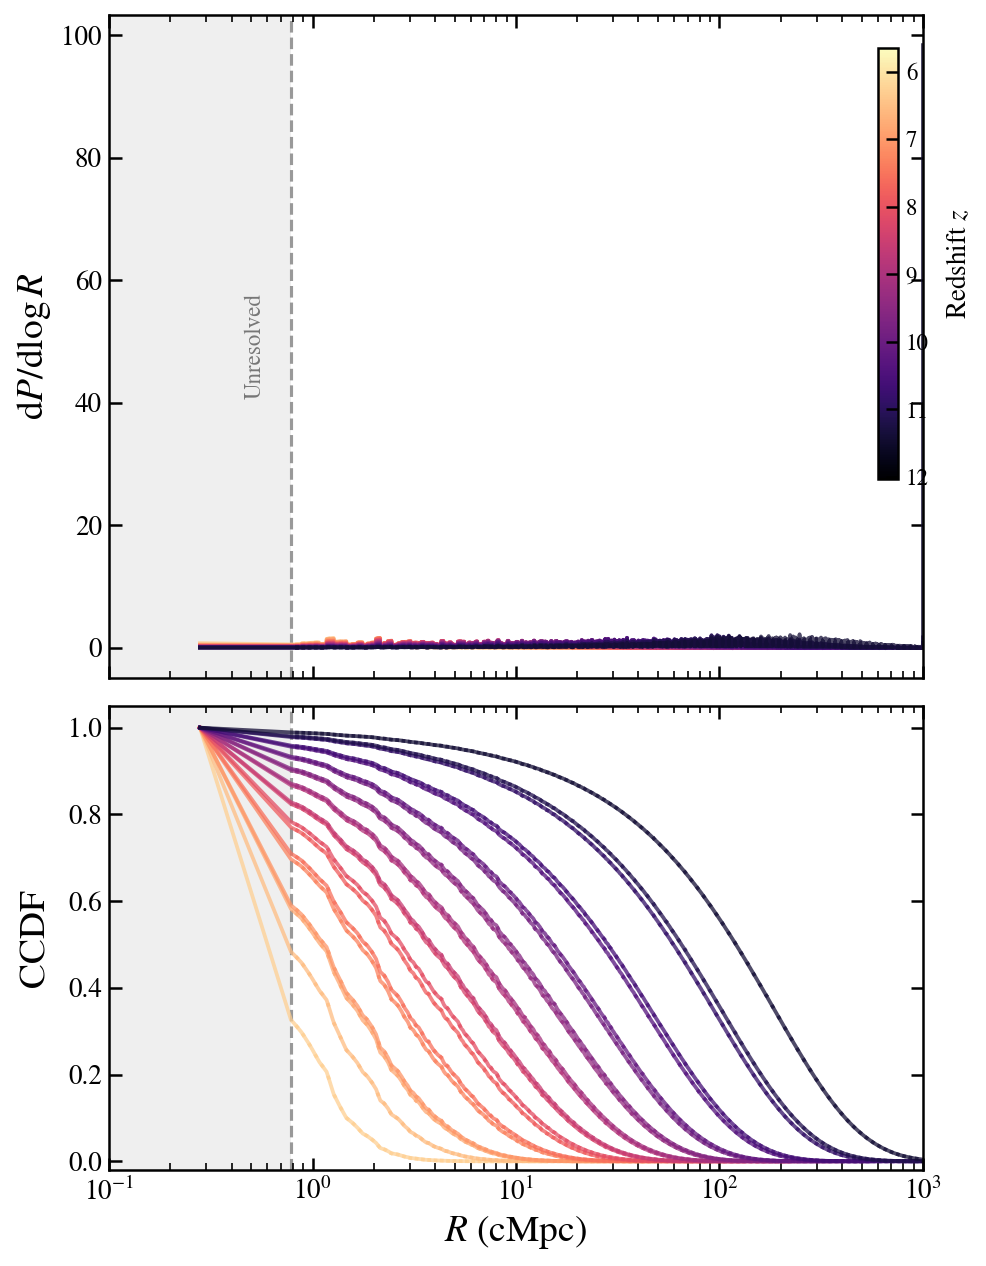

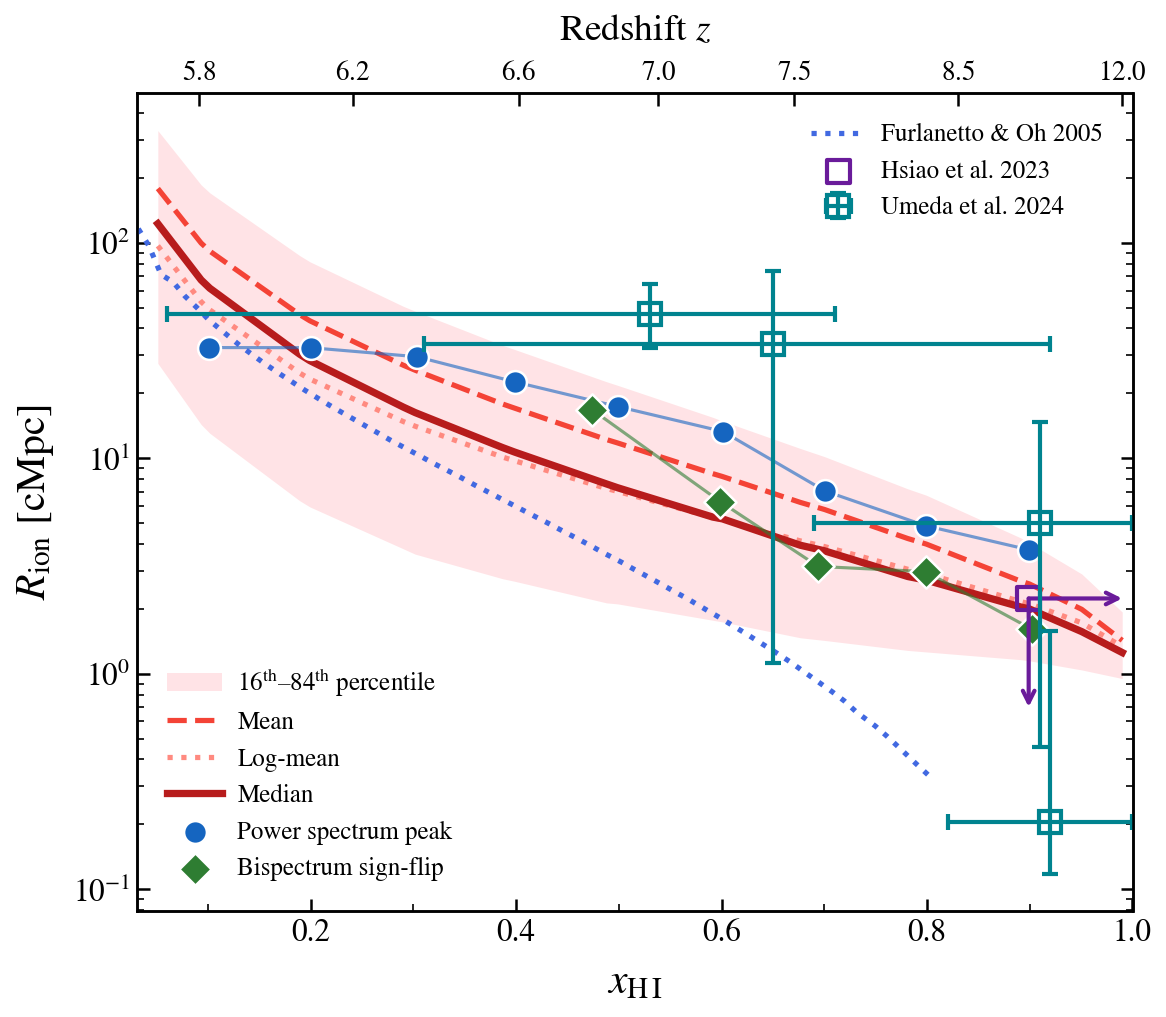

In [72]:
import os
import glob
import h5py
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import LogLocator, NullFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# =====================================================
# Global rcParams (Matplotlib Styling)
# =====================================================
matplotlib.rcParams.update({
    "font.family":         "STIXGeneral",
    "mathtext.fontset":   "stix",
    "font.size":          14,
    "axes.linewidth":     1.2,
    "axes.labelsize":     18,
    "axes.titlesize":     16,
    "xtick.major.size":   6,
    "xtick.minor.size":   3.5,
    "xtick.major.width":  1.2,
    "xtick.minor.width":  0.8,
    "xtick.direction":    "in",
    "xtick.top":          True,
    "xtick.labelsize":    13,
    "ytick.major.size":   6,
    "ytick.minor.size":   3.5,
    "ytick.major.width":  1.2,
    "ytick.minor.width":  0.8,
    "ytick.direction":    "in",
    "ytick.right":        True,
    "ytick.labelsize":    13,
    "legend.fontsize":    12,
    "legend.frameon":     False,
    "legend.handlelength":1.8,
    "lines.linewidth":    2.0,
    "figure.dpi":         150,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
})

# =====================================================
# Simulation Directory & Binning Setup
# =====================================================
DATA_DIR        = "/orcd/data/mvogelsb/004/chcho/mfp-bubbles-thesan/output/LUMINA_hydrogen"
N_RESOLVED_BINS = 1000000
R_GLOBAL_MIN    = 0.1
R_GLOBAL_MAX    = 1000.0

files = sorted(glob.glob(os.path.join(DATA_DIR, "mfp_*.hdf5")))
if len(files) == 0:
    raise RuntimeError(f"No mfp_*.hdf5 files found in {DATA_DIR}")

# Read geometry from first snapshot
with h5py.File(files[0], "r") as f:
    boxsize   = float(f["Header"].attrs["BoxSize"])
    hubble    = float(f["Header"].attrs["HubbleParam"])
    box_cMpc  = boxsize / hubble / 1000.0
    Ngrid     = int(f["Header"].attrs["NumPixels"])
    cell_size = box_cMpc / Ngrid

assert 0.6 < hubble < 0.8, f"Unexpected HubbleParam={hubble:.4f}"
print(f"BoxSize={box_cMpc:.3f} cMpc | Ngrid={Ngrid} | Cell={cell_size:.5f} cMpc | h={hubble:.5f}")

# Generate logarithmic bin grids
R_min          = cell_size
resolved_edges = np.logspace(np.log10(R_min), np.log10(R_GLOBAL_MAX), N_RESOLVED_BINS + 1)
bin_edges      = np.concatenate([[R_GLOBAL_MIN], resolved_edges])
R_centers      = np.sqrt(bin_edges[:-1] * bin_edges[1:])
R_centers[0]   = np.sqrt(R_GLOBAL_MIN * R_min)
dlogR          = np.diff(np.log10(bin_edges))

# =====================================================
# Lookups & Mapping Functions
# =====================================================
snap_to_fHII = {
    112: 0.01, 129: 0.02, 140: 0.03, 148: 0.04, 154: 0.05,
    160: 0.06, 165: 0.07, 169: 0.08, 173: 0.09, 177: 0.10,
    203: 0.20, 220: 0.30, 242: 0.40, 264: 0.50, 283: 0.60,
    300: 0.70, 318: 0.80, 338: 0.90, 341: 0.91, 343: 0.92,
    346: 0.93, 349: 0.94, 352: 0.95, 356: 0.96, 360: 0.97,
    366: 0.98, 374: 0.99,
}

snap_to_redshift = {
    112: 12.006999, 129: 11.205740, 140: 10.718889, 148: 10.363529,
    154: 10.081991, 160:  9.847533, 165:  9.645984, 169:  9.469432,
    173:  9.311993, 177:  9.170129, 203:  8.207879, 220:  7.624910,
    242:  7.204283, 264:  6.872631, 283:  6.592783, 300:  6.342011,
    318:  6.099902, 338:  5.826679, 341:  5.794754, 343:  5.761251,
    346:  5.725699, 349:  5.687586, 352:  5.645994, 356:  5.599397,
    360:  5.545151, 366:  5.477609, 374:  5.379672,
}

_snaps   = np.array(sorted(snap_to_redshift.keys()))
_z_table = np.array([snap_to_redshift[s] for s in _snaps])
_f_table = np.array([snap_to_fHII[s]     for s in _snaps])
_sort    = np.argsort(_z_table)
_z_table = _z_table[_sort]
_f_table = _f_table[_sort]

def z_to_xHII(z):
    """Linearly interpolate redshift → x_HII."""
    return np.interp(z, _z_table, _f_table)

def rebin_by_overlap(edges_src, counts_src, edges_dst):
    """Rebin a histogram by calculating exact 1D overlap weights."""
    out = np.zeros(len(edges_dst) - 1)
    for j in range(len(counts_src)):
        count = counts_src[j]
        if count == 0: continue
        lo, hi = edges_src[j], edges_src[j + 1]
        width  = hi - lo
        if width <= 0: continue
        i_lo = max(np.searchsorted(edges_dst, lo, side="right") - 1, 0)
        i_hi = min(np.searchsorted(edges_dst, hi, side="left"), len(out) - 1)
        for k in range(i_lo, i_hi + 1):
            overlap = min(hi, edges_dst[k + 1]) - max(lo, edges_dst[k])
            if overlap > 0:
                out[k] += count * overlap / width
    return out

# =====================================================
# Data Processing Loop (Figure 1 Summary Calculations)
# =====================================================
z_all, mean_all, median_all, logmean_all = [], [], [], []
p16_all, p84_all, unresolved_all = [], [], []

fig_bsd, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(7, 10), sharex=True,
    gridspec_kw={"hspace": 0.05, "height_ratios": [1, 0.7]}
)

cmap   = matplotlib.colormaps["magma"].reversed()
colors = cmap(np.linspace(0.1, 0.9, len(files)))

for ax in [ax1, ax2]:
    ax.axvspan(R_GLOBAL_MIN, R_min, color="#e0e0e0", alpha=0.5, zorder=0, lw=0)
    ax.axvline(R_min, color="#999999", ls="--", lw=1.5, zorder=1)

for i, fp in enumerate(files):
    with h5py.File(fp, "r") as f:
        snap_Ngrid = int(f["Header"].attrs["NumPixels"])
        assert snap_Ngrid == Ngrid
        z               = float(f["Header"].attrs["Redshift"])
        hist            = f["mfp_hist"][:].astype(float)
        n_bins_native   = len(hist)
        n_bins_per_cell = int(f["Header"].attrs["NumBinsPerCell"])

    edges_native = np.arange(n_bins_native + 1) / n_bins_per_cell * cell_size
    hist_rebin   = rebin_by_overlap(edges_native, hist, bin_edges)

    total = hist_rebin.sum()
    if total == 0:
        print(f"  WARNING: all-zero at z={z:.2f}, skipping.")
        continue

    P       = hist_rebin / total
    dPdlogR = P / dlogR
    ccdf    = np.cumsum(P[::-1])[::-1]

    unresolved_frac = P[0]
    unresolved_all.append(unresolved_frac)
    flag = " *** HIGH ***" if unresolved_frac > 0.05 else ""
    print(f"  z={z:.2f}  unresolved={unresolved_frac:.3%}{flag}")

    mask_stat = (R_centers >= R_min) & (P > 0)
    R_stat    = R_centers[mask_stat]
    P_stat    = P[mask_stat] / P[mask_stat].sum()
    cdf       = np.cumsum(P_stat)

    z_all.append(z)
    mean_all.append(np.sum(P_stat * R_stat))
    logmean_all.append(10 ** np.sum(P_stat * np.log10(R_stat)))
    median_all.append(np.interp(0.50, cdf, R_stat))
    p16_all.append(np.interp(0.16, cdf, R_stat))
    p84_all.append(np.interp(0.84, cdf, R_stat))

    mask_plot = P > 0
    ax1.plot(R_centers[mask_plot], dPdlogR[mask_plot], lw=1.8, color=colors[i], alpha=0.75)
    ax2.plot(R_centers[mask_plot], ccdf[mask_plot],    lw=1.8, color=colors[i], alpha=0.75)

# Render Figure 1 Colorbar & Labels
sm = plt.cm.ScalarMappable(cmap=cmap, norm=matplotlib.colors.Normalize(vmin=min(z_all), vmax=max(z_all)))
sm.set_array([])
cax = inset_axes(ax1, width="2.5%", height="65%", loc="upper right", bbox_to_anchor=(-0.03, -0.05, 1, 1), bbox_transform=ax1.transAxes, borderpad=0)
cb  = fig_bsd.colorbar(sm, cax=cax)
cb.set_label("Redshift $z$", fontsize=13, labelpad=8)
cb.ax.tick_params(labelsize=11, direction="in")
cb.ax.invert_yaxis()

ax1.set_ylabel(r"$\mathrm{d}P/\mathrm{d}\log R$")
ax2.set_ylabel(r"CCDF")
ax2.set_xlabel(r"$R\ (\mathrm{cMpc})$", fontsize=18)
ax1.set_xscale("log")
ax2.set_xscale("log")
ax1.set_xlim(R_GLOBAL_MIN, R_GLOBAL_MAX)
ax2.set_ylim(-0.02, 1.05)
ax2.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])

for ax in [ax1, ax2]:
    ax.xaxis.set_minor_locator(LogLocator(subs=np.arange(2, 10) * 0.1))
    ax.xaxis.set_minor_formatter(NullFormatter())

ax1.text(R_min * 0.75, 0.5, "Unresolved", rotation=90, va="center", ha="right", color="#777777", fontsize=11, transform=ax1.get_xaxis_transform())
plt.setp(ax1.get_xticklabels(), visible=False)
fig_bsd.align_ylabels([ax1, ax2])
plt.tight_layout()
plt.show()

# =====================================================
# Clean, Sort, and Save Catalog Data
# =====================================================
z_all       = np.array(z_all)
mean_all    = np.array(mean_all)
median_all  = np.array(median_all)
logmean_all = np.array(logmean_all)
p16_all     = np.array(p16_all)
p84_all     = np.array(p84_all)

sort_idx    = np.argsort(z_all)
z_all       = z_all[sort_idx]
mean_all    = mean_all[sort_idx]
median_all  = median_all[sort_idx]
logmean_all = logmean_all[sort_idx]
p16_all     = p16_all[sort_idx]
p84_all     = p84_all[sort_idx]

pd.DataFrame({
    "z": z_all, "mean_cMpc": mean_all, "median_cMpc": median_all,
    "logmean_cMpc": logmean_all, "p16_cMpc": p16_all, "p84_cMpc": p84_all,
}).to_csv("bubble_statistics_hydrogen.csv", index=False)

# Convert simulation redshift arrays to neutral fraction space (x_HI)
xHII_all    = z_to_xHII(z_all)
xHI_all     = 1.0 - xHII_all

# =====================================================
# Literature & Reference Data Configurations
# =====================================================
# 1. Power Spectrum Peak
z_ps  = np.array([9.16, 8.20, 7.63, 7.21, 6.87, 6.59, 6.35, 6.10, 5.83])
R_ps  = np.array([2.544, 3.288, 4.763, 8.999, 11.747, 15.292, 20.024, 22.041, 22.073]) / hubble
xHI_ps = 1.0 - z_to_xHII(z_ps)

# 2. Bispectrum Sign-Flip
z_bispec  = np.array([9.2, 8.2, 7.6, 7.2, 6.8])
R_bispec  = np.array([1.08827, 2.01348, 2.12863, 4.25726, 11.3571]) / hubble
xHI_bispec = 1.0 - z_to_xHII(z_bispec)

# 3. Hsiao et al. 2023
z_hsiao  = np.array([9.16])
R_hsiao  = np.array([2.234])
xHI_hsiao = 1.0 - z_to_xHII(z_hsiao)

# 4. Umeda et al. 2024 (Table 4)
xHI_umeda    = np.array([0.53, 0.65, 0.91, 0.92])
xHI_err_low  = np.array([0.47, 0.34, 0.22, 0.10])
xHI_err_high = np.array([0.18, 0.27, 0.09, 0.08])

logRb          = np.array([1.67, 1.53, 0.70, -0.69])
logRb_err_low  = np.array([0.16, 1.48, 1.04, 0.24])
logRb_err_high = np.array([0.14, 0.34, 0.47, 0.89])

Rb_umeda = 10**logRb
Rb_low   = Rb_umeda - 10**(logRb - logRb_err_low)
Rb_high  = 10**(logRb + logRb_err_high) - Rb_umeda

# 5. Furlanetto & Oh 2005
xi_furlanetto = np.array([
    0.1992, 0.2109, 0.2226, 0.2385, 0.2503, 0.2687, 0.2804, 0.2921,
    0.3089, 0.3206, 0.3324, 0.3499, 0.3617, 0.3726, 0.3910, 0.4027,
    0.4145, 0.4329, 0.4438, 0.4555, 0.4739, 0.4857, 0.4974, 0.5150,
    0.5267, 0.5384, 0.5569, 0.5686, 0.5795, 0.5987, 0.6105, 0.6222,
    0.6398, 0.6515, 0.6632, 0.6817, 0.6934, 0.7043, 0.7227, 0.7345,
    0.7462, 0.7646, 0.7755, 0.7872, 0.8057, 0.8174, 0.8291, 0.8459,
    0.8576, 0.8693, 0.8877, 0.8995, 0.9104, 0.9221, 0.9338, 0.9455,
    0.9573, 0.9682, 0.9799, 0.9900,
])
R_furlanetto = np.array([
     0.3400,  0.3830,  0.4330,  0.5102,  0.5715,  0.6636,  0.7469,  0.8229,
     0.9382,  1.0277,  1.1279,  1.2792,  1.3868,  1.4958,  1.6944,  1.8320,
     1.9750,  2.2242,  2.3746,  2.5527,  2.8536,  3.0616,  3.2919,  3.6405,
     3.9111,  4.1886,  4.6573,  4.9884,  5.3024,  5.9213,  6.3318,  6.7762,
     7.4903,  8.0340,  8.5978,  9.5410, 10.2468, 10.9140, 12.1634, 13.1065,
    14.0946, 15.8179, 16.9384, 18.2749, 20.7074, 22.5165, 24.4675, 27.7386,
    30.4569, 33.5082, 39.5524, 44.0926, 49.8666, 56.4022, 65.7361, 71.1672,
    96.6880, 117.2752, 167.3574, 290.0000,
])
# Convert ionized fraction to neutral fraction to match Figure 2's x-axis
xHI_furlanetto = 1.0 - xi_furlanetto

# =====================================================
# Figure 2: R_ion vs x_HI (Chronological Axis)
# =====================================================
# --- Updated, Redder Palette ---
C_FILL   = "#FFCDD2"  # Lighter, crisper red background
C_MEDIAN = "#B71C1C"  # Deep, strong dark red
C_MEAN   = "#F44336"  # Vibrant standard red
C_LMEAN  = "#FF8A80"  # Bright coral/light red
C_PS     = "#1565C0"
C_BISPEC = "#2E7D32"
C_HSIAO  = "#6A1B9A"
C_UMEDA  = "#00838F"
C_FURL   = "royalblue"

fig2, ax = plt.subplots(figsize=(8, 7))

# ---- Simulation Percentiles & Trends ----
ax.fill_between(xHI_all, p16_all, p84_all, color=C_FILL, alpha=0.55, lw=0, label=r"$16^{\rm th}$–$84^{\rm th}$ percentile")
ax.plot(xHI_all, mean_all,    color=C_MEAN,   lw=2.5, ls="--", zorder=3, label=r"Mean")
ax.plot(xHI_all, logmean_all, color=C_LMEAN,  lw=2.5, ls=":",  zorder=3, label=r"Log-mean")
ax.plot(xHI_all, median_all,  color=C_MEDIAN, lw=3.5, ls="-",  zorder=4, label=r"Median")

# ---- Observational & Alternative Track Overlays ----
# Equalized and enlarged scatter sizes (s=120)
ax.plot(xHI_ps, R_ps, color=C_PS, lw=1.5, ls="-", alpha=0.6, zorder=5)
ax.scatter(xHI_ps, R_ps, s=120, color=C_PS, marker="o", zorder=6, edgecolors="white", linewidths=1.2, label=r"Power spectrum peak")

ax.plot(xHI_bispec, R_bispec, color=C_BISPEC, lw=1.5, ls="-", alpha=0.6, zorder=5)
ax.scatter(xHI_bispec, R_bispec, s=120, color=C_BISPEC, marker="D", zorder=6, edgecolors="white", linewidths=1.2, label=r"Bispectrum sign-flip")

# Hsiao (Enlarged to s=120, thicker edges)
ax.scatter(xHI_hsiao, R_hsiao, s=120, color="none", marker="s", zorder=7, edgecolors=C_HSIAO, linewidths=2.0, label=r"Hsiao et al. 2023")

# Furlanetto & Oh 2005
ax.plot(xHI_furlanetto, R_furlanetto, color=C_FURL, lw=2.5, ls=":", zorder=6, label=r"Furlanetto & Oh 2005")

# Hsiao Target vectors (Thicker arrows to match the bigger marker)
xHI_z12_target = 1.0 - z_to_xHII(12.0)
ax.annotate("", xy=(xHI_z12_target, R_hsiao[0]), xytext=(xHI_hsiao[0], R_hsiao[0]), arrowprops=dict(arrowstyle="->", color=C_HSIAO, lw=2.0, shrinkA=0, shrinkB=0), zorder=7)
ax.annotate("", xy=(xHI_hsiao[0], 0.7), xytext=(xHI_hsiao[0], R_hsiao[0]), arrowprops=dict(arrowstyle="->", color=C_HSIAO, lw=2.0, shrinkA=0, shrinkB=0), zorder=7)

# Umeda (Enlarged markersize (ms=11 is roughly equivalent to s=120 in area) and thicker lines)
ax.errorbar(
    xHI_umeda, Rb_umeda,
    xerr=[xHI_err_low, xHI_err_high], yerr=[Rb_low, Rb_high],
    fmt="s", ms=11, mfc="none", mec=C_UMEDA, mew=2.0, ecolor=C_UMEDA, elinewidth=2.0, capsize=4,
    linestyle="none", zorder=7, label=r"Umeda et al. 2024"
)

# ---- Primary Axis Layout: Decreasing left → right ----
ax.set_xlabel(r"$x_{\rm H\,I}$", fontsize=20, labelpad=8)
ax.set_ylabel(r"$R_{\rm ion}\ [\mathrm{cMpc}]$", fontsize=20, labelpad=8)
ax.set_yscale("log")

xHI_lo = max(xHI_all.min() - 0.02, 0.0)
xHI_hi = min(xHI_all.max() + 0.02, 1.0)
ax.set_xlim(xHI_lo, xHI_hi)  # Inverted limits enforce chronological reionization flow

ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
ax.yaxis.set_major_locator(LogLocator(base=10, numticks=6))
ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1, numticks=20))
ax.yaxis.set_minor_formatter(NullFormatter())
ax.tick_params(which="both", direction="in", labelsize=15)

# ---- Secondary Twin Top Axis (Redshift Mapping) ----
ax_top = ax.twiny()
z_ticks_candidate = np.array([5.8, 6.2, 6.6, 7.0, 7.5, 8.5, 12.0])
z_ticks = z_ticks_candidate[(z_ticks_candidate >= _z_table.min()) & (z_ticks_candidate <= _z_table.max())]

xHI_tick_pos = 1.0 - z_to_xHII(z_ticks)
in_range     = (xHI_tick_pos >= xHI_lo) & (xHI_tick_pos <= xHI_hi)
z_ticks      = z_ticks[in_range]
xHI_tick_pos = xHI_tick_pos[in_range]

ax_top.set_xlim(ax.get_xlim())  # Synchronizes with the inverted main view frame
ax_top.set_xticks(xHI_tick_pos)
ax_top.set_xticklabels([f"${z:.1f}$" for z in z_ticks], fontsize=13)
ax_top.set_xlabel(r"Redshift $z$", fontsize=18, labelpad=10)
ax_top.tick_params(which="major", direction="in", length=6, width=1.2, labelsize=13)
ax_top.xaxis.set_minor_locator(ticker.NullLocator())

# ---- Legend Formatting ----
handles, labels = ax.get_legend_handles_labels()

# Define the labels in the EXACT order you want them to appear in the upper right legend
upper_right_labels = [
    "Furlanetto & Oh 2005",
    "Hsiao et al. 2023",
    "Umeda et al. 2024"
]

h1, l1 = [], [] # For the lower left
h2, l2 = [], [] # For the upper right

# Extract lower left labels
for h, l in zip(handles, labels):
    if l not in upper_right_labels:
        h1.append(h)
        l1.append(l)

# Extract upper right labels (enforcing exact custom order)
for target_label in upper_right_labels:
    if target_label in labels:
        idx = labels.index(target_label)
        h2.append(handles[idx])
        l2.append(labels[idx])

# Create the first legend (lower left)
leg1 = ax.legend(
    h1, l1, loc="lower left", fontsize=12, handlelength=2.2, 
    handletextpad=0.6, borderpad=0.7, labelspacing=0.5, 
    frameon=False, facecolor="#FFFFFF", edgecolor="#cccccc", fancybox=False
)
leg1.get_frame().set_linewidth(0.8)
ax.add_artist(leg1)

# Create the second legend (upper right) using the sorted handles
leg2 = ax.legend(
    h2, l2, loc="upper right", fontsize=12, handlelength=2.2, 
    handletextpad=0.6, borderpad=0.7, labelspacing=0.5, 
    frameon=False, facecolor="#FFFFFF", edgecolor="#cccccc", fancybox=False
)
leg2.get_frame().set_linewidth(0.8)

plt.tight_layout()
plt.show()